<div style=" 
    border-radius: 15px;  
    border: 2px solid #006064;  
    padding: 10px;  
    background: linear-gradient(
        135deg, 
        #003B5C, 
        #0077B6 35%, 
        #00B4D8 65%, 
        #2A9D8F 100%
    ); 
    text-align: center;  
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5); 
"> 
    <h1 style=" 
        color: #fff;  
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);  
        font-weight: bold;  
        margin-bottom: 10px;  
        font-size: 36px;  
        font-family: 'Roboto', sans-serif; 
        letter-spacing: 1px; 
    "> 
        🚗 Predicting Electric Vehicle Purchases ⚡ 
    </h1> 
</div>

# 📂 Overview

* ****Background**** <br>

  The adoption of ****electric vehicles (EVs)**** is becoming increasingly important as consumers and governments move toward more sustainable transportation. However, EV adoption decisions can be influenced by several factors, including ****income****, ****daily commuting needs****, ****charging infrastructure****, ****environmental concerns****, ****government subsidies****, and ****range anxiety****. Understanding these factors can help identify the characteristics and conditions that influence a consumer's decision to purchase an electric vehicle.

* ****Goal of the Project**** <br>

  Using demographic information, financial characteristics, driving behavior, charging infrastructure, environmental attitudes, and range anxiety indicators, this project aims to build a predictive model that determines whether a consumer is likely to ****purchase an electric vehicle****. The analysis also helps uncover the key factors associated with EV adoption and provides insights into consumer preferences and barriers to EV ownership.

🎯 **Key Features**

****Target Variable****

* `Will_Buy_EV`: Whether the consumer will purchase an electric vehicle (`Yes` / `No`)

****Buyer Demographics**** <br>

* `Age`: Age of the buyer

* `Gender`: Gender of the buyer

****Financial & Geographic Characteristics**** <br>

* `Annual_Income_USD`: Annual income of the buyer in USD

* `City_Type`: Type of city where the buyer lives

****Driving & Vehicle Ownership**** <br>

* `Daily_Commute_km`: Average daily commuting distance in kilometers

* `Number_of_Cars_Owned`: Number of cars currently owned

* `Current_Car_Type`: Type of vehicle currently owned

****Charging Infrastructure**** <br>

* `Charging_Stations_Near_Home`: Number of charging stations available near the buyer's home

* `Charging_Stations_Near_Work`: Number of charging stations available near the buyer's workplace

* `Home_Charging_Possible`: Whether home charging is possible (`Yes` / `No`)

****Environmental & Policy Factors**** <br>

* `Environmental_Concern_Level`: Buyer's level of concern about environmental issues

* `Subsidy_Available`: Whether an EV purchase subsidy is available (`Yes` / `No`)

****EV Adoption Barriers**** <br>

* `Range_Anxiety_Level`: Buyer's level of concern about EV driving range

📁 ****Files Provided****

* `EV_Adoption_and_Range_Anxiety_Dataset.csv`: Dataset containing buyer characteristics, driving behavior, charging infrastructure, environmental concerns, range anxiety, and EV purchase decisions

🚀 ****Project Objective****

The primary objective of this project is to ****perform exploratory data analysis (EDA)**** and develop machine learning models capable of predicting whether a consumer will purchase an electric vehicle.

Through this analysis, we aim to:

* Understand ****EV adoption patterns**** across different consumer groups

* Identify the ****key factors influencing EV purchase decisions****

* Analyze how ****income, commuting distance, and vehicle ownership**** relate to EV adoption

* Evaluate the impact of ****charging infrastructure and home charging availability**** on purchase intention

* Investigate the relationship between ****environmental concern, subsidies, and range anxiety**** and EV adoption

* Build an accurate **classification model** for predicting EV purchase decisions.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(
        135deg, 
        #003B5C, 
        #0077B6 35%, 
        #00B4D8 65%, 
        #2A9D8F 100%
    ); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
# ============================================================
# Clone Project Source from GitHub
# ============================================================

import os

# Reset the current working directory before removing any old clone.
os.chdir("/kaggle/working")

# Remove any previous repository clone.
!rm -rf /kaggle/working/kaggle-portfolio

# Clone the repository using a partial clone and sparse checkout.
!git clone --filter=blob:none --sparse https://github.com/daominhthuan42/kaggle-portfolio.git

# Move into the cloned repository.
%cd /kaggle/working/kaggle-portfolio

# Checkout only the EV project.
!git sparse-checkout set 50-predicting-electric-vehicle-purchases

# Verify the selected project.
!git sparse-checkout list

# Install statistical analysis dependencies.
!pip install statsmodels > pip_log_statsmodels.txt 2>&1
!pip install scikit_posthocs > pip_log_scikit_posthocs.txt 2>&1
!pip install pingouin==0.5.5 > pip_log_pingouin.txt 2>&1

# Install the required Pandas version.
!pip install -q pandas==3.0.0 > pip_log_pandas.txt 2>&1

Cloning into 'kaggle-portfolio'...
remote: Enumerating objects: 591, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 591 (delta 5), reused 12 (delta 2), pack-reused 575 (from 3)
Receiving objects: 100% (591/591), 84.69 KiB | 1.49 MiB/s, done.
Resolving deltas: 100% (249/249), done.
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 2 (from 1)
Receiving objects: 100% (3/3), 1.43 KiB | 1.43 MiB/s, done.
/kaggle/working/kaggle-portfolio
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 21 (delta 0), reused 2 (delta 0), pack-reused 11 (from 3)
Receiving objects: 100% (21/21), 19.90 MiB | 20.67 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (24/24), done.
50-predicting-electric-vehicle-purchases


In [2]:
import sys
from pathlib import Path

# Define the root directory of the current project.
PROJECT_ROOT = Path("/kaggle/working/kaggle-portfolio/50-predicting-electric-vehicle-purchases")

# Add the project root to Python's module search path.
sys.path.insert(0, str(PROJECT_ROOT))

# Core Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from visualization.visualization_plots import *

# Project Utilities
from utils.logger import LoggerConfig
from utils.config_loader import *
from utils.utils import Utils
from utils.stats_utils import StatUtils
from preprocessing.validation import DataValidator

# Modeling Utilities
from models.benchmark import *
from models.oof import *

# Hyperparameter Tuning
from models.catboost_tuning import *
from models.lgbm_tunning import *
from models.xgboost_tuning import *

# Notebook Display
from IPython.display import display, HTML

# Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Environment Settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_colwidth", None)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(
        135deg, 
        #003B5C, 
        #0077B6 35%, 
        #00B4D8 65%, 
        #2A9D8F 100%
    ); 
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [3]:
# Configure a consistent dark theme for Matplotlib and Seaborn.
setup_plot_style()

# Initialize the project logger.
logger = LoggerConfig.setup_logger()

# Load the global project configuration from the YAML file.
config = load_config(logger=logger)

2026-09-19 04:36:38 | INFO     | Logging configured: level=DEBUG, format=colored
2026-09-19 04:36:38 | INFO     | Loading configuration from config.yaml
2026-09-19 04:36:38 | INFO     | Configuration loaded successfully


In [4]:
# Load datasets safely
df_train = Utils.read_csv_safe(path=config["dataset"]["paths"]["train"], logger=logger,
                               encodings=config["dataset"]["default_encoding"]).pipe(Utils.clean_columns)
df_original = Utils.read_csv_safe(path=config["dataset"]["paths"]["original"], logger=logger,
                                  encodings=config["dataset"]["default_encoding"]).pipe(Utils.clean_columns)
df_test = Utils.read_csv_safe(path=config["dataset"]["paths"]["test"], logger=logger,
                              encodings=config["dataset"]["default_encoding"]).pipe(Utils.clean_columns)

2026-09-19 04:36:39 | INFO     | Loaded file with encoding: utf-8 | Shape: (668665, 15)
2026-09-19 04:36:39 | INFO     | Loaded file with encoding: utf-8 | Shape: (10000, 15)
2026-09-19 04:36:40 | INFO     | Loaded file with encoding: utf-8 | Shape: (286571, 14)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(
        135deg, 
        #003B5C, 
        #0077B6 35%, 
        #00B4D8 65%, 
        #2A9D8F 100%
    );
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [5]:
# Preview Datasets

# Display the first five rows of each dataset for a quick
# inspection of structure, columns, and sample values.
datasets = {"Train": df_train, "Test": df_test, "Original": df_original}

for name, df in datasets.items():
    # Log the dataset currently being previewed.
    logger.info(f"{name} Data Preview")

    # Display the first five rows.
    display(df.head())

2026-09-19 04:36:40 | INFO     | Train Data Preview


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


2026-09-19 04:36:40 | INFO     | Test Data Preview


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


2026-09-19 04:36:40 | INFO     | Original Data Preview


,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


In [6]:
# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info")
    df.info()

2026-09-19 04:36:40 | INFO     | Train Data Info
<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available   

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<h2 style="color:#90E0EF; margin-top:0;">🚗 Insights from Initial Data Exploration</h2>

<h3>Dataset Overview</h3>
<ul>
  <li><b>Training dataset:</b> 668,665 samples with 15 columns, including the target <code>Will_Buy_EV</code>.</li>
  <li><b>Test dataset:</b> 286,571 samples with 14 columns, with the target variable excluded.</li>
  <li><b>Original dataset:</b> 10,000 observations with 15 columns, using <code>Buyer_ID</code> as the identifier and containing the original target <code>Will_Buy_EV</code>.</li>
  <li>The competition datasets contain a combined <b>955,236 observations</b>, substantially larger than the original 10,000-row dataset.</li>
</ul>

<h3>Feature Overview</h3>
<ul>
  <li><b>Numerical features (8):</b> <code>Age</code>, <code>Annual_Income_USD</code>, <code>Daily_Commute_km</code>, <code>Number_of_Cars_Owned</code>, <code>Charging_Stations_Near_Home</code>, <code>Charging_Stations_Near_Work</code>, and <code>Environmental_Concern_Level</code>, together with the numerical identifier <code>id</code>.</li>
  <li><b>Categorical features (6):</b> <code>Gender</code>, <code>City_Type</code>, <code>Current_Car_Type</code>, <code>Home_Charging_Possible</code>, <code>Subsidy_Available</code>, and <code>Range_Anxiety_Level</code>.</li>
  <li><code>Will_Buy_EV</code> is the binary classification target indicating whether a consumer is likely to purchase an electric vehicle.</li>
</ul>

<h3>Data Quality</h3>
<ul>
  <li>The <b>competition train and test datasets are complete</b>, with no missing values across any of the predictor variables.</li>
  <li>In contrast, the <b>original dataset contains missing values</b> in <code>Annual_Income_USD</code>, <code>Daily_Commute_km</code>, and <code>Environmental_Concern_Level</code>.</li>
  <li>The competition version therefore appears to have undergone <b>data preprocessing or transformation</b> compared with the original dataset, resulting in a much larger dataset with no missing values.</li>
  <li>Numerical variables are stored as <code>int64</code> or <code>float64</code>, while categorical variables are stored as <code>object</code> and will require appropriate encoding for machine learning models.</li>
</ul>

<h3>Memory and Efficiency</h3>
<ul>
  <li>The training dataset occupies approximately <b>76.5 MB</b> of memory, while the test dataset occupies approximately <b>30.6 MB</b>.</li>
  <li>Given the combined dataset size of more than <b>955,000 observations</b>, memory-efficient data processing becomes important during EDA and model development.</li>
  <li>Converting categorical variables to the <code>category</code> dtype can help reduce memory usage and improve computational efficiency.</li>
</ul>

<h3>Initial Observations</h3>
<ul>
  <li>The dataset combines <b>demographic</b>, <b>financial</b>, <b>driving</b>, <b>charging infrastructure</b>, <b>environmental</b>, and <b>behavioral</b> factors, providing multiple perspectives for predicting EV purchase decisions.</li>
  <li>Features such as <code>Annual_Income_USD</code>, <code>Daily_Commute_km</code>, and <code>Number_of_Cars_Owned</code> may capture the consumer's financial capacity and transportation needs.</li>
  <li>Charging-related variables, particularly <code>Charging_Stations_Near_Home</code>, <code>Charging_Stations_Near_Work</code>, and <code>Home_Charging_Possible</code>, may provide important signals about the practicality of EV ownership.</li>
  <li><code>Environmental_Concern_Level</code>, <code>Subsidy_Available</code>, and <code>Range_Anxiety_Level</code> represent important behavioral and policy-related factors that may influence EV adoption.</li>
  <li>The identifier <code>id</code>, <code>Buyer_ID</code> do not represent a meaningful consumer characteristic and should be <b>excluded from model training</b> to avoid introducing non-predictive information.</li>
</ul>

</div>

In [7]:
# Preserve test IDs for the final submission file.
list_test_id = df_test[config["columns"]["train_test"][0]].copy().to_list()

# Remove identifier columns from the Train and Test datasets.
# These columns do not provide predictive information.
df_train.drop(columns=config["columns"]["train_test"], inplace=True)
df_test.drop(columns=config["columns"]["train_test"], inplace=True)

# Remove the original dataset identifier column.
df_original.drop(columns=config["columns"]["original"], inplace=True)


# Numerical features
num_features = ["Age", "Annual_Income_USD", "Daily_Commute_km", "Charging_Stations_Near_Home", "Charging_Stations_Near_Work"]

# Categorical features
cat_features = ["Gender", "City_Type", "Current_Car_Type", "Home_Charging_Possible", "Subsidy_Available", 
                "Environmental_Concern_Level", "Range_Anxiety_Level", "Number_of_Cars_Owned"]

# Reduce memory and convert to category
df_train = Utils.reduce_mem_usage(cols=num_features, df=df_train)
df_test = Utils.reduce_mem_usage(cols=num_features, df=df_test)
df_original = Utils.reduce_mem_usage(cols=num_features, df=df_original)

df_train = Utils.convert_cat(features=cat_features, df=df_train)
df_test = Utils.convert_cat(features=cat_features, df=df_test)
df_original = Utils.convert_cat(features=cat_features, df=df_original)


# Display information about the DataFrames
for name, df in datasets.items():
    logger.info(f"{name} Data Info After Reducing")
    df.info()

2026-09-19 04:36:40 | INFO     | Train Data Info After Reducing
<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Age                          668665 non-null  int8    
 1   Annual_Income_USD            668665 non-null  float32 
 2   Daily_Commute_km             668665 non-null  float32 
 3   Number_of_Cars_Owned         668665 non-null  category
 4   Charging_Stations_Near_Home  668665 non-null  int8    
 5   Charging_Stations_Near_Work  668665 non-null  int8    
 6   Environmental_Concern_Level  668665 non-null  category
 7   Gender                       668665 non-null  category
 8   City_Type                    668665 non-null  category
 9   Current_Car_Type             668665 non-null  category
 10  Home_Charging_Possible       668665 non-null  category
 11  Subsidy_Available            668665 non-null  categ

## Numerical Feature Summary — Data Analyst Perspective

In [8]:
# Create a light blue colormap for highlighting summary statistics.
cm = sns.light_palette("blue", as_cmap=True)
for name, df in datasets.items():
    # Log the dataset currently being analyzed.
    logger.info(f"{name} Data Describe:")

    # Display descriptive statistics for numerical features.
    display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-09-19 04:36:40 | INFO     | Train Data Describe:


,count,mean,std,min,25%,50%,75%,max
Age,668665.000000,47.039171,12.875448,25.000000,36.000000,47.000000,58.000000,69.000000
Annual_Income_USD,668665.000000,84769.289062,28637.109375,30000.000000,67376.000000,84880.000000,102753.000000,188549.000000
Daily_Commute_km,668665.000000,32.158298,18.725174,5.000000,17.200001,33.599998,47.400002,98.699997
Charging_Stations_Near_Home,668665.000000,4.960408,3.926843,0.000000,2.000000,4.000000,7.000000,14.000000
Charging_Stations_Near_Work,668665.000000,7.176314,5.186627,0.000000,3.000000,6.000000,10.000000,19.000000


2026-09-19 04:36:41 | INFO     | Test Data Describe:


,count,mean,std,min,25%,50%,75%,max
Age,286571.000000,47.070824,12.864850,25.000000,36.000000,47.000000,58.000000,69.000000
Annual_Income_USD,286571.000000,84799.515625,28625.003906,30000.000000,67380.000000,84926.000000,102751.000000,186936.000000
Daily_Commute_km,286571.000000,32.159302,18.717730,5.000000,17.200001,33.599998,47.299999,103.900002
Charging_Stations_Near_Home,286571.000000,4.950693,3.928626,0.000000,2.000000,4.000000,7.000000,14.000000
Charging_Stations_Near_Work,286571.000000,7.155626,5.186880,0.000000,3.000000,6.000000,10.000000,19.000000


2026-09-19 04:36:41 | INFO     | Original Data Describe:


,count,mean,std,min,25%,50%,75%,max
Age,10000.000000,46.936200,12.945968,25.000000,36.000000,47.000000,58.000000,69.000000
Annual_Income_USD,9822.000000,85378.492188,32838.671875,30000.000000,61369.500000,84708.000000,107383.250000,223345.000000
Daily_Commute_km,9819.000000,41.105415,23.351192,5.000000,23.250000,40.200001,57.000000,135.500000
Charging_Stations_Near_Home,10000.000000,5.346900,4.049074,0.000000,2.000000,5.000000,8.000000,14.000000
Charging_Stations_Near_Work,10000.000000,7.458200,5.259374,0.000000,3.000000,6.000000,11.000000,19.000000


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#90E0EF;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
🚗 Descriptive Statistics
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>Age</code>: Consumers have an average age of approximately <b>47 years</b>, with the middle 50% ranging from <b>36 to 58 years</b>. The distribution is highly consistent across the Train, Test, and Original datasets, indicating a stable consumer age profile.</li>

<li><code>Annual_Income_USD</code>: Average annual income is approximately <b>$84,769</b> in the Train dataset and <b>$84,800</b> in the Test dataset, with median income around <b>$84,880–$84,926</b>. The middle 50% of consumers earn roughly between <b>$67,400 and $102,753</b>, suggesting a relatively broad income range across the population.</li>

<li><code>Daily_Commute_km</code>: Consumers travel approximately <b>32.2 km per day</b> on average in the Train dataset, with the middle 50% commuting between <b>17.0 and 47.4 km</b>. The Test dataset shows a very similar distribution, while the Original dataset has a noticeably higher average commute of approximately <b>41.1 km</b>, indicating some distribution differences between the original and competition data.</li>

<li><code>Charging_Stations_Near_Home</code>: Consumers have approximately <b>5 charging stations</b> near their homes on average, with a median of <b>4 stations</b>. Around 75% of observations have no more than <b>7 stations</b> nearby, indicating relatively moderate access to home-area charging infrastructure.</li>

<li><code>Charging_Stations_Near_Work</code>: The average number of charging stations near the workplace is approximately <b>7.2</b>, with a median of <b>6 stations</b>. The higher availability compared with home charging suggests that workplace areas may provide broader access to charging infrastructure.</li>

<li><code>Train vs Test</code>: The Train and Test datasets show <b>highly consistent descriptive statistics</b> across age, income, commuting distance, and charging infrastructure. The close alignment of means, medians, quartiles, and standard deviations suggests <b>no major distribution shift</b> between the competition training and test sets.</li>

<li><code>Train/Test vs Original</code>: The competition datasets generally preserve the overall characteristics of the Original dataset, particularly for <code>Age</code> and <code>Annual_Income_USD</code>. However, <code>Daily_Commute_km</code> shows a noticeable difference, with the Original dataset having a higher average and wider upper range than the competition data.</li>

<li><code>Overall</code>: The numerical variables capture several important dimensions of EV adoption, including <b>consumer demographics</b>, <b>financial capacity</b>, <b>daily transportation needs</b>, and <b>charging infrastructure availability</b>. These characteristics provide a strong foundation for analyzing and predicting electric vehicle purchase decisions.</li>

</ul>

</div>

## Categorical Feature Summary — Data Analyst Perspective

In [9]:
for name, df in datasets.items():
    # Log the dataset currently being analyzed.
    logger.info(f"{name} Data Describe:")

    # Display descriptive statistics for categorical features.
    display(df[cat_features].astype("category").describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

2026-09-19 04:36:41 | INFO     | Train Data Describe:


,count,unique,top,freq
Gender,668665,3,Male,367954
City_Type,668665,3,Urban,289305
Current_Car_Type,668665,4,Sedan,303459
Home_Charging_Possible,668665,2,Yes,462677
Subsidy_Available,668665,2,Yes,419909
Environmental_Concern_Level,668665,5,1,147476
Range_Anxiety_Level,668665,3,Low,603972
Number_of_Cars_Owned,668665,4,2,298287


2026-09-19 04:36:41 | INFO     | Test Data Describe:


,count,unique,top,freq
Gender,286571,3,Male,157647
City_Type,286571,3,Urban,123602
Current_Car_Type,286571,4,Sedan,130185
Home_Charging_Possible,286571,2,Yes,198480
Subsidy_Available,286571,2,Yes,180378
Environmental_Concern_Level,286571,5,1,63125
Range_Anxiety_Level,286571,3,Low,259247
Number_of_Cars_Owned,286571,4,2,127869


2026-09-19 04:36:41 | INFO     | Original Data Describe:


,count,unique,top,freq
Gender,10000,3,Male,5201
City_Type,10000,3,Urban,4941
Current_Car_Type,10000,4,Sedan,4000
Home_Charging_Possible,10000,2,Yes,6163
Subsidy_Available,10000,2,Yes,6008
Environmental_Concern_Level,9816,5,1,2013
Range_Anxiety_Level,10000,3,Low,8310
Number_of_Cars_Owned,10000,4,2,4020


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#90E0EF;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
🚗 Categorical Feature Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><b>Gender</b>: All datasets contain <b>three gender categories</b>, with <code>Male</code> being the most frequently observed group. In the Train and Test datasets, males account for approximately <b>55%</b> of observations, while the Original dataset shows a slightly more balanced distribution with males representing <b>52%</b>.</li>

<li><b>City_Type</b>: Three city categories are represented, with <code>Urban</code> being the dominant category. It accounts for approximately <b>43%</b> of the Train and Test datasets and nearly <b>49%</b> of the Original dataset, suggesting that urban consumers form an important segment of the population.</li>

<li><b>Current_Car_Type</b>: Four vehicle categories are present, with <code>Sedan</code> being the most common current vehicle type. Sedans represent approximately <b>45%</b> of both the Train and Test datasets, compared with <b>40%</b> in the Original dataset.</li>

<li><b>Home_Charging_Possible</b>: This binary feature is moderately concentrated toward <code>Yes</code>, which represents approximately <b>69%</b> of the Train and Test observations. The Original dataset has a lower proportion of consumers with home charging availability at approximately <b>62%</b>.</li>

<li><b>Subsidy_Available</b>: Approximately <b>63%</b> of consumers in the Train and Test datasets have access to an available subsidy, compared with approximately <b>60%</b> in the Original dataset. This indicates that government incentives are available to a substantial proportion of the observed consumers.</li>

<li><b>Environmental_Concern_Level</b>: This ordinal feature contains <b>five levels</b>. Level <code>1</code> is the most frequently observed category, accounting for approximately <b>22%</b> of the Train and Test observations. The distribution across the five levels should be examined further because the feature represents ordered levels of environmental concern rather than purely nominal categories.</li>

<li><b>Range_Anxiety_Level</b>: The distribution is strongly concentrated in the <code>Low</code> category, representing approximately <b>90%</b> of both the Train and Test datasets. The Original dataset has a lower proportion of <code>Low</code> range anxiety at approximately <b>83%</b>, indicating a noticeable distribution difference between the original and competition datasets.</li>

<li><b>Number_of_Cars_Owned</b>: Four ownership levels are represented, with consumers owning <code>2</code> cars being the most common group. This category accounts for approximately <b>45%</b> of the Train and Test datasets and <b>40%</b> of the Original dataset. Although this variable is numerical in storage, its low number of discrete values makes categorical treatment a reasonable modeling approach to evaluate.</li>

<li><b>Low-cardinality features</b>: Most categorical variables contain only <b>2–4 categories</b>, making them straightforward to encode using One-Hot Encoding or other appropriate categorical encoding techniques. The ordinal variables <code>Environmental_Concern_Level</code> and <code>Range_Anxiety_Level</code> should preserve their inherent ordering during preprocessing.</li>

<li><b>Distribution consistency</b>: The Train and Test datasets show <b>highly consistent categorical distributions</b> across all examined variables. However, several differences can be observed when compared with the Original dataset, particularly for <code>Range_Anxiety_Level</code>, <code>Home_Charging_Possible</code>, and <code>Current_Car_Type</code>.</li>

<li><b>Overall</b>: These categorical and ordinal variables capture important aspects of <b>consumer demographics</b>, <b>vehicle ownership</b>, <b>charging accessibility</b>, <b>government incentives</b>, <b>environmental attitudes</b>, and <b>range anxiety</b>. Together, they provide important behavioral and contextual signals for predicting electric vehicle purchase decisions.</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(
    135deg, 
    #003B5C, 
    #0077B6 35%, 
    #00B4D8 65%, 
    #2A9D8F 100%
);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>

## Missing Value

In [10]:
logger.info("Start checking NULL values")
logger.info("-" * 80)
logger.info(f"Checking missing values for {config['dataset']['name']}...")
for name, df in datasets.items():
    logger.info(f"{name} Data Checking:")
    DataValidator.checkNULL(df=df, logger=logger)
logger.info("-" * 80)
logger.info("Completed checking for NULL values across datasets.")

2026-09-19 04:36:41 | INFO     | Start checking NULL values
2026-09-19 04:36:41 | INFO     | --------------------------------------------------------------------------------
2026-09-19 04:36:41 | INFO     | Checking missing values for EV Adoption Prediction Dataset...
2026-09-19 04:36:41 | INFO     | Train Data Checking:
2026-09-19 04:36:46 | INFO     | No missing values detected in 668,665 rows.
2026-09-19 04:36:46 | INFO     | Test Data Checking:
2026-09-19 04:36:48 | INFO     | No missing values detected in 286,571 rows.
2026-09-19 04:36:48 | INFO     | Original Data Checking:
2026-09-19 04:36:48 | WARNING  | 
+-----------------------------+---------------+-----------+
| Feature                     | Missing_Count | Missing_% |
+-----------------------------+---------------+-----------+
| Environmental_Concern_Level | 184           | 1.84      |
| Daily_Commute_km            | 181           | 1.81      |
| Annual_Income_USD           | 178           | 1.78      |
+------------------

## Checking duplicate Value

In [11]:
logger.info("Start checking duplicate values")
logger.info("-" * 80)
logger.info(f"Data duplicate Analysis...")
for name, df in datasets.items():
    logger.info(f"{name} Data Checking:")
    DataValidator.checkDuplicate(df=df, logger=logger)
logger.info("-" * 80)
logger.info("Duplicate value inspection successfully completed across datasets.")

2026-09-19 04:36:48 | INFO     | Start checking duplicate values
2026-09-19 04:36:48 | INFO     | --------------------------------------------------------------------------------
2026-09-19 04:36:48 | INFO     | Data duplicate Analysis...
2026-09-19 04:36:48 | INFO     | Train Data Checking:
2026-09-19 04:36:48 | INFO     | No duplicate rows found out of 668,665 total rows.
2026-09-19 04:36:48 | INFO     | Test Data Checking:
2026-09-19 04:36:48 | INFO     | No duplicate rows found out of 286,571 total rows.
2026-09-19 04:36:48 | INFO     | Original Data Checking:
2026-09-19 04:36:48 | INFO     | No duplicate rows found out of 10,000 total rows.
2026-09-19 04:36:48 | INFO     | --------------------------------------------------------------------------------
2026-09-19 04:36:48 | INFO     | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [12]:
logger.info("-" * 80)
outlier_data = []
for name, df in datasets.items():
    logger.info(f"{name} Data Checking:")
    outlier_data.append(DataValidator.checkOutlier(df=df, dataset_name=config["dataset"]["name"], 
                                                   list_feature=num_features, logger=logger))
if outlier_data:
    for outlier in outlier_data:
        logger.warning("\n" + outlier.to_string())

logger.info("-" * 80)
logger.info("Outlier checking successfully completed across datasets.")

2026-09-19 04:36:48 | INFO     | --------------------------------------------------------------------------------
2026-09-19 04:36:48 | INFO     | Train Data Checking:
2026-09-19 04:36:48 | INFO     | Checking outliers for EV Adoption Prediction Dataset...
2026-09-19 04:36:48 | INFO     | --------------------------------------------------------------------------------
2026-09-19 04:36:48 | DEBUG    | [EV Adoption Prediction Dataset] Age: No outliers detected
2026-09-19 04:36:48 | WARNING  | [EV Adoption Prediction Dataset] Annual_Income_USD: 3,678 outliers detected (lower=14310.500, upper=155818.500)
2026-09-19 04:36:48 | WARNING  | [EV Adoption Prediction Dataset] Daily_Commute_km: 41 outliers detected (lower=-28.100, upper=92.700)
2026-09-19 04:36:48 | DEBUG    | [EV Adoption Prediction Dataset] Charging_Stations_Near_Home: No outliers detected
2026-09-19 04:36:48 | DEBUG    | [EV Adoption Prediction Dataset] Charging_Stations_Near_Work: No outliers detected
2026-09-19 04:36:48 | INF

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
        background: linear-gradient(
    135deg, 
    #003B5C, 
    #0077B6 35%, 
    #00B4D8 65%, 
    #2A9D8F 100%
);
    text-align: center; 
    box-shadow: 0px 6px 15px rgba(6, 78, 59, 0.35);
">
    <h1 style="
        color: #fff;
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7);
        font-weight: bold;
        margin-bottom: 10px;
        font-size: 36px;
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


## Class Distribution

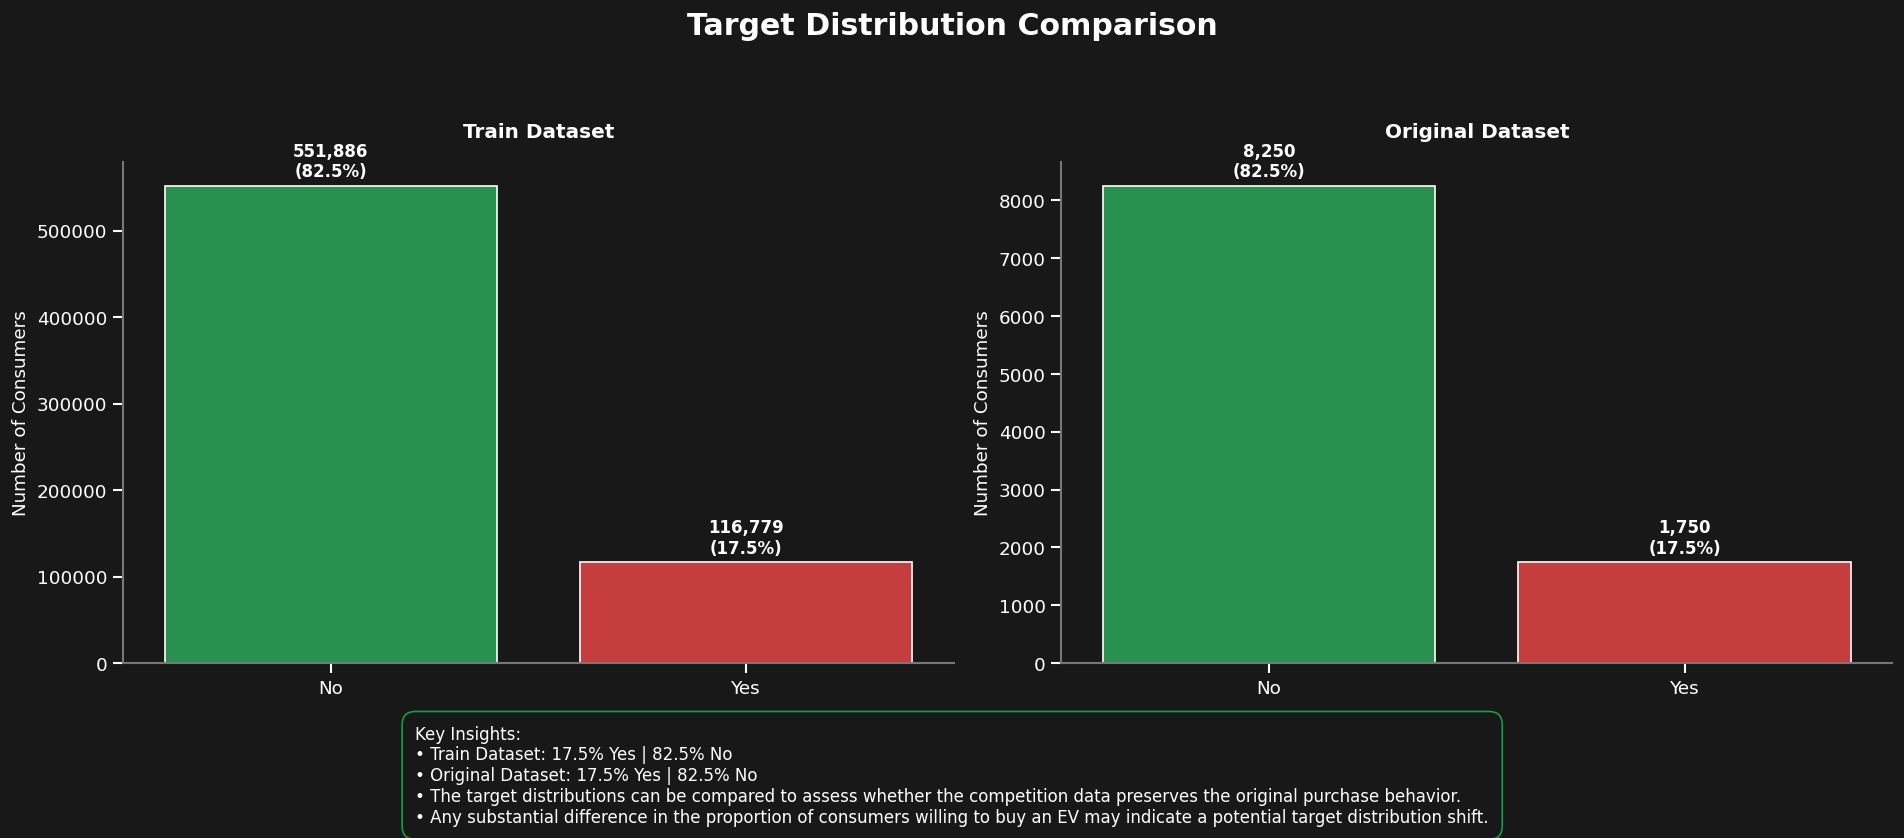

In [13]:
# Target Distribution Comparison
order = ["No", "Yes"]
colors = ["#16A34A", "#DC2626"]
datasets = {"Train Dataset": df_train, "Original Dataset": df_original}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor="#181818")
distribution_summary = {}
for ax, (dataset_name, df) in zip(axes, datasets.items()):
    # Copy dataframe
    df_plot = df.copy()

    # Target distribution
    target_distribution = (
        df_plot[config["target"]["feature"]]
        .value_counts()
        .reindex(order, fill_value=0)
    )

    total = len(df_plot)

    distribution_summary[dataset_name] = {
        "No": target_distribution["No"] / total * 100,
        "Yes": target_distribution["Yes"] / total * 100
    }

    # Count Plot
    sns.countplot(
        data=df_plot,
        x=config["target"]["feature"],
        order=order,
        hue=config["target"]["feature"],
        palette=colors,
        legend=False,
        ax=ax
    )

    ax.set_title(
        dataset_name,
        fontsize=12,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel("")
    ax.set_ylabel(
        "Number of Consumers",
        fontsize=11
    )

    sns.despine(ax=ax)

    # Count + Percentage Labels
    for container in ax.containers:
        labels = [
            f"{int(bar.get_height()):,}\n"
            f"({bar.get_height() / total:.1%})"
            for bar in container
        ]
        ax.bar_label(container, labels=labels, fontsize=10, fontweight="bold", padding=3)

# Disable grid
for ax in axes:
    ax.grid(False)

# Overall Title
plt.suptitle(
    "Target Distribution Comparison",
    fontsize=18,
    fontweight="bold"
)

# Overall Insight
train_no = distribution_summary["Train Dataset"]["No"]
train_yes = distribution_summary["Train Dataset"]["Yes"]

original_no = distribution_summary["Original Dataset"]["No"]
original_yes = distribution_summary["Original Dataset"]["Yes"]

insight = (
    "Key Insights:\n"
    f"• Train Dataset: {train_yes:.1f}% Yes | {train_no:.1f}% No\n"
    f"• Original Dataset: {original_yes:.1f}% Yes | {original_no:.1f}% No\n"
    "• The target distributions can be compared to assess whether "
    "the competition data preserves the original purchase behavior.\n"
    "• Any substantial difference in the proportion of consumers "
    "willing to buy an EV may indicate a potential target distribution shift."
)

fig.text(
    0.5,
    0.01,
    insight,
    ha="center",
    va="bottom",
    multialignment="left",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="#181818",
        edgecolor="#16A34A",
        alpha=0.95
    )
)

# Leave space for insight box
plt.tight_layout(
    rect=[0, 0.14, 1, 0.93]
)
plt.show()

## Numerical Feature Distributions

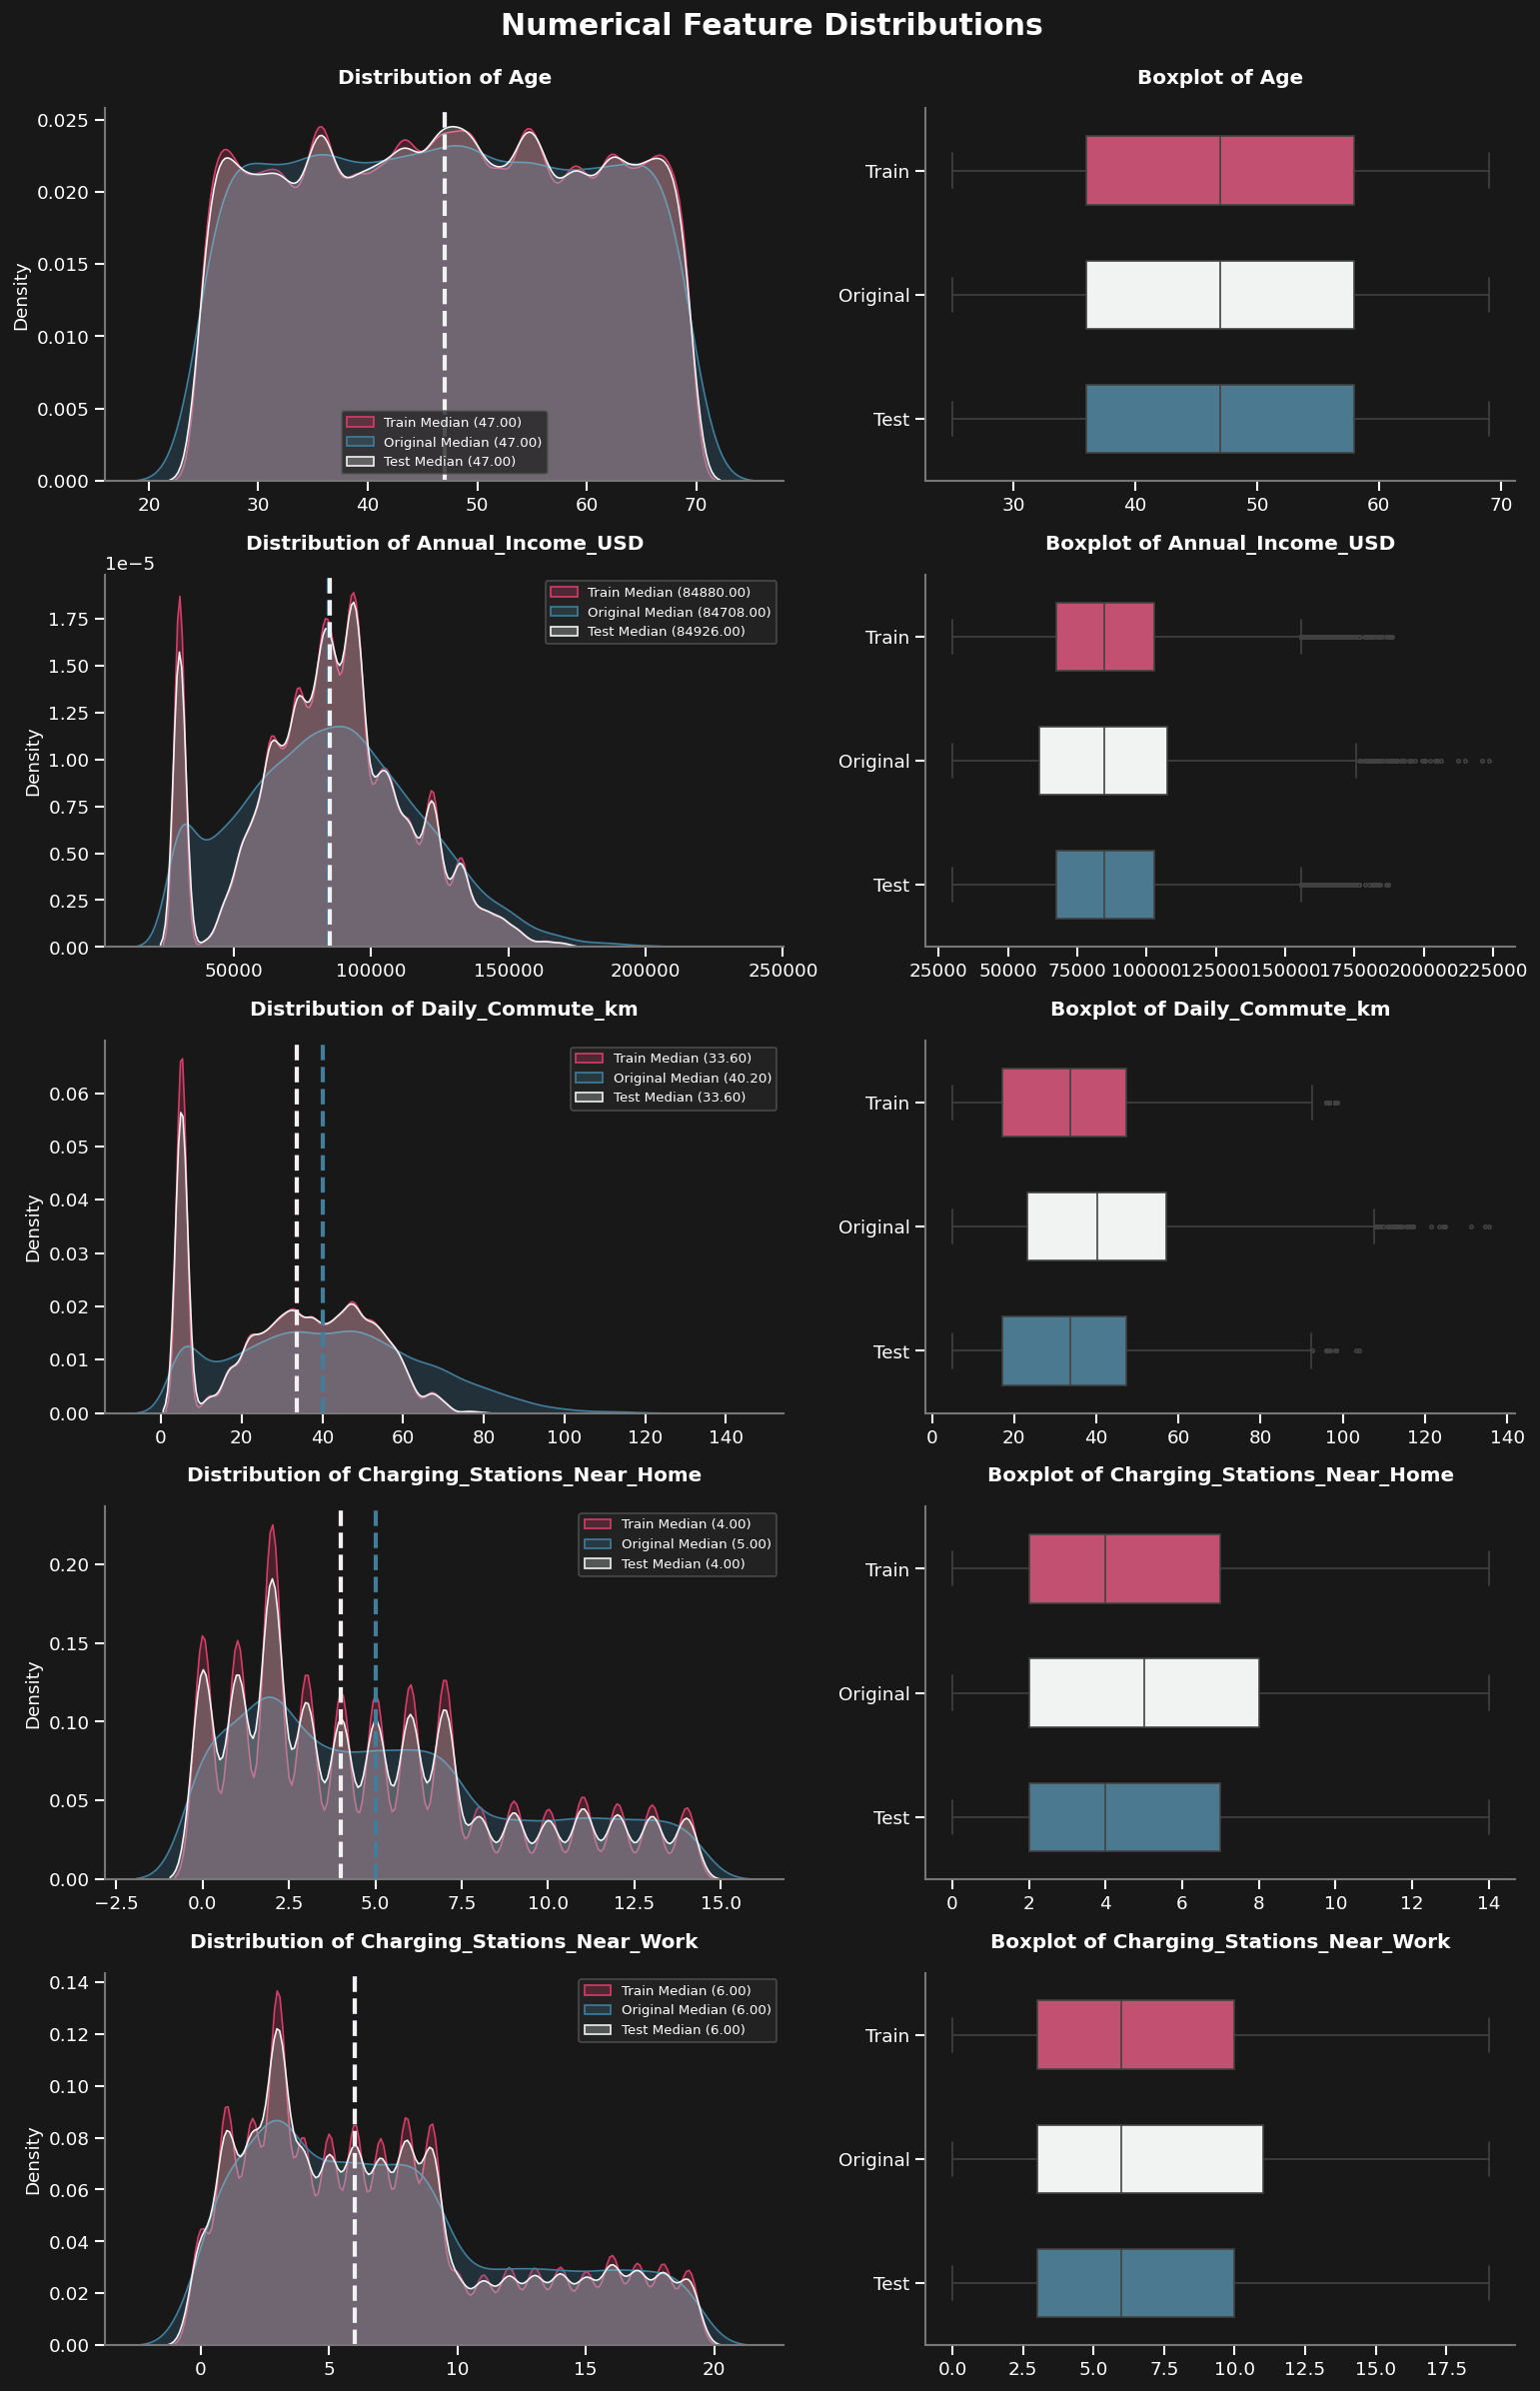

In [14]:
plot_numerical_features_v3(df_train=df_train, df_test=df_test, df_original=df_original, num_features=num_features)

### Analyze skewness

In [15]:
logger.info("-" * 80)
skew_feature = []
for name, df in datasets.items():
    logger.info(f"{name} Data Checking Skewness:")
    skew_feature.append(DataValidator.check_skewness(data=df, dataset_name= config["dataset"]["name"], 
                                                     numerical_features=num_features, logger=logger))
logger.info("-" * 80)
logger.info("Checking skewness successfully completed the dataset.")

2026-09-19 04:37:16 | INFO     | --------------------------------------------------------------------------------
2026-09-19 04:37:16 | INFO     | Train Dataset Data Checking Skewness:
2026-09-19 04:37:16 | INFO     | Skewness analysis for EV Adoption Prediction Dataset
2026-09-19 04:37:16 | INFO     | Total numerical features checked: 5
2026-09-19 04:37:16 | DEBUG    | ----------------------------------------------------------------------
2026-09-19 04:37:16 | DEBUG    | Feature                        | Skewness  | Remark
2026-09-19 04:37:16 | DEBUG    | ----------------------------------------------------------------------
2026-09-19 04:37:16 | DEBUG    | Charging_Stations_Near_Work    |   +0.7002 | Moderately skewed
2026-09-19 04:37:16 | DEBUG    | Charging_Stations_Near_Home    |   +0.6987 | Moderately skewed
2026-09-19 04:37:16 | DEBUG    | Daily_Commute_km               |   -0.0846 | Approximately symmetric
2026-09-19 04:37:16 | DEBUG    | Annual_Income_USD              |   -0.01

<div style="
     background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#90E0EF;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Distribution & Skewness Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li>The <b>training and test datasets</b> exhibit highly consistent numerical distributions across most features, with nearly identical medians, quartiles, and value ranges. This suggests <b>no meaningful distribution shift</b> between the competition training and test sets.</li>

<li><code>Age</code> is approximately symmetric in the training dataset (<code>skew ≈ -0.004</code>), with a median of <b>47 years</b>. The distributions across Train, Test, and Original datasets are highly similar.</li>

<li><code>Annual_Income_USD</code> is also approximately symmetric in the training dataset (<code>skew ≈ -0.013</code>). The Train and Test datasets show very similar income distributions, while the Original dataset exhibits a slightly more right-skewed distribution (<code>skew ≈ 0.305</code>) with a broader upper range.</li>

<li><code>Daily_Commute_km</code> is approximately symmetric in the training dataset (<code>skew ≈ -0.085</code>). However, the Original dataset has a higher median of approximately <b>40.2 km</b>, compared with approximately <b>33.6 km</b> in Train and Test, indicating a noticeable distribution difference in commuting distance.</li>

<li><code>Charging_Stations_Near_Home</code> and <code>Charging_Stations_Near_Work</code> are <b>moderately right-skewed</b> in the training dataset, with skewness values of approximately <code>0.70</code> and <code>0.70</code>, respectively. This indicates that most consumers have relatively moderate charging availability, while a smaller group has access to substantially more charging stations.</li>

<li>The same charging-related variables remain moderately right-skewed in the Original dataset, with skewness of approximately <code>0.57</code> for <code>Charging_Stations_Near_Home</code> and <code>0.61</code> for <code>Charging_Stations_Near_Work</code>. The overall distribution patterns remain comparable despite differences in skewness magnitude.</li>

<li><b>No highly skewed numerical features</b> were identified, as all observed skewness values remain below <code>|1|</code>. Therefore, there is no strong statistical requirement for logarithmic or Box-Cox transformation based solely on skewness.</li>

<li>For the charging-related count variables, the observed skewness is <b>structurally reasonable</b> because the number of available charging stations is a discrete count variable bounded within a relatively small range.</li>

<li><b>Overall</b>: The numerical features show generally stable and well-behaved distributions in the competition datasets. The main distribution difference compared with the Original dataset is observed in <code>Daily_Commute_km</code>, while the charging infrastructure variables exhibit moderate positive skewness that should be considered during modeling.</li>

</ul>

</div>

### Correlation Analysis of Numerical Features

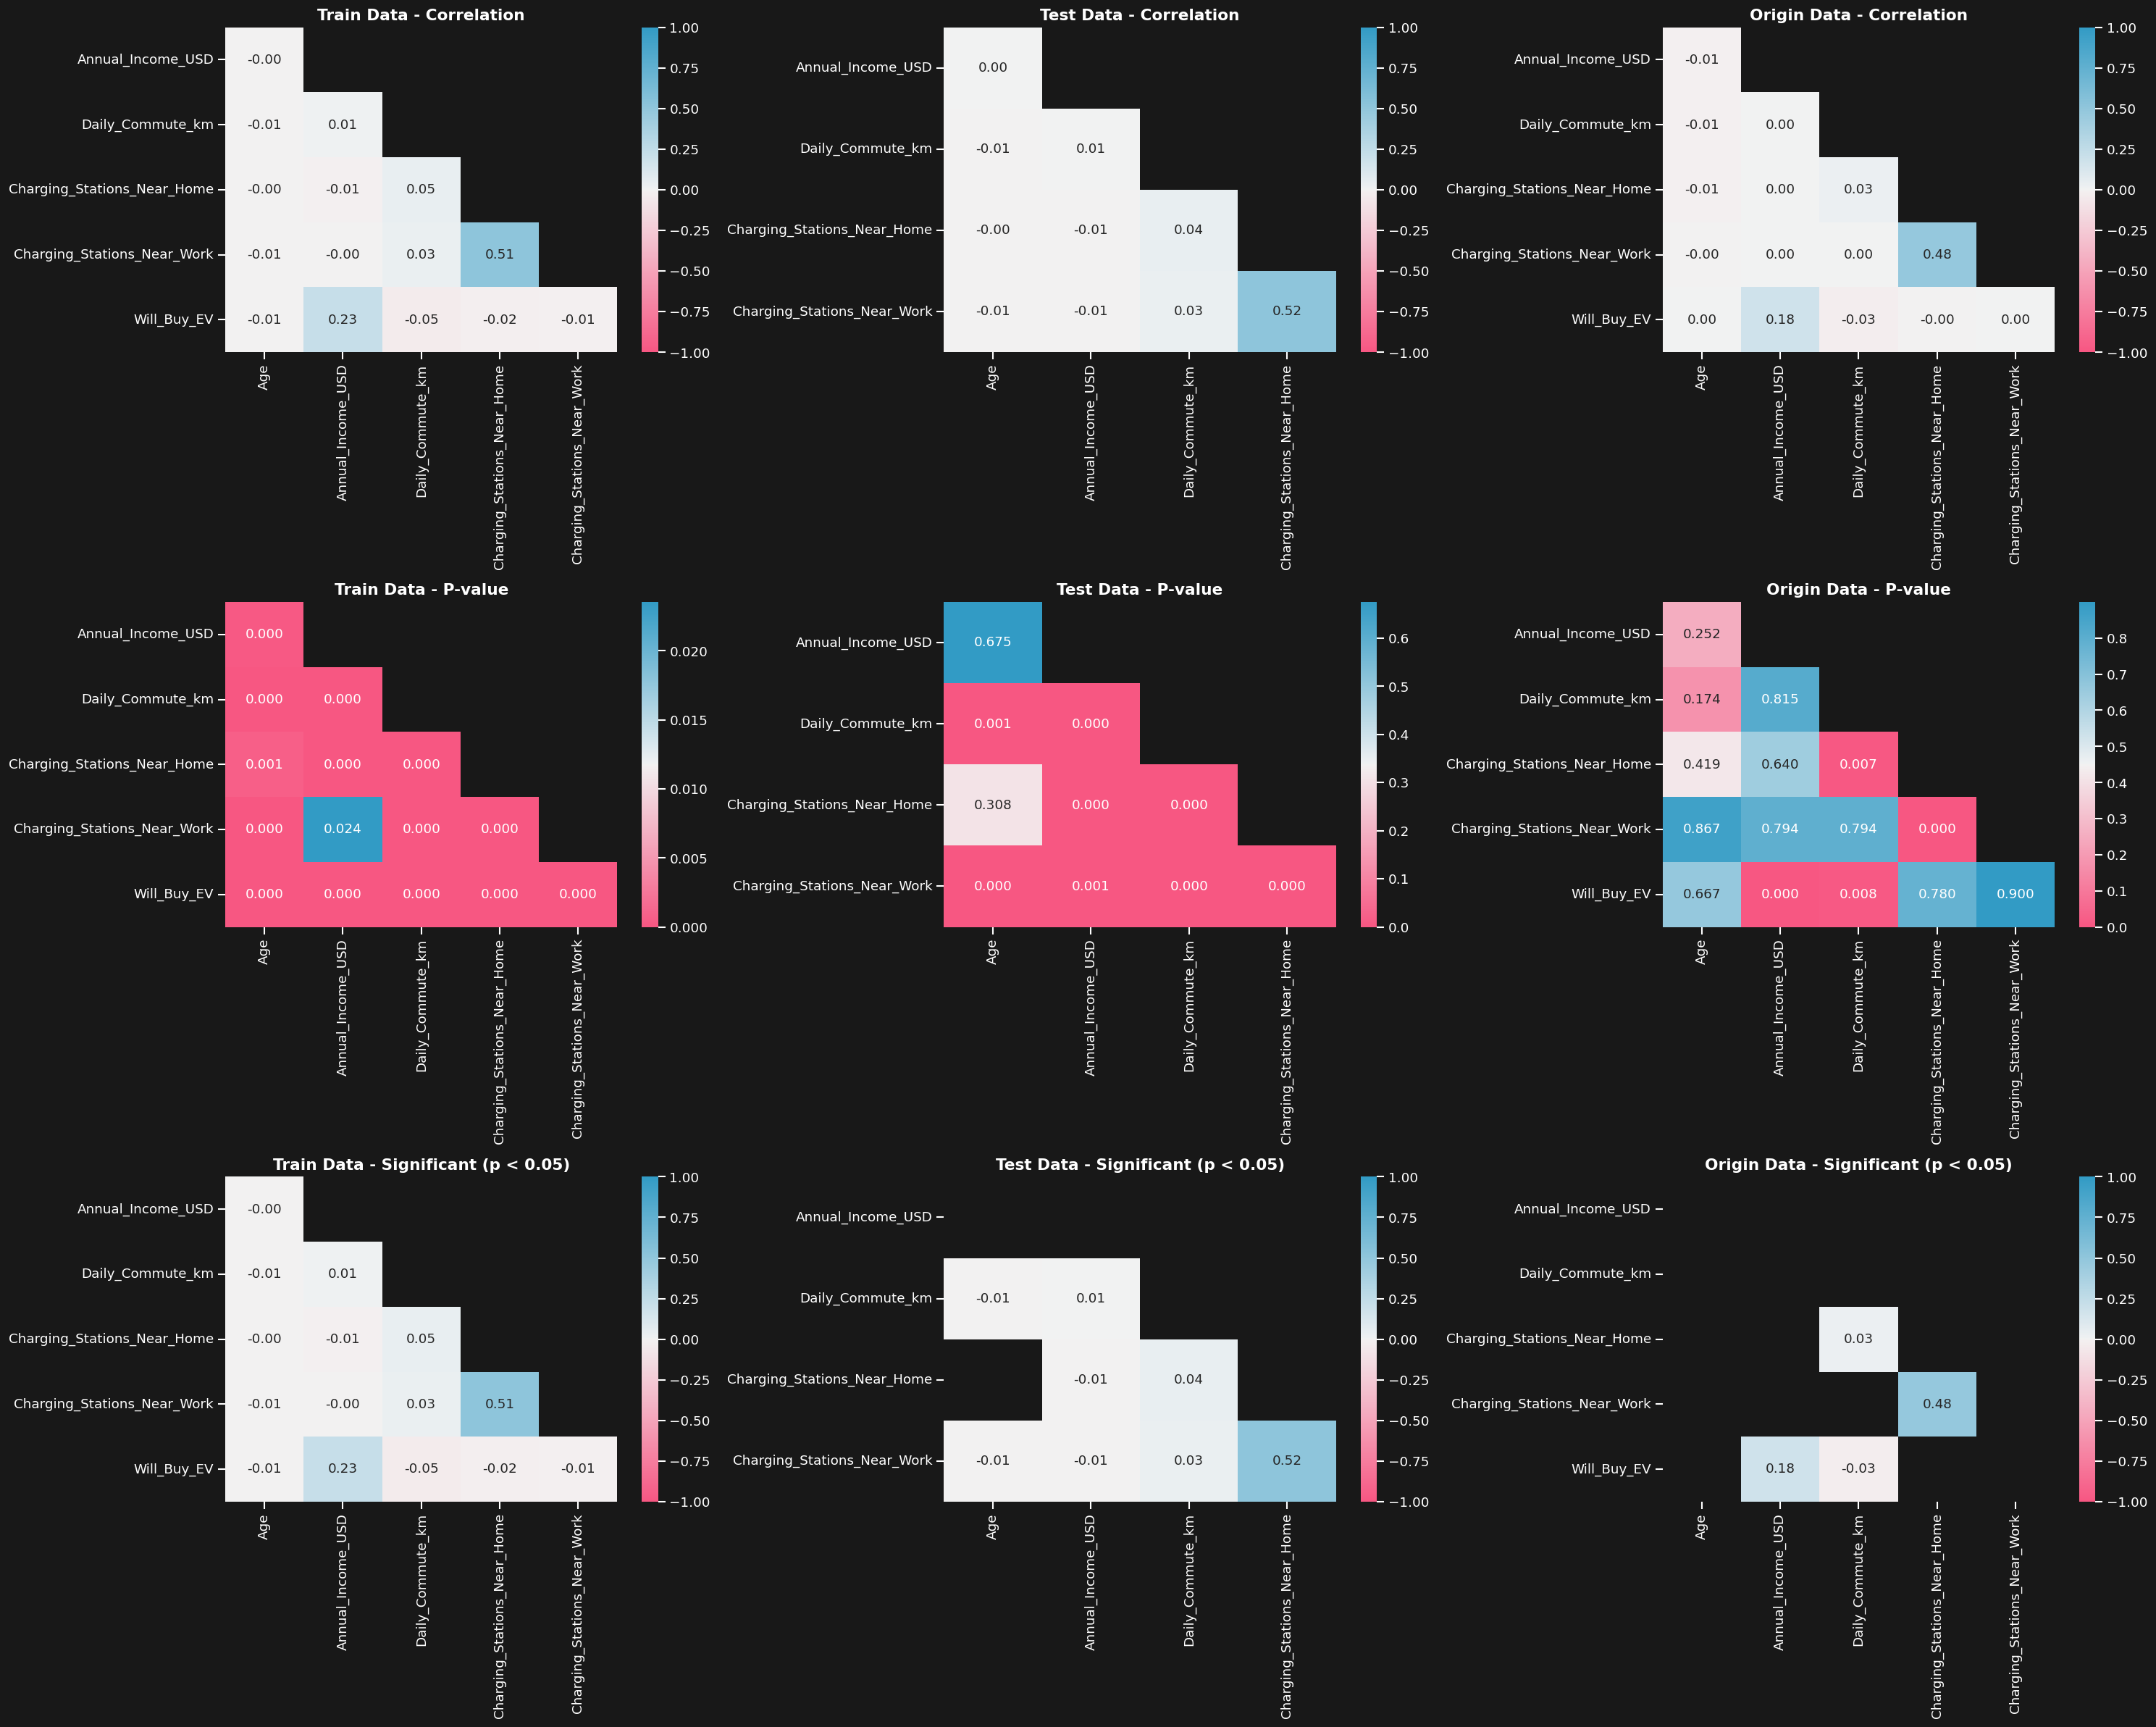

In [16]:
# Encode the binary target variable as 0/1 for correlation analysis.
mapping = {"No": 0, "Yes": 1}
df_train[config["target"]["feature"]] = df_train[config["target"]["feature"]].map(mapping)
df_original[config["target"]["feature"]] = df_original[config["target"]["feature"]].map(mapping)

# Visualize correlations and statistical significance across datasets.
StatUtils.plot_correlation_with_pvalue(df_train=df_train, df_test=df_test, df_origin=df_original)

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Correlation Analysis Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li>The <b>training, test, and original datasets</b> exhibit highly consistent correlation patterns, with similar correlation directions and magnitudes across the numerical features. This suggests <b>no meaningful structural shift</b> between the competition datasets and the original data.</li>

<li><code>Charging_Stations_Near_Home</code> and <code>Charging_Stations_Near_Work</code> show the strongest feature-to-feature relationship, with a moderate positive correlation of approximately <b>r ≈ 0.48–0.52</b> across the three datasets. This indicates that consumers living in areas with better charging infrastructure near home also tend to have greater charging availability near their workplace.</li>

<li><code>Will_Buy_EV</code> has the strongest relationship with <code>Annual_Income_USD</code>, with a positive correlation of approximately <b>r ≈ 0.18–0.23</b>. This suggests that higher-income consumers tend to show a greater likelihood of purchasing an electric vehicle.</li>

<li><code>Daily_Commute_km</code> has a <b>weak negative correlation</b> with <code>Will_Buy_EV</code> (<b>r ≈ -0.03 to -0.05</b>). Although statistically significant in the larger datasets, the small correlation magnitude indicates that commuting distance alone has <b>limited linear association</b> with EV purchase intention.</li>

<li>The remaining numerical features, including <code>Age</code>, <code>Charging_Stations_Near_Home</code>, and <code>Charging_Stations_Near_Work</code>, show <b>very weak correlations</b> with <code>Will_Buy_EV</code> (approximately <code>|r| &lt; 0.03</code>). These variables may still provide predictive value through nonlinear relationships or interactions with other features.</li>

<li>Most feature pairs have correlations close to <b>zero</b>, indicating generally <b>low multicollinearity</b>. The main exception is the relationship between the two charging infrastructure variables, which should be considered when interpreting feature importance or coefficients.</li>

<li>The <b>large training and test sample sizes</b> make even relatively weak correlations statistically significant (<code>p &lt; 0.05</code>). Therefore, statistical significance should not be confused with practical importance; the <b>correlation magnitude</b> remains important when evaluating predictive relevance.</li>

<li>Compared with the competition datasets, the <b>original dataset shows fewer statistically significant weak relationships</b>, which is expected given its substantially smaller sample size. However, the major correlation patterns remain consistent.</li>

<li><b>Overall</b>: <code>Annual_Income_USD</code> appears to be the strongest numerical indicator associated with EV purchase intention, while charging infrastructure variables show moderate correlation with each other. Overall multicollinearity is limited, providing a relatively clean numerical feature set for subsequent modeling.</li>

</ul>

</div>

## Categorical Feature Distributions

In [17]:
# ----- Run for all categorical features -----
for feature in cat_features:
    categorical_distribution_across_datasets(df_train=df_train, df_test=df_test, df_original=df_original, 
                                             feature=feature, logger=logger)

2026-09-19 04:37:22 | INFO     | Analyzing categorical feature: Gender
2026-09-19 04:37:22 | DEBUG    | Gender: 3 categories detected
2026-09-19 04:37:22 | INFO     | Categorical Feature Distribution: Gender:
  Category  Train_Count  Train_%  Test_Count  Test_%  Original_Count  Original_%
1     Male       367954    55.03      157647   55.01            5201       52.01
0   Female       295427    44.18      126669   44.20            4498       44.98
2    Other         5284     0.79        2255    0.79             301        3.01
2026-09-19 04:37:22 | INFO     | Completed analysis for: Gender
2026-09-19 04:37:22 | INFO     | ********************************************************************************
2026-09-19 04:37:22 | INFO     | Analyzing categorical feature: City_Type
2026-09-19 04:37:23 | DEBUG    | City_Type: 3 categories detected
2026-09-19 04:37:23 | INFO     | Categorical Feature Distribution: City_Type:
   Category  Train_Count  Train_%  Test_Count  Test_%  Original_Count  

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Categorical Feature Insights
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><code>Gender</code> is moderately dominated by <code>Male</code> consumers in the competition datasets, representing approximately <b>55%</b> of Train and Test observations, while <code>Female</code> accounts for approximately <b>44%</b>. The <code>Other</code> category is relatively rare at only <b>0.79%</b>. The Original dataset shows a similar Male/Female distribution, but a noticeably higher proportion of <code>Other</code> consumers (<b>3.01%</b>).</li>

<li><code>City_Type</code> is dominated by <code>Urban</code> consumers, accounting for approximately <b>43%</b> of both Train and Test datasets, followed by <code>Suburban</code> at approximately <b>38%</b>. <code>Rural</code> consumers represent around <b>19%</b>. Compared with the competition datasets, the Original dataset contains a higher proportion of <code>Urban</code> consumers (<b>49.41%</b>) and a lower proportion of <code>Rural</code> consumers (<b>14.96%</b>).</li>

<li><code>Current_Car_Type</code> is dominated by <code>Sedan</code> and <code>SUV</code> owners, which together account for more than <b>82%</b> of Train and Test observations. The Original dataset has a somewhat higher proportion of <code>Truck</code> and <code>Hatchback</code> owners, indicating a moderate difference in the current vehicle composition.</li>

<li><code>Home_Charging_Possible</code> is predominantly <code>Yes</code> in the competition datasets, representing approximately <b>69%</b> of both Train and Test consumers. However, this proportion decreases to <b>61.63%</b> in the Original dataset, suggesting a noticeable difference in home-charging availability between the original and competition data.</li>

<li><code>Subsidy_Available</code> is also dominated by <code>Yes</code>, accounting for approximately <b>63%</b> of Train and Test observations. The Original dataset shows a very similar distribution at approximately <b>60%</b>, indicating only a relatively small shift in subsidy availability.</li>

<li><code>Environmental_Concern_Level</code> has a <b>well-balanced distribution across all five levels</b>. In the Train and Test datasets, each category represents approximately <b>19–22%</b> of observations, suggesting that no particular environmental concern level dominates the competition data.</li>

<li><code>Range_Anxiety_Level</code> is highly concentrated in the <code>Low</code> category, representing approximately <b>90%</b> of Train and Test observations. The Original dataset has a lower proportion of <code>Low</code> range anxiety (<b>83.10%</b>) and higher proportions of <code>Medium</code> and <code>High</code>, indicating a noticeable distribution shift.</li>

<li><code>Number_of_Cars_Owned</code> is concentrated around <b>1–2 cars per consumer</b>, with these two categories accounting for approximately <b>88%</b> of Train and Test observations. The Original dataset contains relatively more consumers owning <b>3–4 cars</b>, indicating a moderate difference in vehicle ownership patterns.</li>

<li>The <b>training and test datasets exhibit highly consistent categorical distributions</b> across all features, with almost identical category proportions. This is a positive sign for competition modeling because the test set appears to closely represent the training population.</li>

<li>However, several categorical features show noticeable differences between the <b>competition datasets and the Original dataset</b>, particularly <code>Gender</code>, <code>Home_Charging_Possible</code>, <code>Range_Anxiety_Level</code>, and <code>Number_of_Cars_Owned</code>. These differences should be considered when interpreting how well the competition data represents the original population.</li>

<li><b>Overall</b>: The competition datasets provide stable categorical distributions between Train and Test, while the Original dataset reveals several population-level differences. Features related to <b>home charging, range anxiety, vehicle ownership, and urbanization</b> may therefore capture important differences in EV adoption behavior.</li>

</ul>

</div>

## Multivariate Statistical Analysis

,Will_Buy_EV,Count,Mean,Median,Std
0,No,551886,47.083293,47.000000,12.896488
1,Yes,116779,46.830654,47.000000,12.773543


2026-09-19 04:37:23 | INFO     | Checking normality of feature 'Age' by groups of 'Will_Buy_EV'...
2026-09-19 04:37:23 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-09-19 04:37:23 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:23 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-09-19 04:37:23 | DEBUG    | [Will_Buy_EV=No] skew=-0.0022, kurtosis=-1.1814 → Approximately symmetric, Normal tails
2026-09-19 04:37:23 | DEBUG    | [Will_Buy_EV=Yes] skew=-0.0126, kurtosis=-1.1396 → Approximately symmetric, Normal tails
2026-09-19 04:37:23 | INFO     | Generating Q–Q plots for visual assessment...


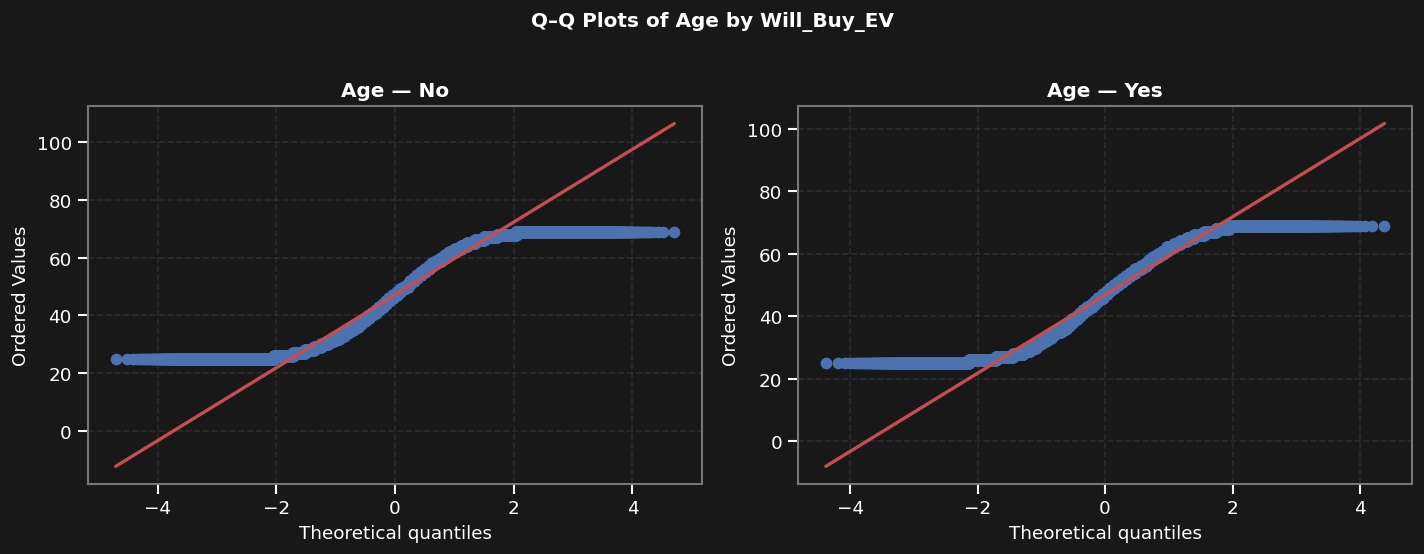

,Feature,Group,Skewness,Kurtosis,Remark
0,Age,No,-0.0022,-1.1814,"Approximately symmetric, Normal tails"
1,Age,Yes,-0.0126,-1.1396,"Approximately symmetric, Normal tails"


2026-09-19 04:37:25 | INFO     | All groups approximately follow a normal distribution.
2026-09-19 04:37:25 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-09-19 04:37:25 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,53.7311
1,p-value,0.000000
2,Max/Min Variance Ratio,1.02


2026-09-19 04:37:25 | INFO     | Interpretation:
2026-09-19 04:37:25 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-09-19 04:37:25 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-09-19 04:37:25 | INFO     | Running Independent Two-Sample T-Test: 'Age' ~ 'Will_Buy_EV'
2026-09-19 04:37:25 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:25 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-09-19 04:37:25 | INFO     | Comparing groups: 'No' vs 'Yes'
2026-09-19 04:37:25 | INFO     | p-value: 0.000000
2026-09-19 04:37:25 | INFO     | Cohen's d: 0.020
2026-09-19 04:37:25 | DEBUG    | t-statistic: 6.130
2026-09-19 04:37:25 | DEBUG    | Group means → No: 47.083, Yes: 46.831
2026-09-19 04:37:25 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-09-19 04:37:25 | INFO     | Conclusion: Significant difference between the two groups.
2026-09-19 04:37:25

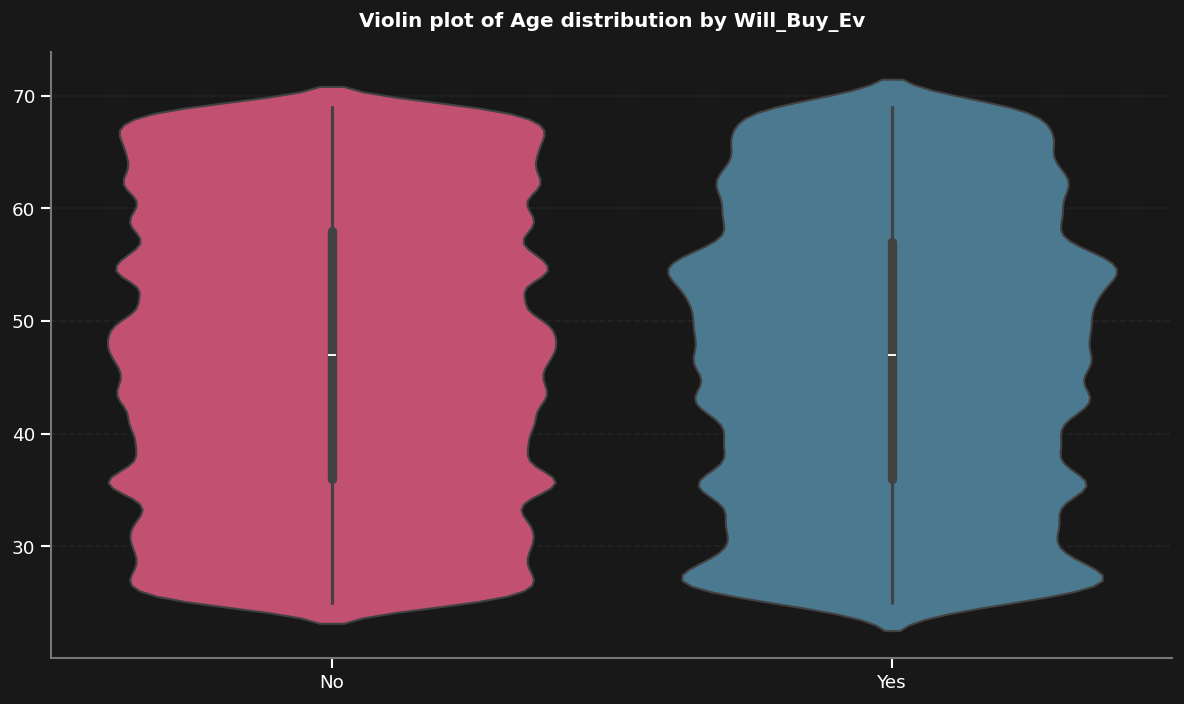

,Will_Buy_EV,Count,Mean,Median,Std
0,Yes,116779,98827.304688,96167.000000,26300.675910
1,No,551886,81794.585938,82844.000000,28237.155138


2026-09-19 04:37:28 | INFO     | Checking normality of feature 'Annual_Income_USD' by groups of 'Will_Buy_EV'...
2026-09-19 04:37:28 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-09-19 04:37:28 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:28 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-09-19 04:37:28 | DEBUG    | [Will_Buy_EV=No] skew=0.0042, kurtosis=-0.1797 → Approximately symmetric, Normal tails
2026-09-19 04:37:28 | DEBUG    | [Will_Buy_EV=Yes] skew=-0.0226, kurtosis=0.1137 → Approximately symmetric, Normal tails
2026-09-19 04:37:28 | INFO     | Generating Q–Q plots for visual assessment...


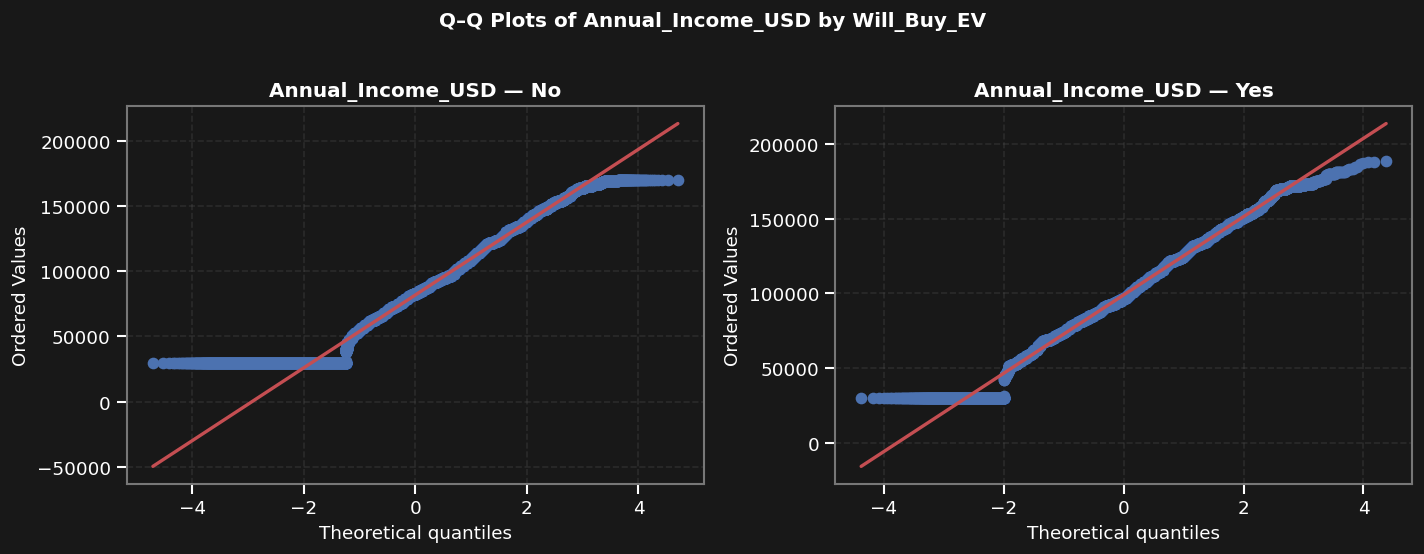

,Feature,Group,Skewness,Kurtosis,Remark
0,Annual_Income_USD,No,0.0042,-0.1797,"Approximately symmetric, Normal tails"
1,Annual_Income_USD,Yes,-0.0226,0.1137,"Approximately symmetric, Normal tails"


2026-09-19 04:37:30 | INFO     | All groups approximately follow a normal distribution.
2026-09-19 04:37:30 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-09-19 04:37:30 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,506.1255
1,p-value,0.000000
2,Max/Min Variance Ratio,1.15


2026-09-19 04:37:30 | INFO     | Interpretation:
2026-09-19 04:37:30 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-09-19 04:37:30 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-09-19 04:37:30 | INFO     | Running Independent Two-Sample T-Test: 'Annual_Income_USD' ~ 'Will_Buy_EV'
2026-09-19 04:37:30 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:30 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-09-19 04:37:30 | INFO     | Comparing groups: 'No' vs 'Yes'
2026-09-19 04:37:30 | INFO     | p-value: 0.000000
2026-09-19 04:37:30 | INFO     | Cohen's d: -0.624
2026-09-19 04:37:30 | DEBUG    | t-statistic: -198.429
2026-09-19 04:37:30 | DEBUG    | Group means → No: 81794.570, Yes: 98827.305
2026-09-19 04:37:30 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-09-19 04:37:30 | INFO     | Conclusion: Significant difference between the two gro

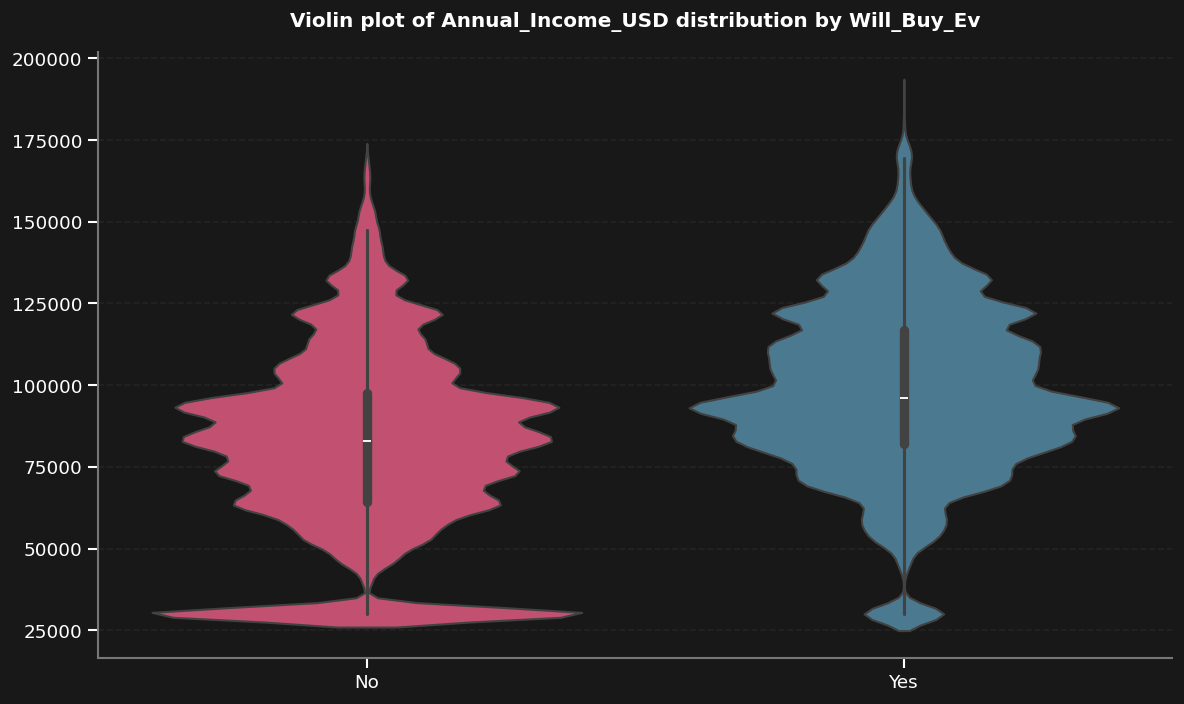

,Will_Buy_EV,Count,Mean,Median,Std
0,No,551886,32.553478,34.000000,18.820772
1,Yes,116779,30.290714,31.700001,18.181942


2026-09-19 04:37:33 | INFO     | Checking normality of feature 'Daily_Commute_km' by groups of 'Will_Buy_EV'...
2026-09-19 04:37:33 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-09-19 04:37:33 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:33 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-09-19 04:37:33 | DEBUG    | [Will_Buy_EV=No] skew=-0.0993, kurtosis=-1.0422 → Approximately symmetric, Normal tails
2026-09-19 04:37:33 | DEBUG    | [Will_Buy_EV=Yes] skew=-0.0299, kurtosis=-1.1629 → Approximately symmetric, Normal tails
2026-09-19 04:37:33 | INFO     | Generating Q–Q plots for visual assessment...


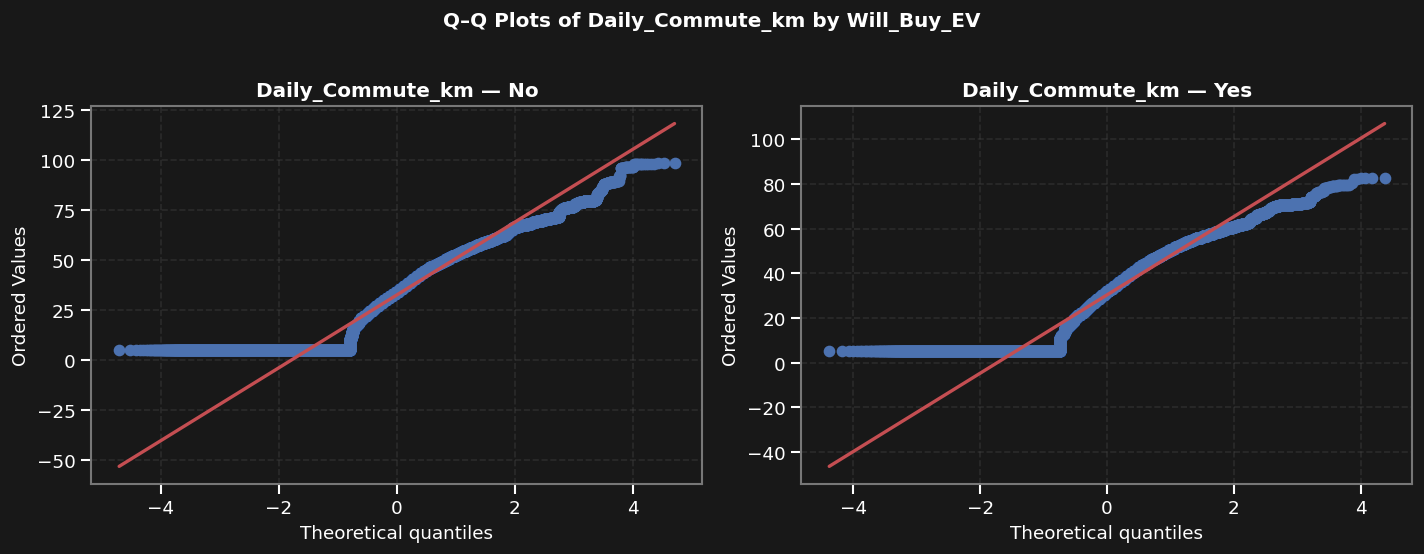

,Feature,Group,Skewness,Kurtosis,Remark
0,Daily_Commute_km,No,-0.0993,-1.0422,"Approximately symmetric, Normal tails"
1,Daily_Commute_km,Yes,-0.0299,-1.1629,"Approximately symmetric, Normal tails"


2026-09-19 04:37:35 | INFO     | All groups approximately follow a normal distribution.
2026-09-19 04:37:35 | INFO     | Check homogeneity of variances across groups using Levene’s test (median-centered)
2026-09-19 04:37:35 | DEBUG    | Number of groups detected: 2


,Metric,Value
0,Levene’s Statistic,82.6108
1,p-value,0.000000
2,Max/Min Variance Ratio,1.07


2026-09-19 04:37:35 | INFO     | Interpretation:
2026-09-19 04:37:35 | INFO     | - Status: Statistically different variances, but practical difference is small.
2026-09-19 04:37:35 | INFO     | - Recommendation: ANOVA or T-Test are acceptable, but Welch’s ANOVA or Welch’s T-Test is recommended.
2026-09-19 04:37:35 | INFO     | Running Independent Two-Sample T-Test: 'Daily_Commute_km' ~ 'Will_Buy_EV'
2026-09-19 04:37:35 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:35 | DEBUG    | Test Type: Welch’s T-Test (unequal variances)
2026-09-19 04:37:35 | INFO     | Comparing groups: 'No' vs 'Yes'
2026-09-19 04:37:35 | INFO     | p-value: 0.000000
2026-09-19 04:37:35 | INFO     | Cohen's d: 0.122
2026-09-19 04:37:35 | DEBUG    | t-statistic: 38.398
2026-09-19 04:37:35 | DEBUG    | Group means → No: 32.553, Yes: 30.291
2026-09-19 04:37:35 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-09-19 04:37:35 | INFO     | Conclusion: Significant difference between the two groups.
2026-

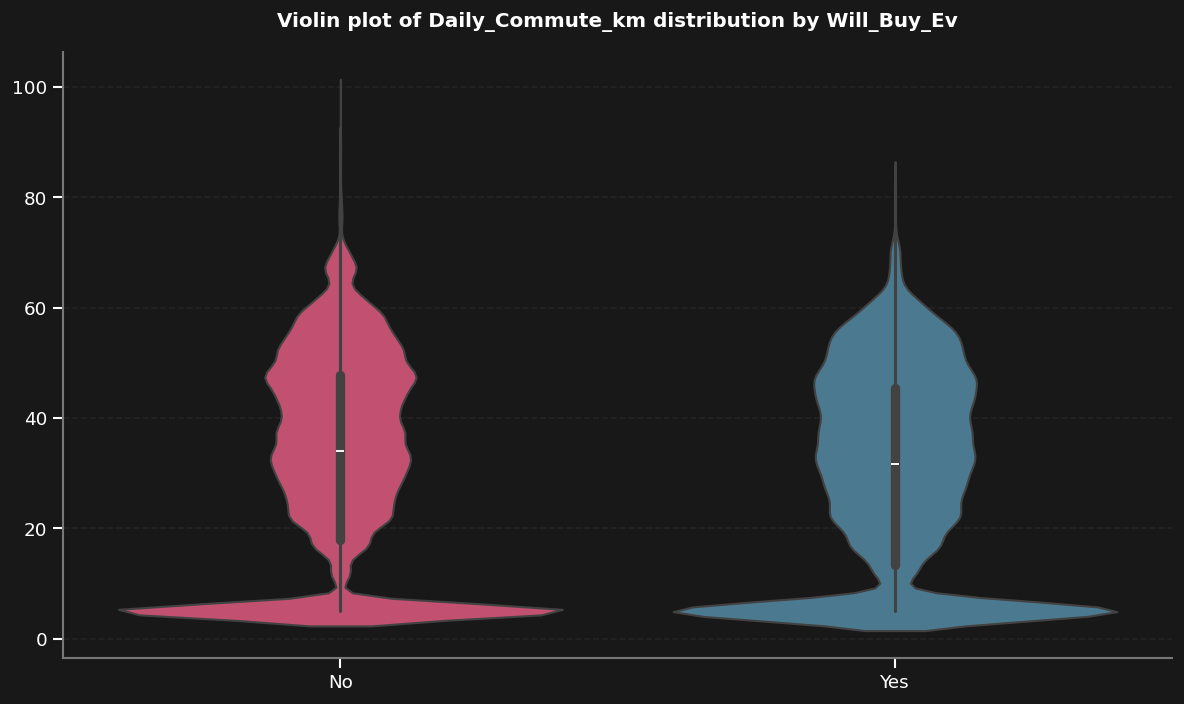

,Will_Buy_EV,Count,Mean,Median,Std
0,No,551886,4.989947,4.000000,3.919259
1,Yes,116779,4.820807,4.000000,3.959525


2026-09-19 04:37:38 | INFO     | Checking normality of feature 'Charging_Stations_Near_Home' by groups of 'Will_Buy_EV'...
2026-09-19 04:37:38 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-09-19 04:37:38 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:38 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-09-19 04:37:38 | DEBUG    | [Will_Buy_EV=No] skew=0.6897, kurtosis=-0.4864 → Moderately skewed, Normal tails
2026-09-19 04:37:38 | DEBUG    | [Will_Buy_EV=Yes] skew=0.7438, kurtosis=-0.4564 → Moderately skewed, Normal tails
2026-09-19 04:37:38 | INFO     | Generating Q–Q plots for visual assessment...


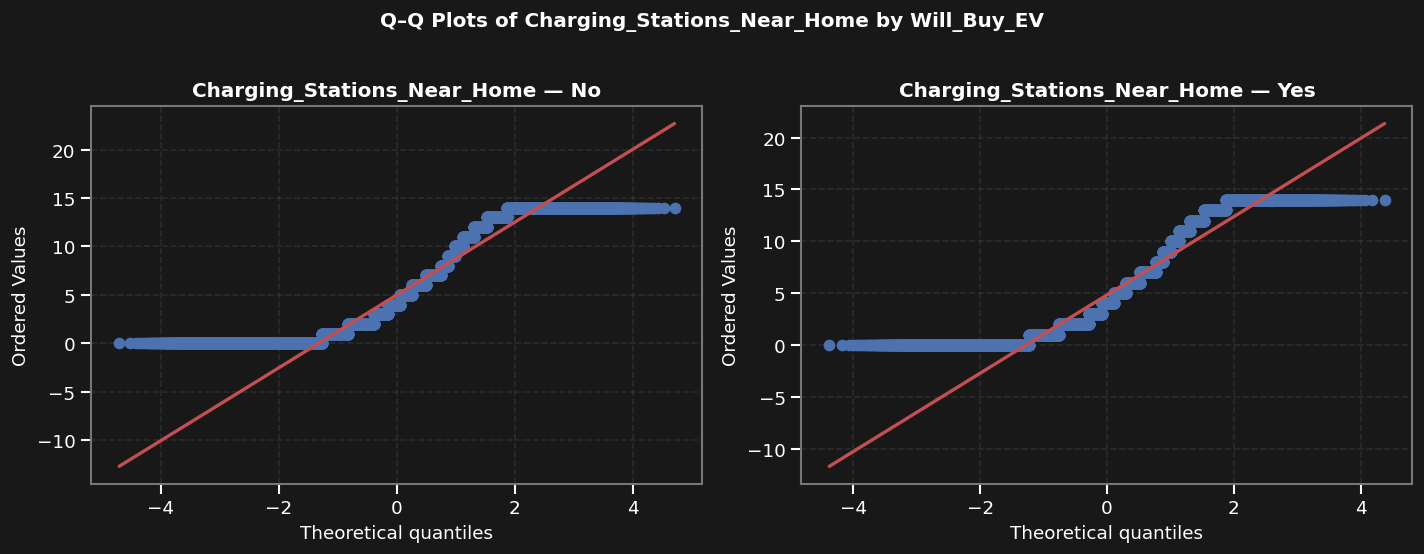

,Feature,Group,Skewness,Kurtosis,Remark
0,Charging_Stations_Near_Home,No,0.6897,-0.4864,"Moderately skewed, Normal tails"
1,Charging_Stations_Near_Home,Yes,0.7438,-0.4564,"Moderately skewed, Normal tails"


2026-09-19 04:37:40 | WARNING  | Normality assumption violated in at least one group.
2026-09-19 04:37:40 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-09-19 04:37:40 | INFO     | Running Mann–Whitney U Test: 'Charging_Stations_Near_Home' by 'Will_Buy_EV'...
2026-09-19 04:37:40 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:40 | INFO     | U statistic: 33248197432.0
2026-09-19 04:37:40 | INFO     | p-value    : 0.000000
2026-09-19 04:37:42 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-09-19 04:37:42 | INFO     | Conclusion: Significant difference between the two groups.
2026-09-19 04:37:42 | INFO     | Effect size (r): 0.0209
2026-09-19 04:37:42 | INFO     | Effect size interpretation: Negligible
2026-09-19 04:37:42 | INFO     | Cliff's Delta: -0.0318
2026-09-19 04:37:42 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


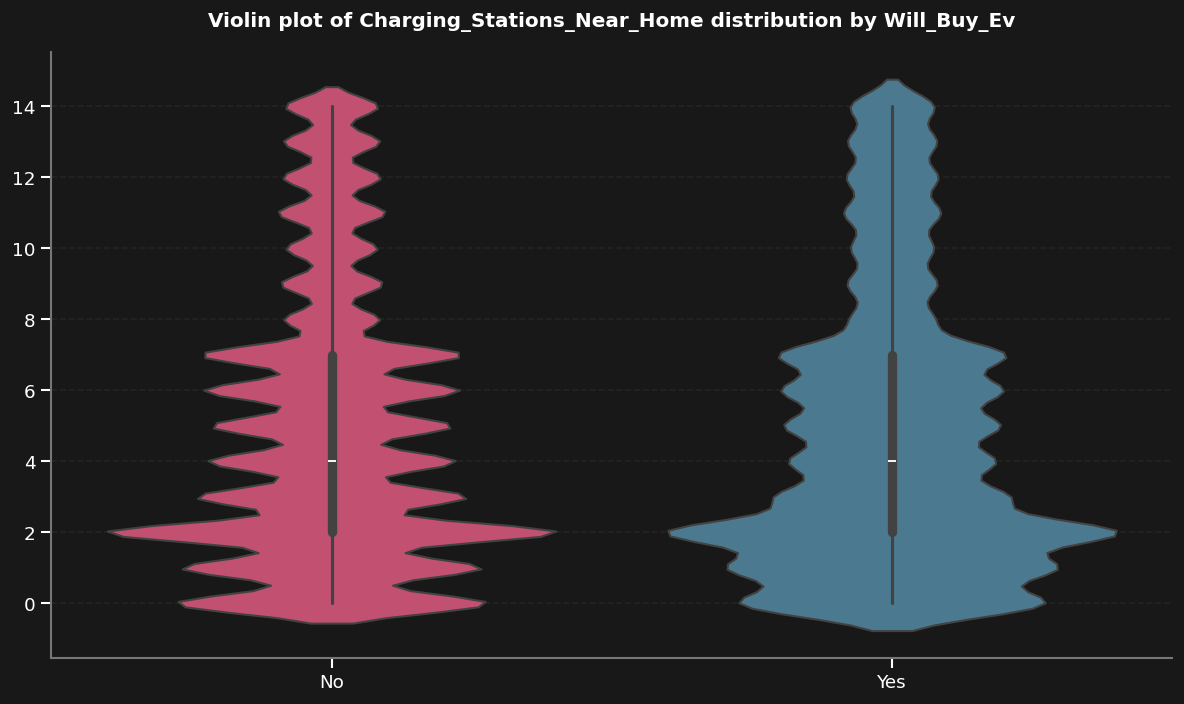

,Will_Buy_EV,Count,Mean,Median,Std
0,No,551886,7.205490,6.000000,5.185977
1,Yes,116779,7.038432,6.000000,5.187498


2026-09-19 04:37:45 | INFO     | Checking normality of feature 'Charging_Stations_Near_Work' by groups of 'Will_Buy_EV'...
2026-09-19 04:37:45 | INFO     | Evaluating distribution characteristics (skewness & kurtosis)...
2026-09-19 04:37:45 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:45 | DEBUG    | Thresholds → |skew|≤0.5, |kurtosis|≤1.5
2026-09-19 04:37:45 | DEBUG    | [Will_Buy_EV=No] skew=0.6944, kurtosis=-0.4975 → Moderately skewed, Normal tails
2026-09-19 04:37:45 | DEBUG    | [Will_Buy_EV=Yes] skew=0.7283, kurtosis=-0.4476 → Moderately skewed, Normal tails
2026-09-19 04:37:45 | INFO     | Generating Q–Q plots for visual assessment...


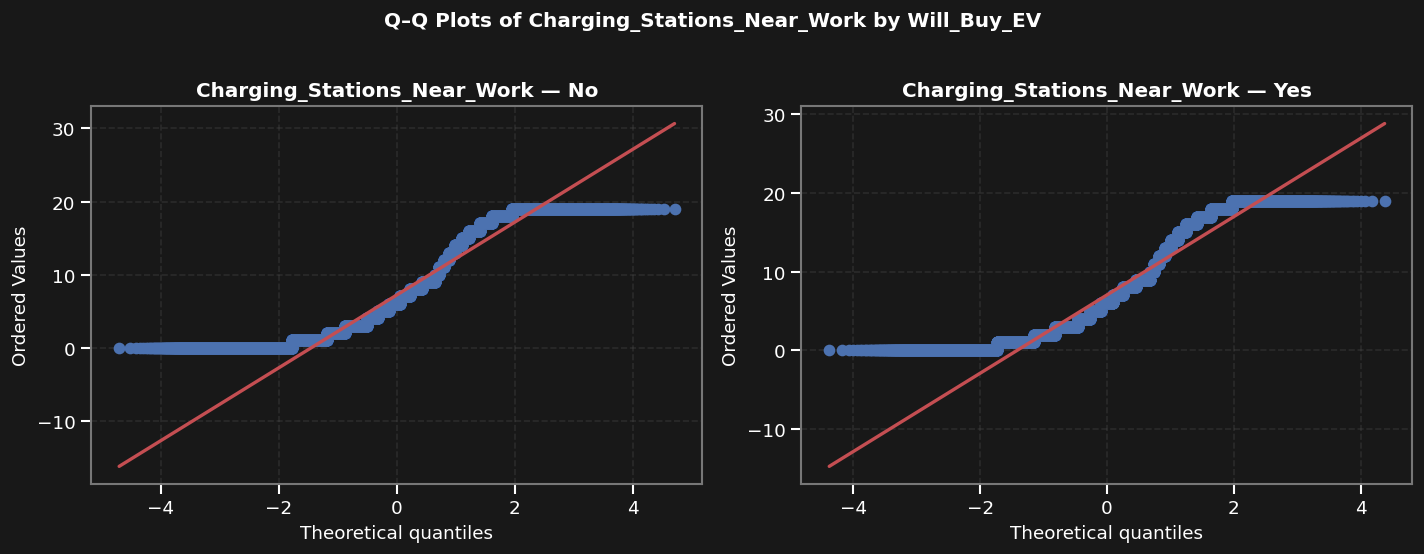

,Feature,Group,Skewness,Kurtosis,Remark
0,Charging_Stations_Near_Work,No,0.6944,-0.4975,"Moderately skewed, Normal tails"
1,Charging_Stations_Near_Work,Yes,0.7283,-0.4476,"Moderately skewed, Normal tails"


2026-09-19 04:37:47 | WARNING  | Normality assumption violated in at least one group.
2026-09-19 04:37:47 | INFO     | Recommendation: Use non-parametric tests (Kruskal–Wallis / Mann–Whitney U).
2026-09-19 04:37:47 | INFO     | Running Mann–Whitney U Test: 'Charging_Stations_Near_Work' by 'Will_Buy_EV'...
2026-09-19 04:37:47 | DEBUG    | Number of groups detected: 2
2026-09-19 04:37:47 | INFO     | U statistic: 32908779219.5
2026-09-19 04:37:47 | INFO     | p-value    : 0.000000
2026-09-19 04:37:49 | INFO     | Result: p-value ≤ 0.05 → Reject H0
2026-09-19 04:37:49 | INFO     | Conclusion: Significant difference between the two groups.
2026-09-19 04:37:49 | INFO     | Effect size (r): 0.0140
2026-09-19 04:37:49 | INFO     | Effect size interpretation: Negligible
2026-09-19 04:37:49 | INFO     | Cliff's Delta: -0.0212
2026-09-19 04:37:49 | INFO     | Effect size (Cliff's Delta) interpretation: Negligible


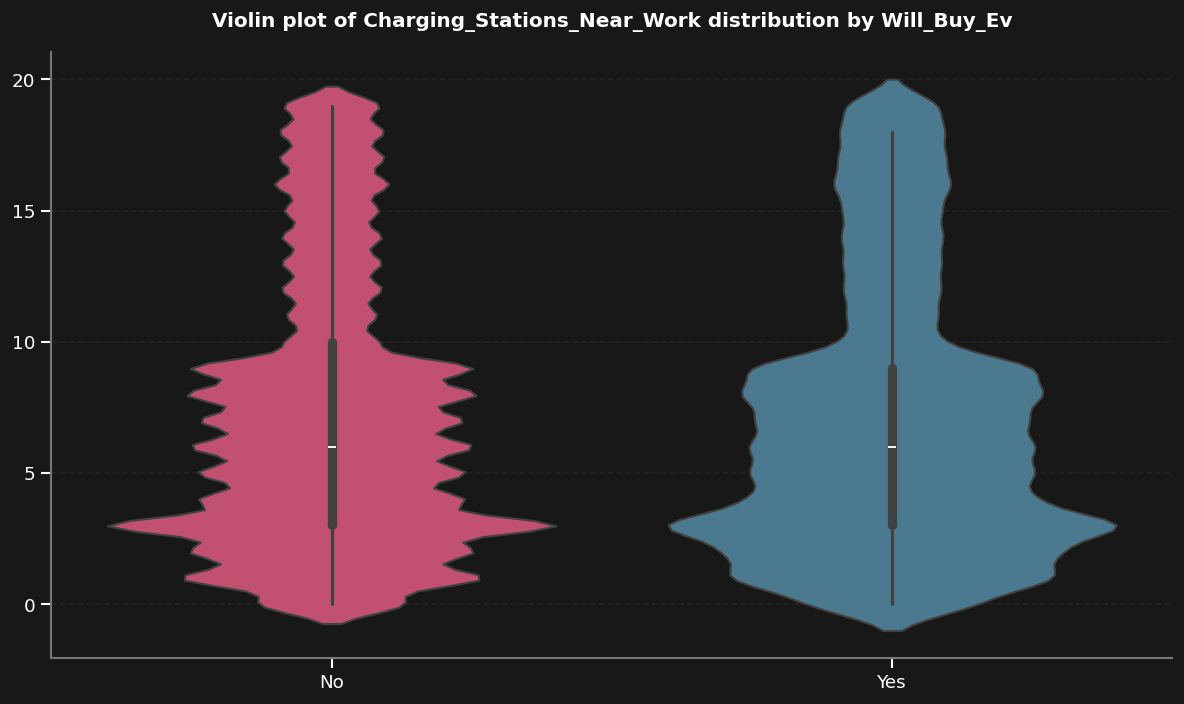

In [18]:
# Map the binary target back to readable labels for analysis.
mapping = {0: "No", 1: "Yes"}

df_plot = df_train.copy()
df_plot[config["target"]["feature"]] = df_plot[config["target"]["feature"]].map(mapping)

for feature in num_features:
    # Display a title for the current feature.
    display(
        HTML(
            f"<h2 style='text-align:center; font-size:22px; color:#fde68a;'>"
            f"<b>Distribution of {feature} by EV Purchase Decision</b>"
            f"</h2>"
        )
    )

    # Analyze the feature distribution across target classes.
    StatUtils.analyze_numeric_feature_by_target(
        feature=feature,
        df=df_plot,
        logger=logger,
        target_feature=config["target"]["feature"],
    )

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Numerical Features by EV Purchase Decision
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><b>Age:</b> Age differs statistically between EV buyers and non-buyers (p &lt; 0.001), but the mean difference is only <b>~0.25 years</b> with a negligible effect size (Cohen’s d = <b>0.020</b>), suggesting that <b>age has limited practical impact on EV purchase decisions</b>.</li>

<li><b>Annual_Income_USD:</b> Income differs significantly between the two groups (p &lt; 0.001), with EV buyers having substantially higher average income (<b>~$98,827 vs. ~$81,795</b>) and a large effect size (Cohen’s d = <b>0.624</b>), suggesting that <b>income is an important factor in EV purchase decisions</b>.</li>

<li><b>Daily_Commute_km:</b> Daily commuting distance differs significantly (p &lt; 0.001), but the effect size is small (Cohen’s d = <b>0.122</b>); non-EV buyers have a slightly longer average commute (<b>~32.55 km vs. ~30.29 km</b>), suggesting that <b>Daily_Commute_km has limited practical impact on EV purchase decisions</b>.</li>

<li><b>Charging_Stations_Near_Home:</b> The number of charging stations near home differs significantly between the two groups (p &lt; 0.001), but the effect size is negligible (r = <b>0.021</b>; Cliff’s δ = <b>-0.032</b>), suggesting <b>very limited practical impact on EV purchase decisions</b>.</li>

<li><b>Charging_Stations_Near_Work:</b> The number of charging stations near work differs significantly between the two groups (p &lt; 0.001), but the effect size is negligible (r = <b>0.014</b>; Cliff’s δ = <b>-0.021</b>), suggesting <b>very limited practical impact on EV purchase decisions</b>.</li>

</ul>

</div>

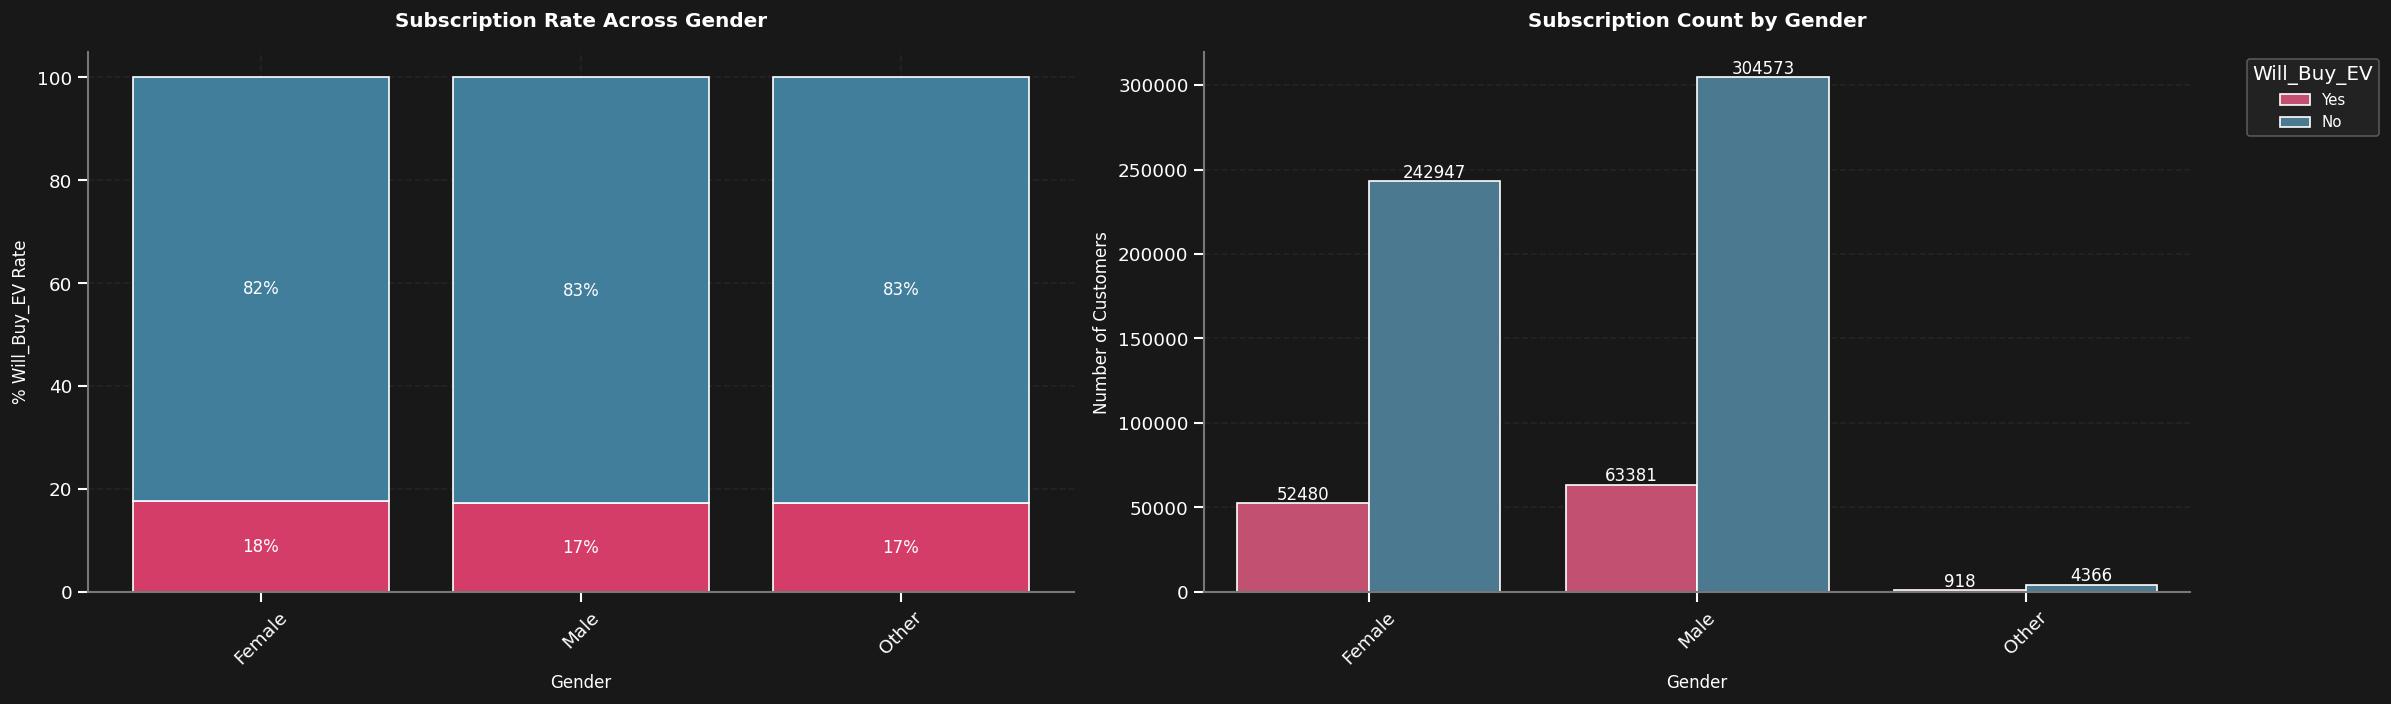

2026-09-19 04:37:53 | INFO     | Chi-Square Test of Independence: 'Gender' vs. 'Will_Buy_EV'...
2026-09-19 04:37:53 | INFO     | Chi-squared statistic: 33.041
2026-09-19 04:37:53 | INFO     | Degrees of freedom: 2
2026-09-19 04:37:53 | INFO     | p-value: 0.000000
2026-09-19 04:37:53 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:37:53 | INFO     | Variables 'Gender' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:37:53 | DEBUG    | Displaying standardized residuals heatmap.


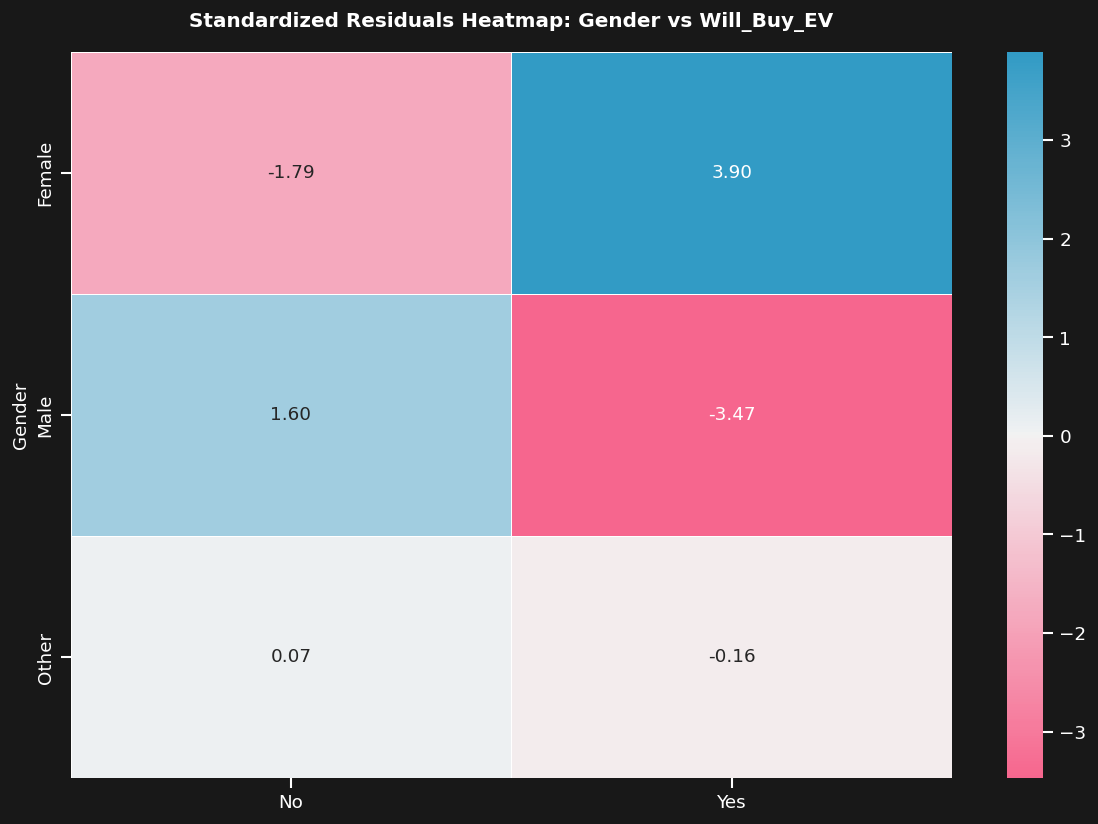

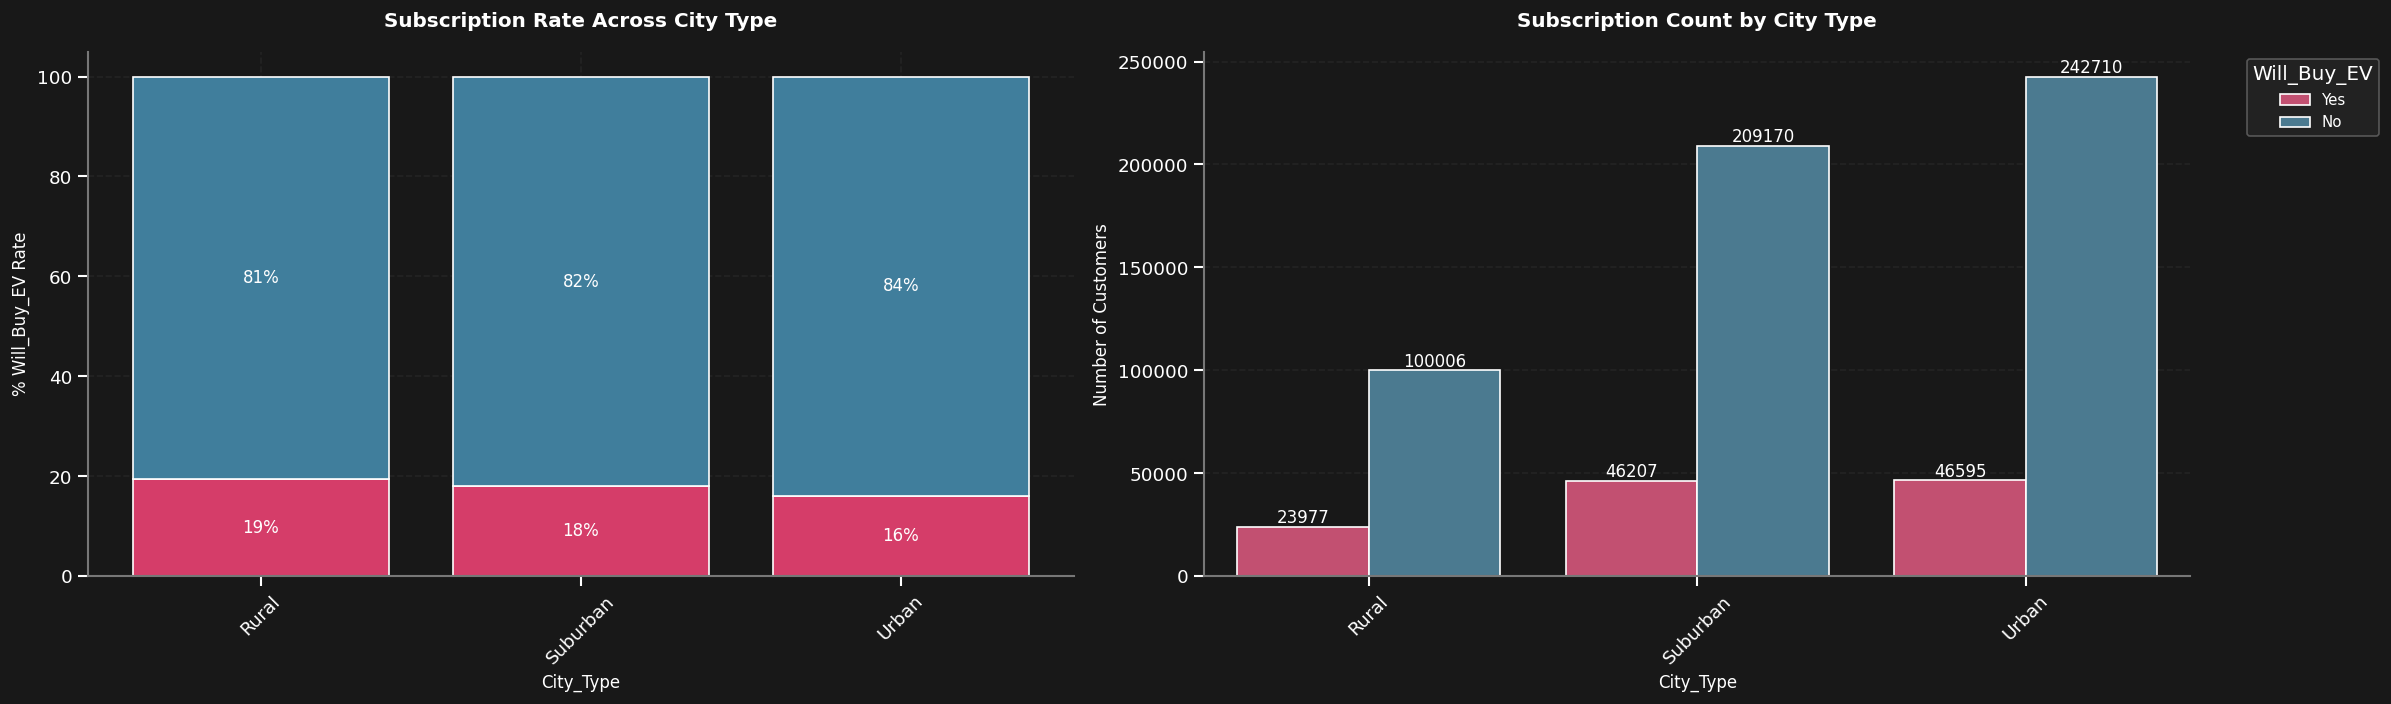

2026-09-19 04:37:55 | INFO     | Chi-Square Test of Independence: 'City_Type' vs. 'Will_Buy_EV'...
2026-09-19 04:37:55 | INFO     | Chi-squared statistic: 742.830
2026-09-19 04:37:55 | INFO     | Degrees of freedom: 2
2026-09-19 04:37:55 | INFO     | p-value: 0.000000
2026-09-19 04:37:55 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:37:55 | INFO     | Variables 'City_Type' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:37:55 | DEBUG    | Displaying standardized residuals heatmap.


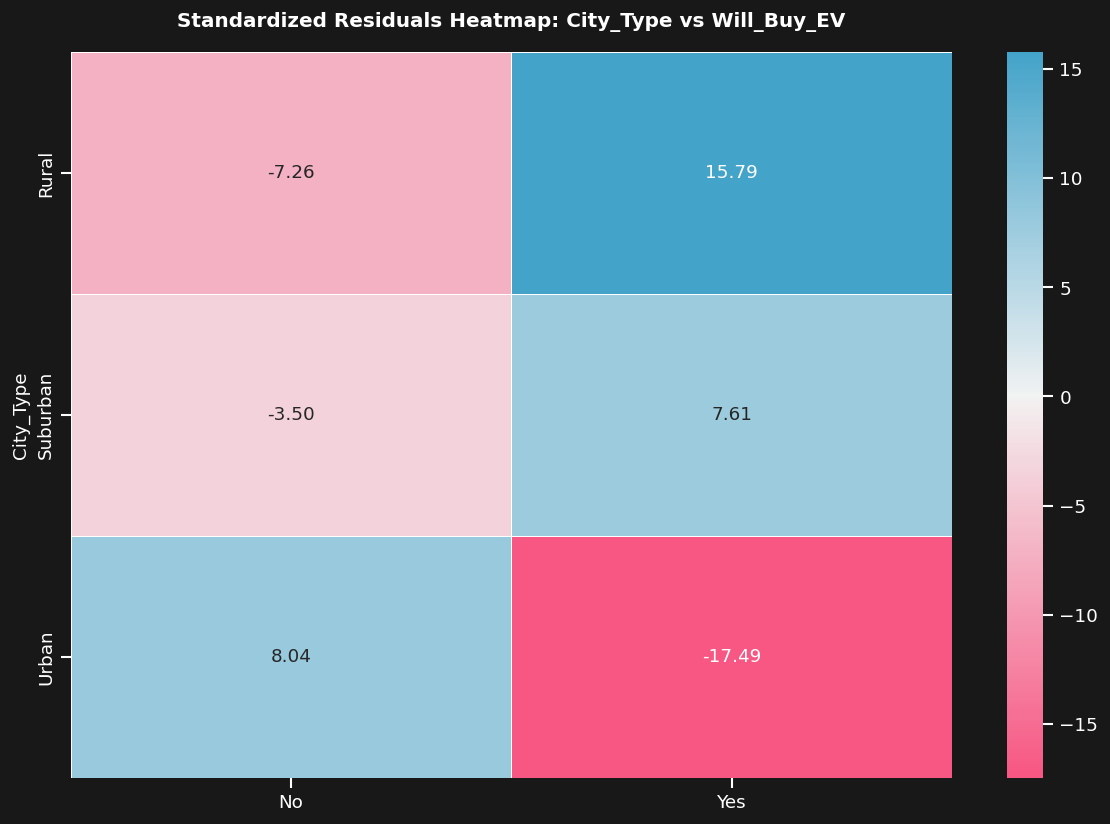

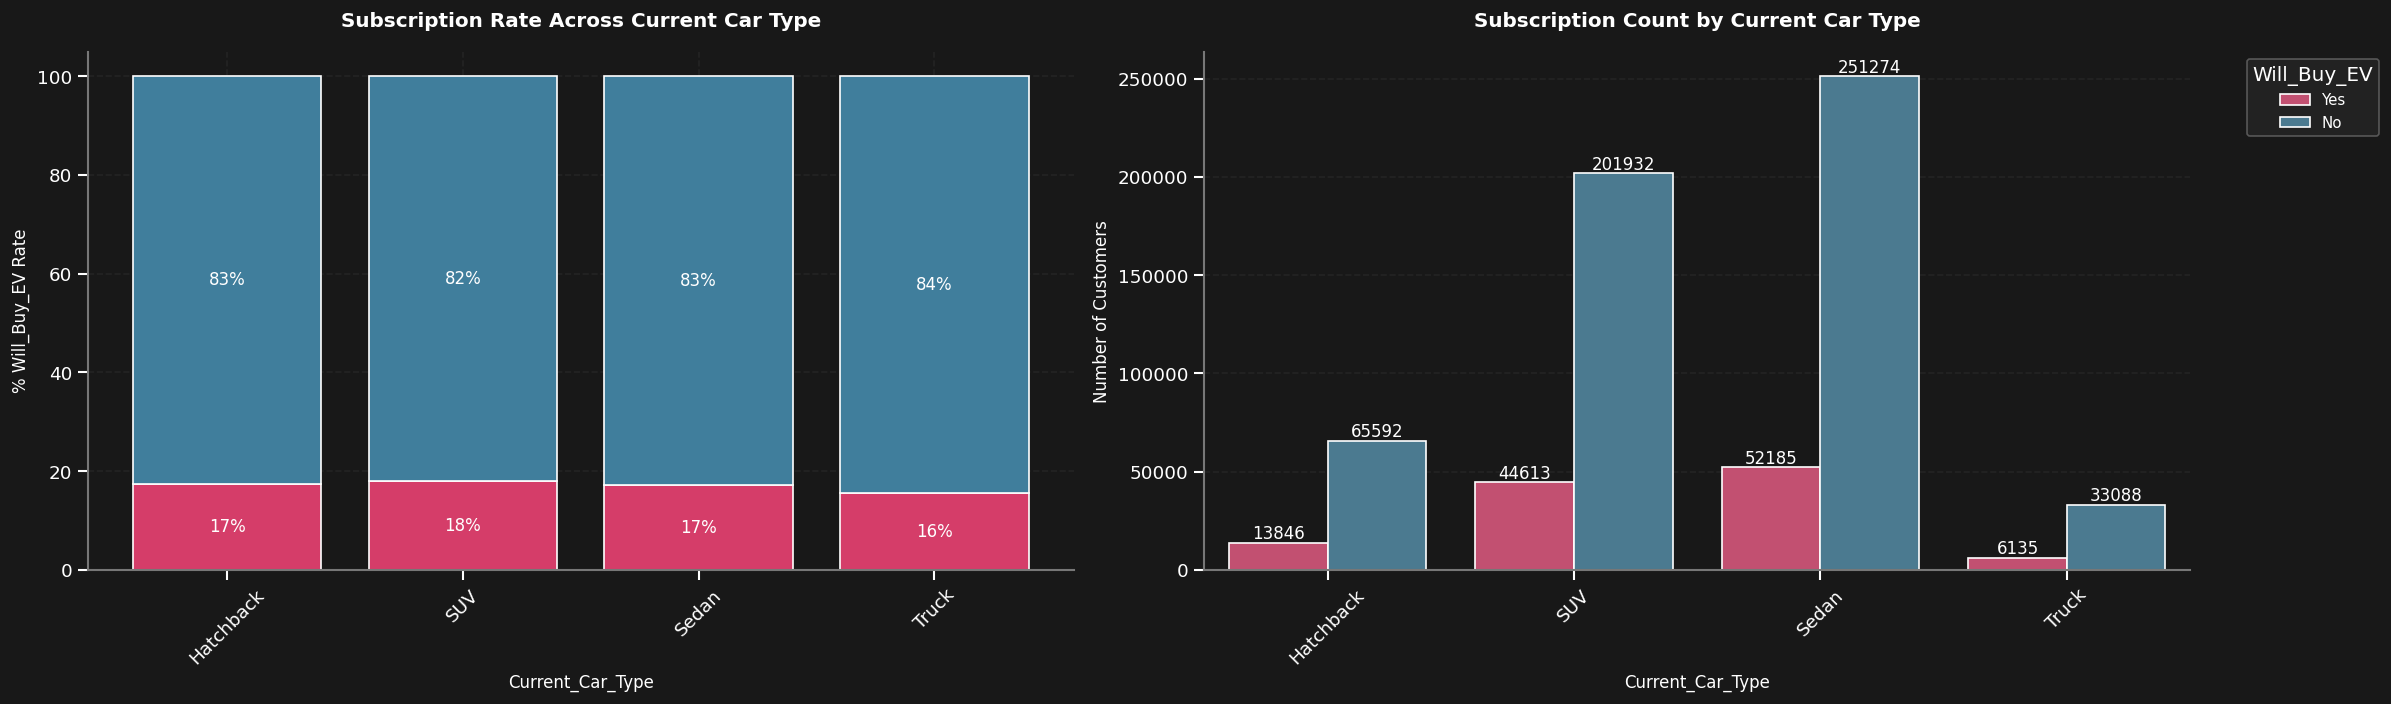

2026-09-19 04:37:56 | INFO     | Chi-Square Test of Independence: 'Current_Car_Type' vs. 'Will_Buy_EV'...
2026-09-19 04:37:56 | INFO     | Chi-squared statistic: 173.663
2026-09-19 04:37:56 | INFO     | Degrees of freedom: 3
2026-09-19 04:37:56 | INFO     | p-value: 0.000000
2026-09-19 04:37:56 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:37:56 | INFO     | Variables 'Current_Car_Type' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:37:56 | DEBUG    | Displaying standardized residuals heatmap.


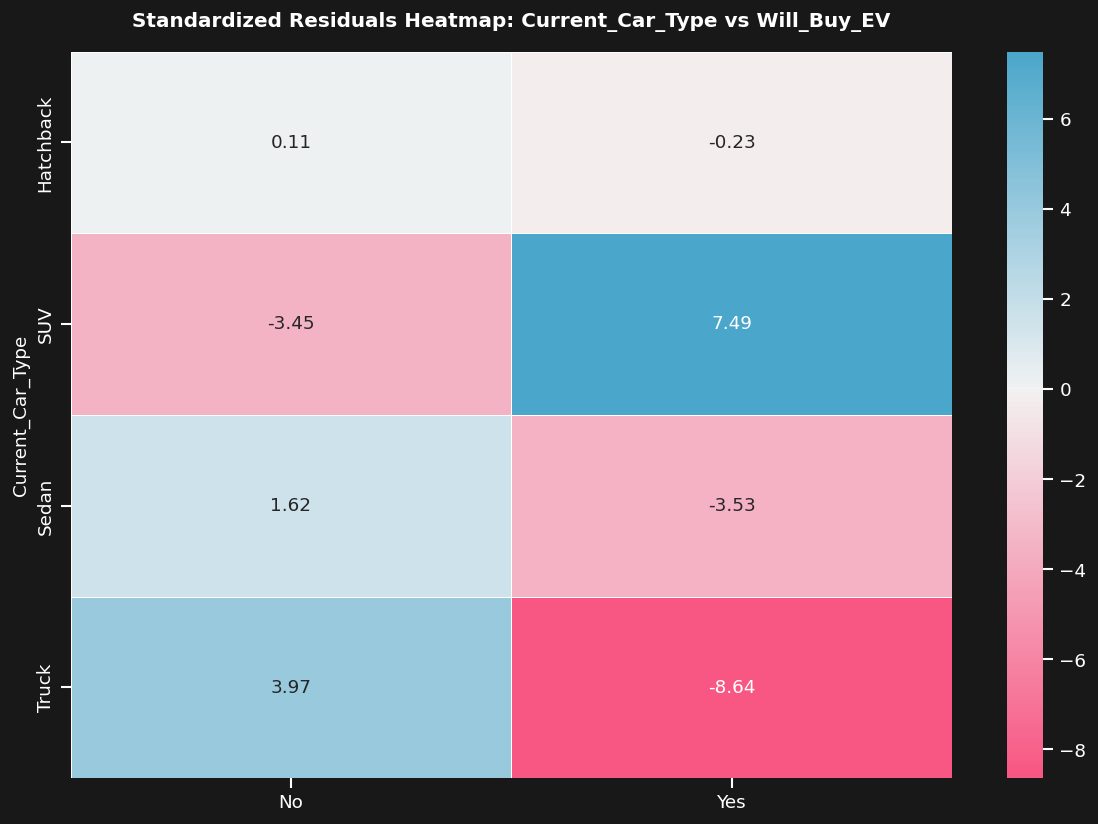

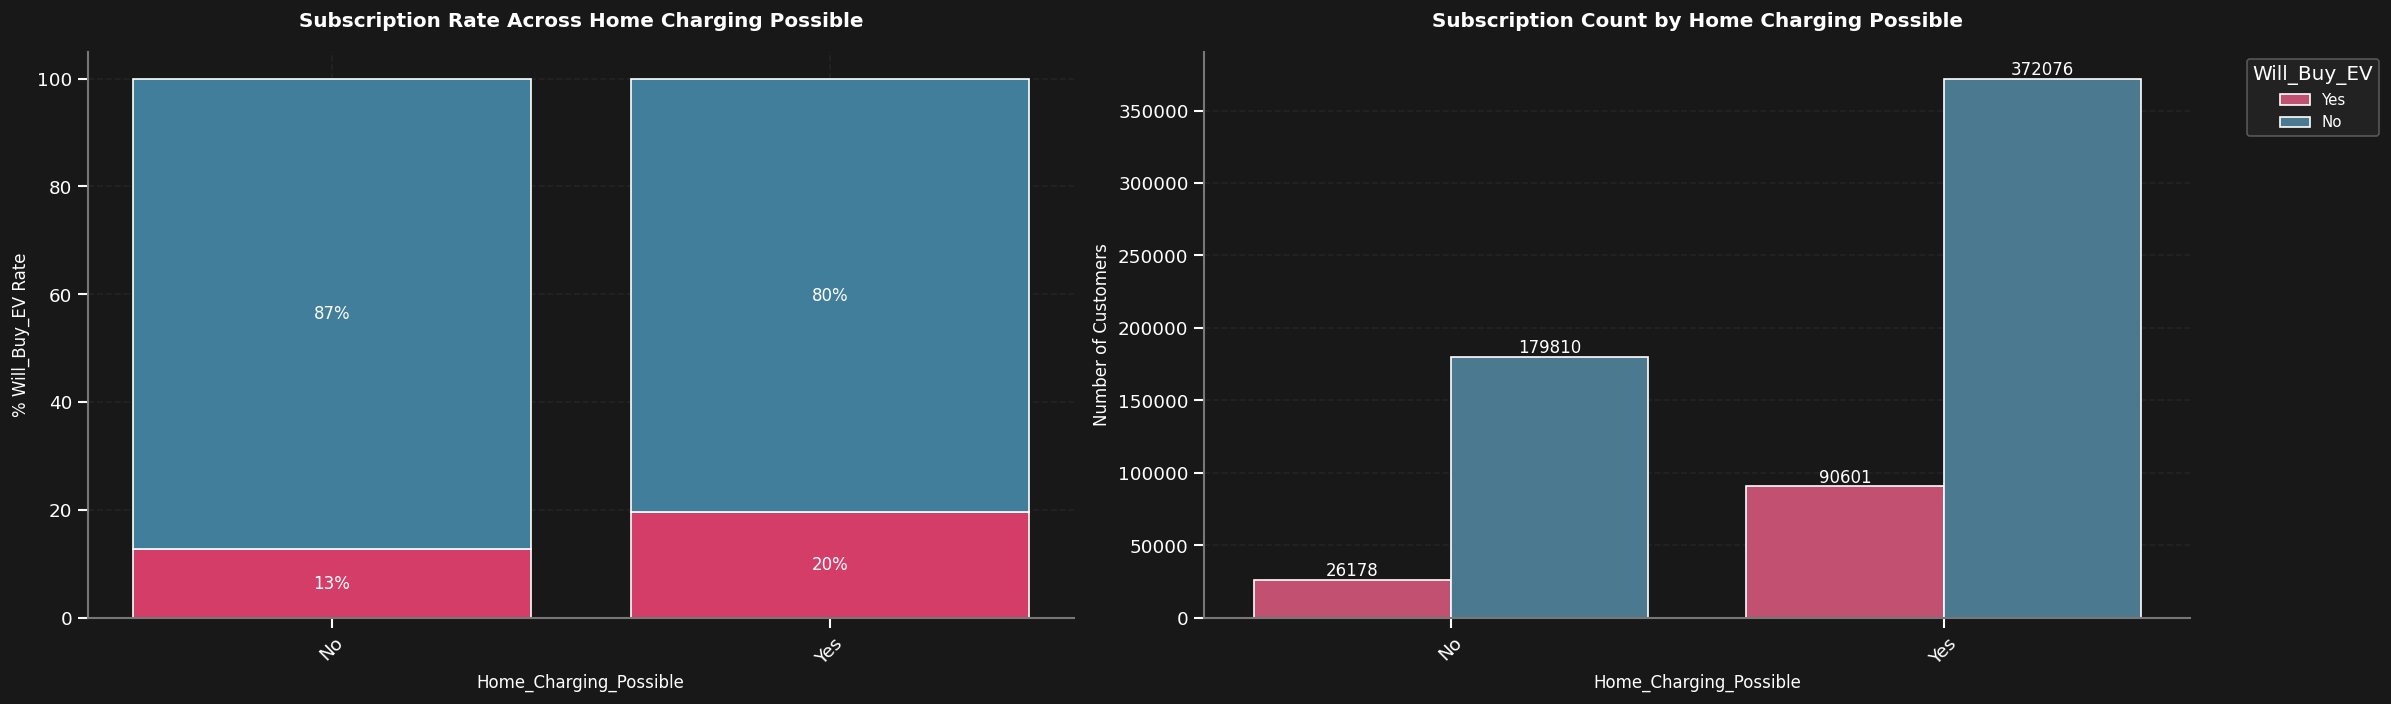

2026-09-19 04:37:58 | INFO     | Chi-Square Test of Independence: 'Home_Charging_Possible' vs. 'Will_Buy_EV'...
2026-09-19 04:37:58 | INFO     | Chi-squared statistic: 4671.041
2026-09-19 04:37:58 | INFO     | Degrees of freedom: 1
2026-09-19 04:37:58 | INFO     | p-value: 0.000000
2026-09-19 04:37:58 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:37:58 | INFO     | Variables 'Home_Charging_Possible' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:37:58 | DEBUG    | Displaying standardized residuals heatmap.


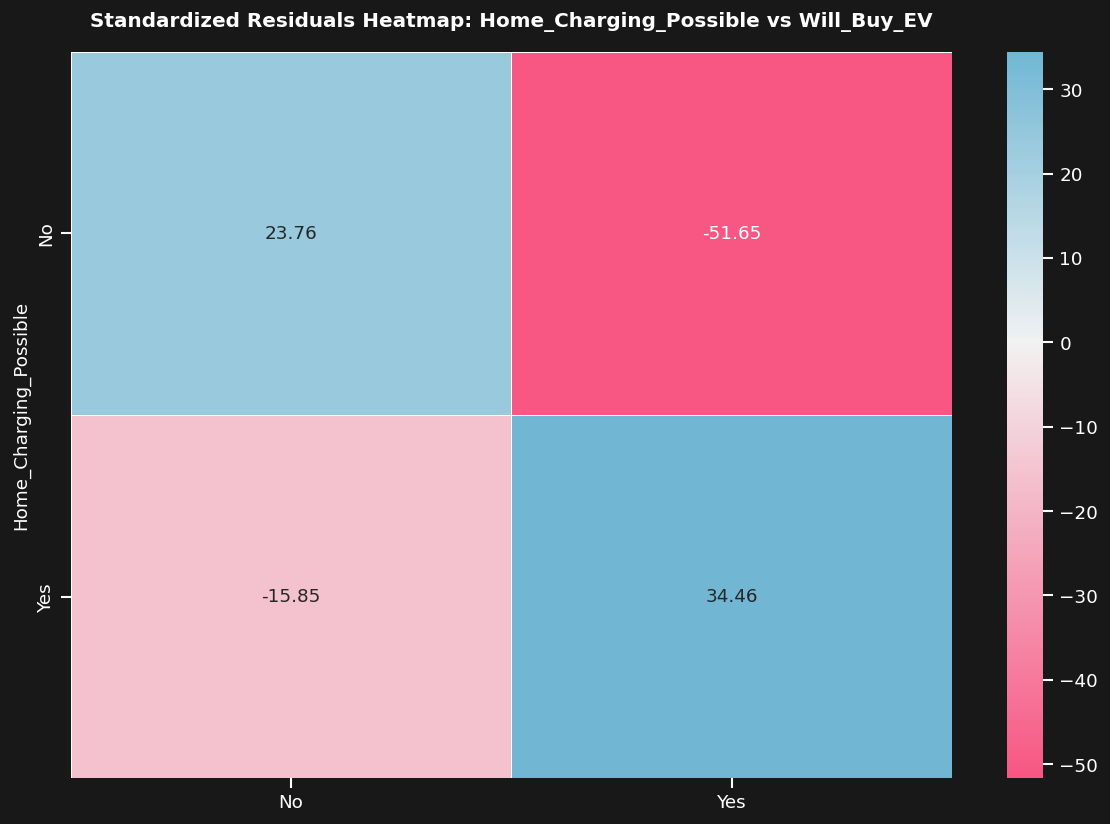

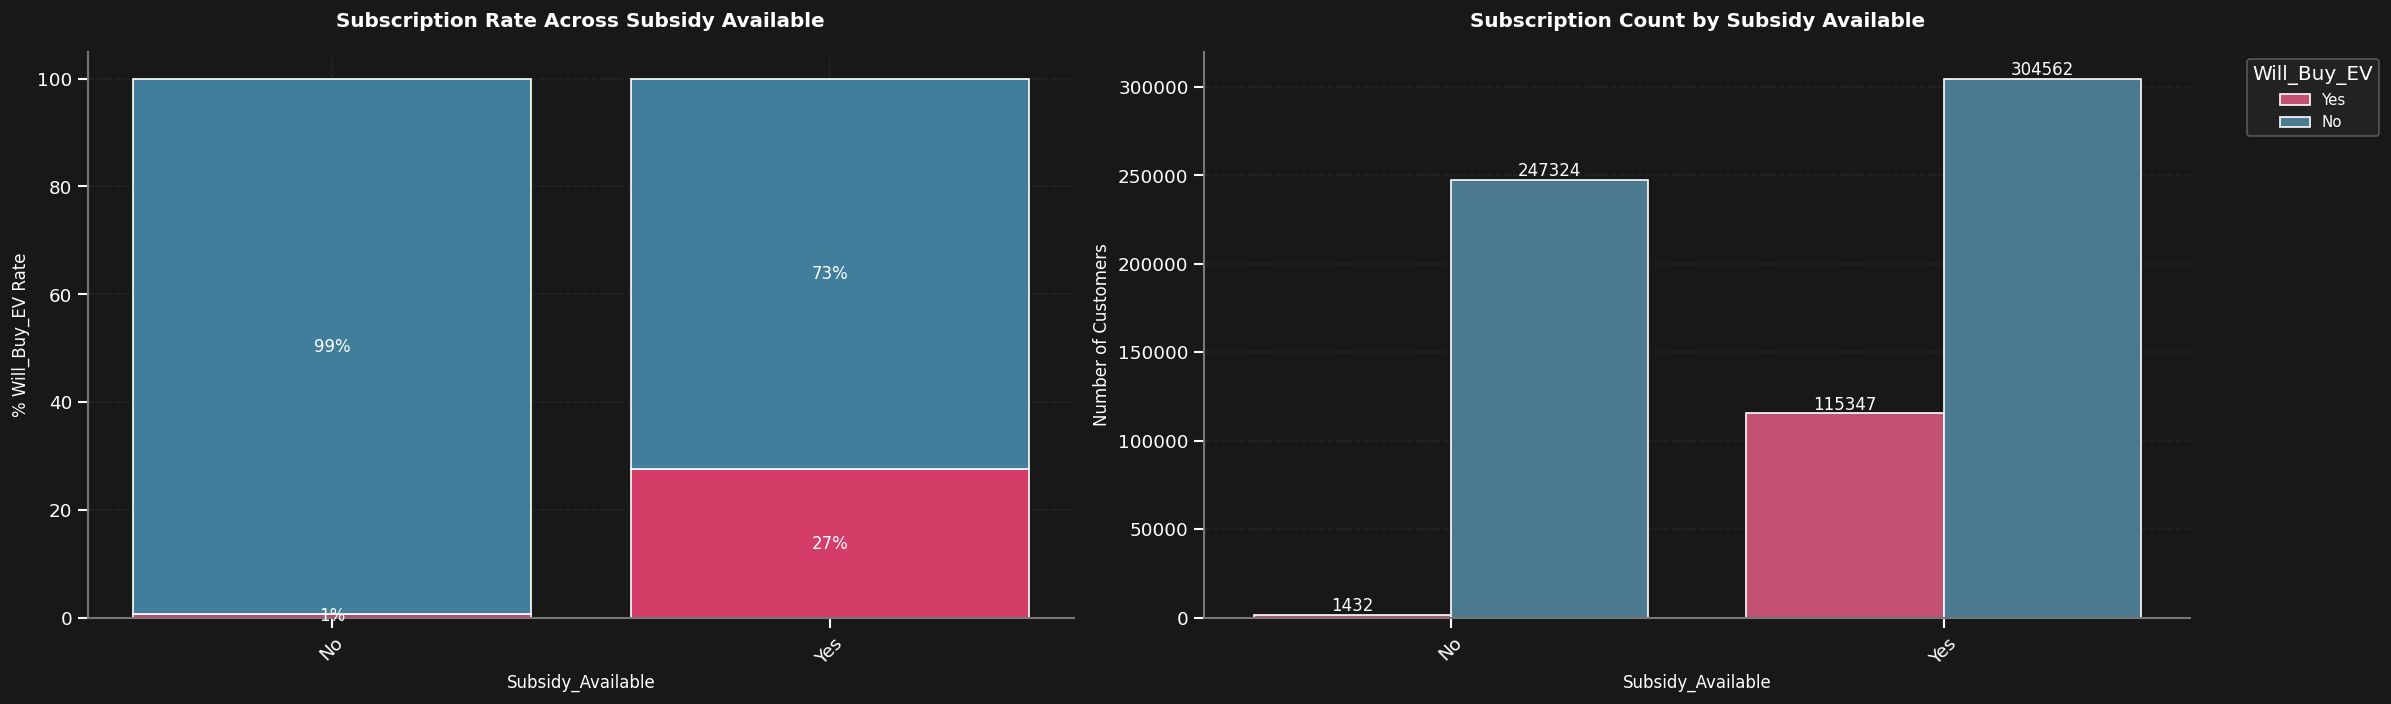

2026-09-19 04:37:59 | INFO     | Chi-Square Test of Independence: 'Subsidy_Available' vs. 'Will_Buy_EV'...
2026-09-19 04:37:59 | INFO     | Chi-squared statistic: 78382.500
2026-09-19 04:37:59 | INFO     | Degrees of freedom: 1
2026-09-19 04:37:59 | INFO     | p-value: 0.000000
2026-09-19 04:37:59 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:37:59 | INFO     | Variables 'Subsidy_Available' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:37:59 | DEBUG    | Displaying standardized residuals heatmap.


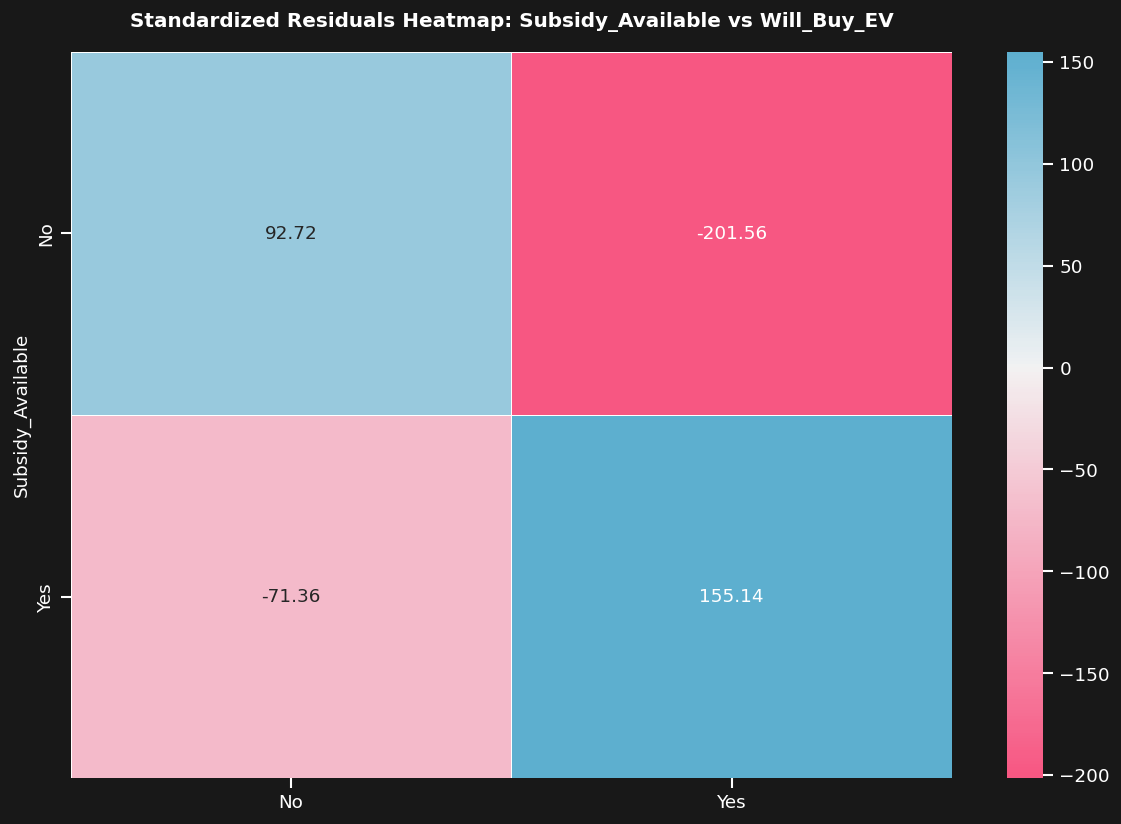

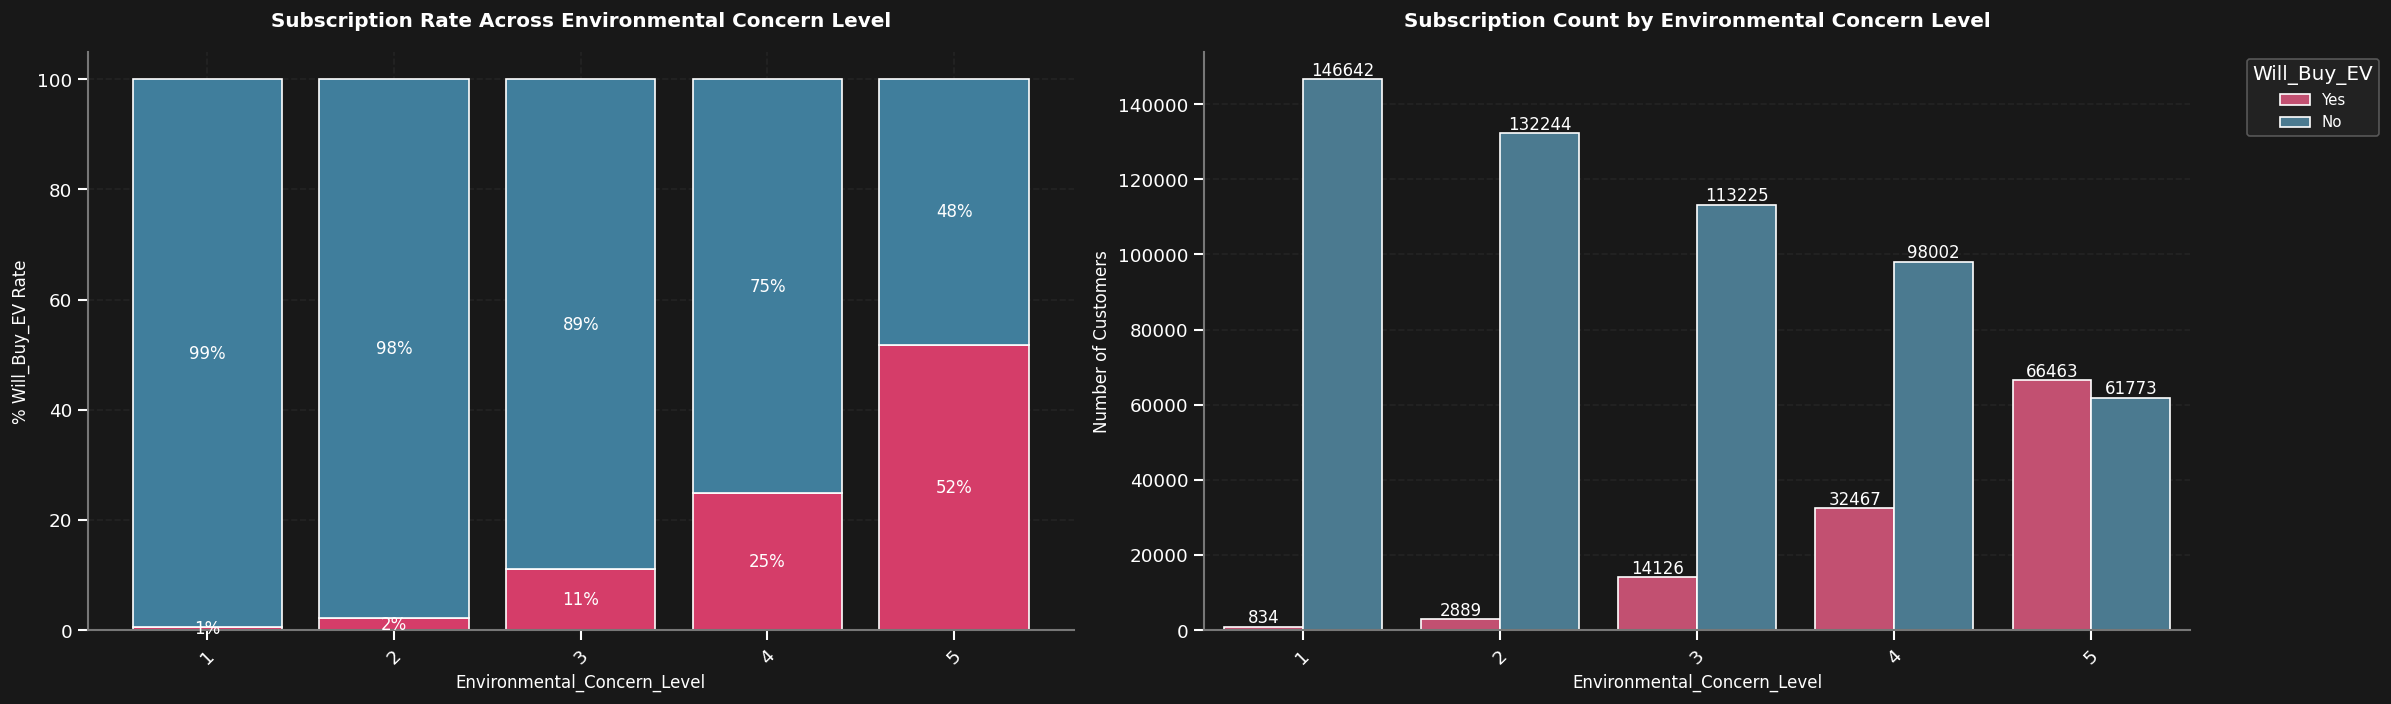

2026-09-19 04:38:01 | INFO     | Chi-Square Test of Independence: 'Environmental_Concern_Level' vs. 'Will_Buy_EV'...
2026-09-19 04:38:01 | INFO     | Chi-squared statistic: 164867.872
2026-09-19 04:38:01 | INFO     | Degrees of freedom: 4
2026-09-19 04:38:01 | INFO     | p-value: 0.000000
2026-09-19 04:38:01 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:38:01 | INFO     | Variables 'Environmental_Concern_Level' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:38:01 | DEBUG    | Displaying standardized residuals heatmap.


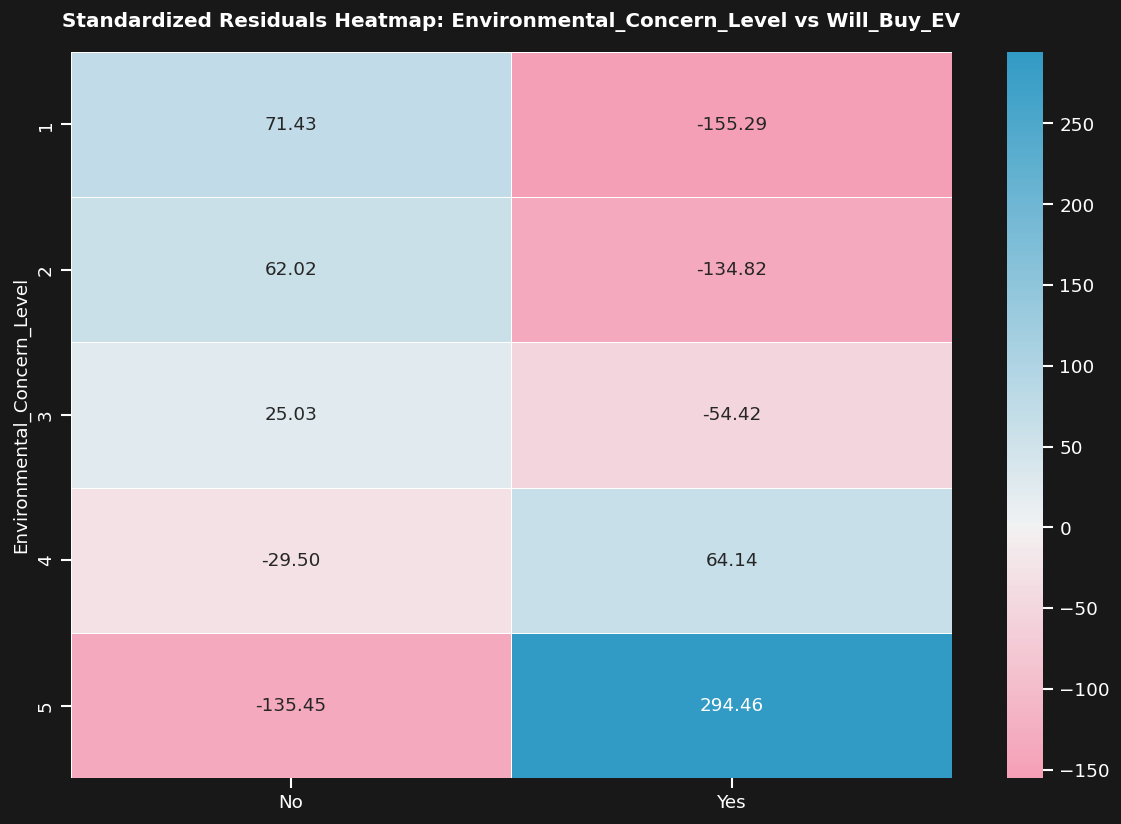

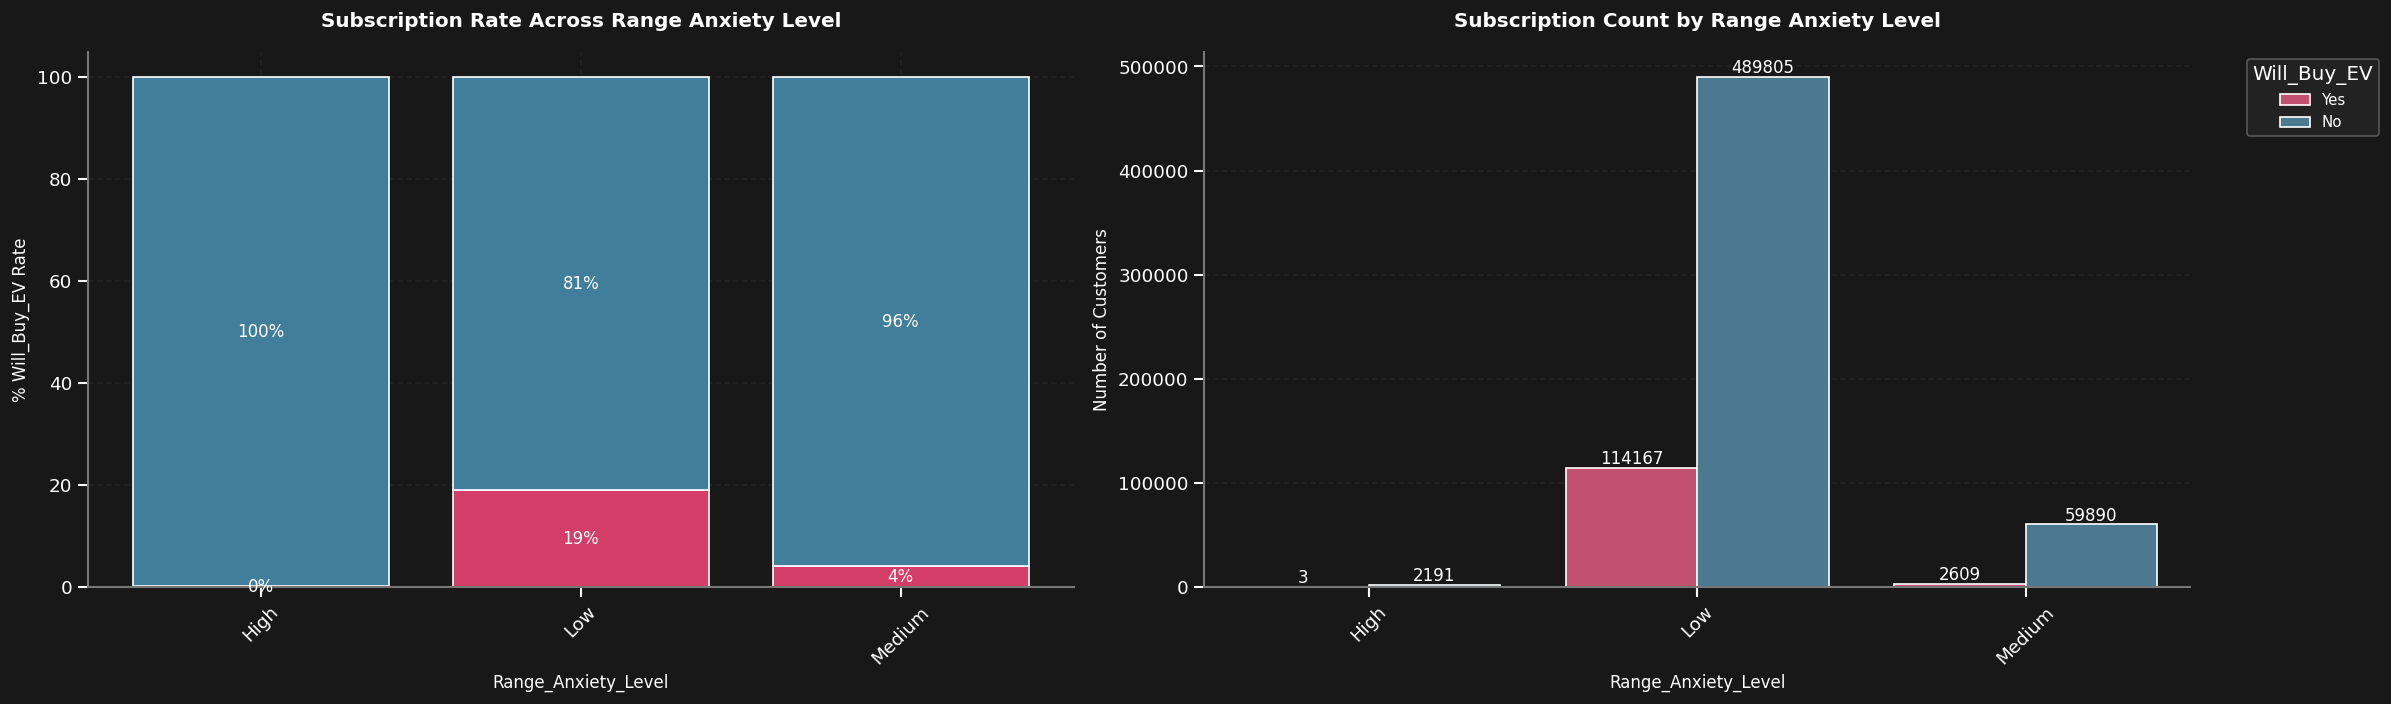

2026-09-19 04:38:02 | INFO     | Chi-Square Test of Independence: 'Range_Anxiety_Level' vs. 'Will_Buy_EV'...
2026-09-19 04:38:02 | INFO     | Chi-squared statistic: 8981.913
2026-09-19 04:38:02 | INFO     | Degrees of freedom: 2
2026-09-19 04:38:02 | INFO     | p-value: 0.000000
2026-09-19 04:38:02 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:38:02 | INFO     | Variables 'Range_Anxiety_Level' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:38:02 | DEBUG    | Displaying standardized residuals heatmap.


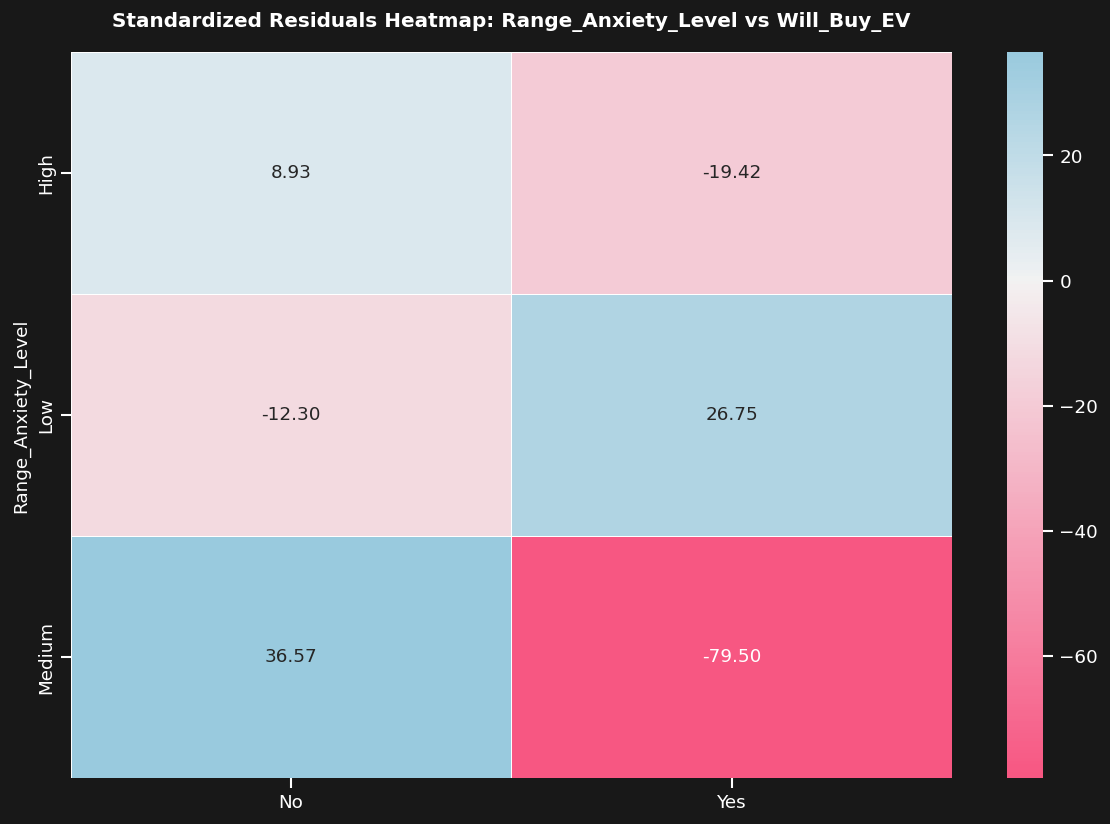

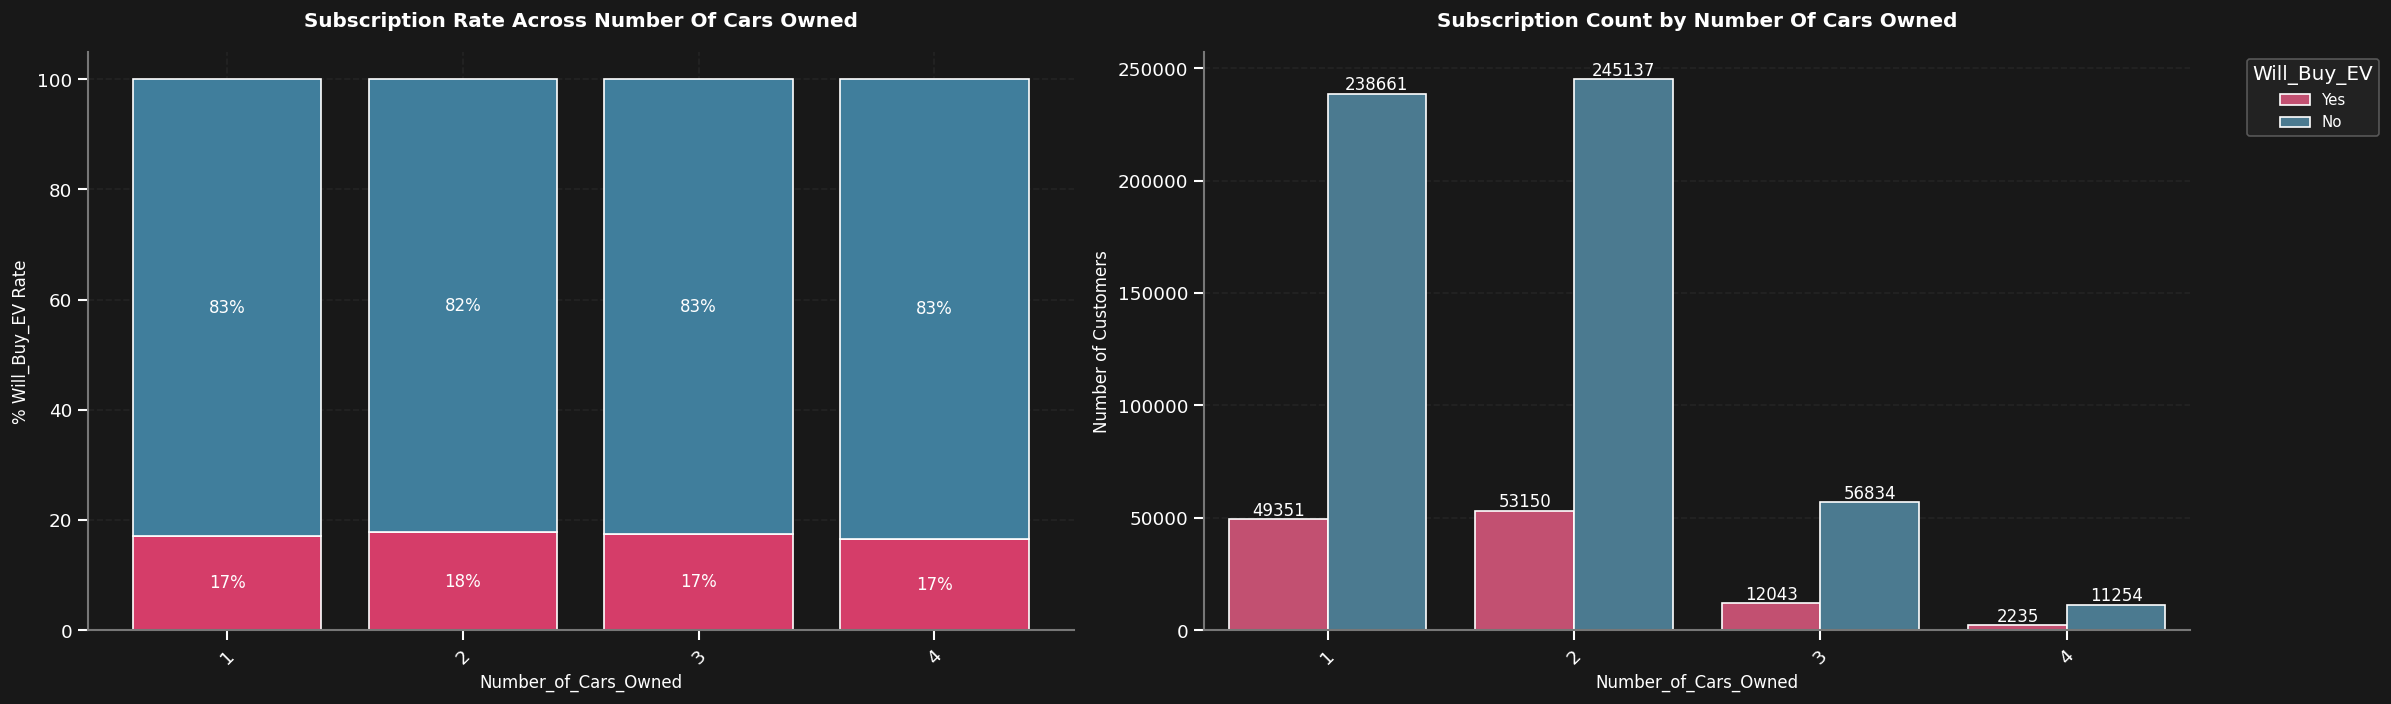

2026-09-19 04:38:04 | INFO     | Chi-Square Test of Independence: 'Number_of_Cars_Owned' vs. 'Will_Buy_EV'...
2026-09-19 04:38:04 | INFO     | Chi-squared statistic: 55.129
2026-09-19 04:38:04 | INFO     | Degrees of freedom: 3
2026-09-19 04:38:04 | INFO     | p-value: 0.000000
2026-09-19 04:38:04 | INFO     | Result: p-value < 0.05 → Reject H₀
2026-09-19 04:38:04 | INFO     | Variables 'Number_of_Cars_Owned' and 'Will_Buy_EV' are statistically associated.
2026-09-19 04:38:04 | DEBUG    | Displaying standardized residuals heatmap.


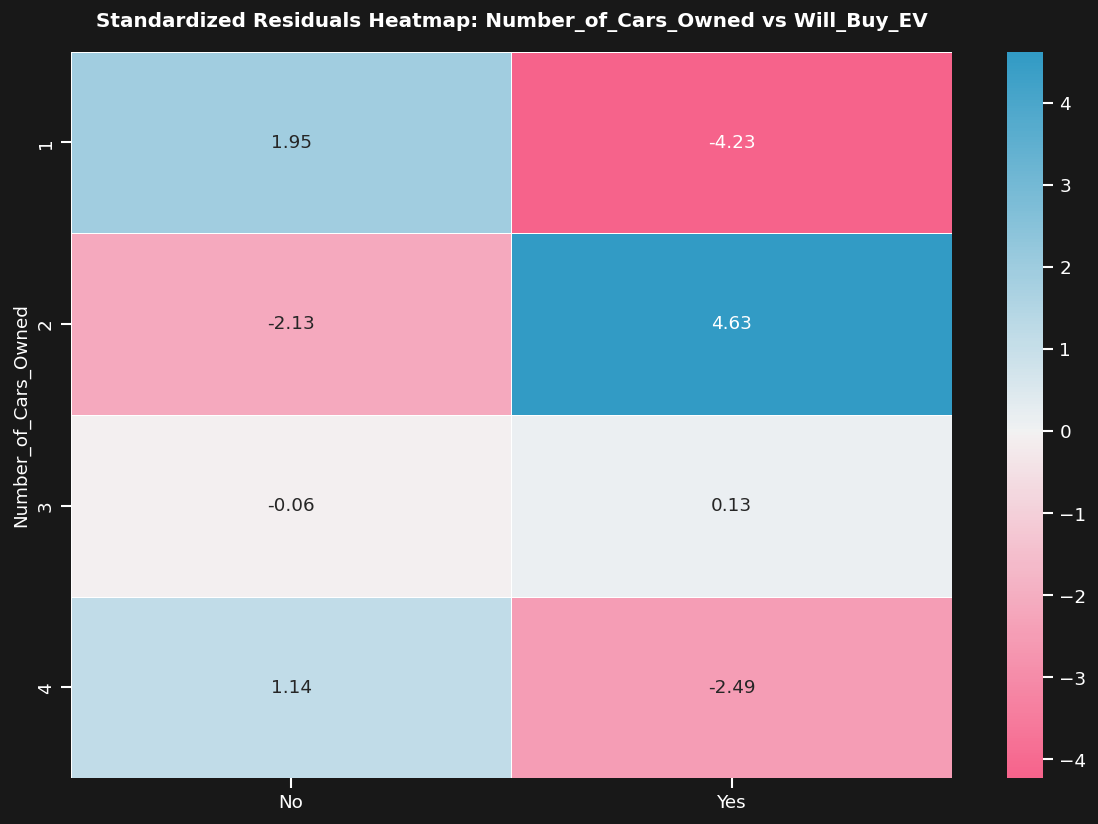

In [19]:
# Categorical Feature Analysis by Target
for feature in cat_features:
    # Display a title for the current feature.
    display(HTML(
        f"<h2 style='text-align:center; font-size:22px; color:#fde68a;'>"
        f"<b>Distribution of {feature.title()} by EV Purchase Decision</b>"
        f"</h2>"
    ))

    # Analyze the categorical feature across target classes.
    StatUtils.analyze_categorical_feature_vs_target(
        cat=feature,
        target_feature=config["target"]["feature"],
        logger=logger,
        df=df_plot
    )

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#fde68a;
    margin:0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
📊 Categorical Features by EV Purchase Decision
</div>

<ul style="line-height:1.8; padding-left:20px;">

<li><b>Gender:</b> Significantly associated with EV purchase decisions (χ² = 33.04, p &lt; 0.001); <b>Female</b> shows higher-than-expected purchases, while <b>Male</b> is lower than expected.</li>

<li><b>City_Type:</b> Significantly associated with EV purchase decisions (χ² = 742.83, p &lt; 0.001); <b>Rural and Suburban</b> show higher-than-expected purchases, while <b>Urban</b> is substantially lower than expected.</li>

<li><b>Current_Car_Type:</b> Significantly associated with EV purchase decisions (χ² = 173.66, p &lt; 0.001); <b>SUV</b> shows higher-than-expected purchases, while <b>Truck</b> is substantially lower than expected.</li>

<li><b>Home_Charging_Possible:</b> Strongly differentiated across purchase decisions (χ² = 4671.04, p &lt; 0.001); EV purchase rate increases from approximately <b>13% to 20%</b> when home charging is available.</li>

<li><b>Subsidy_Available:</b> Shows a pronounced relationship with EV purchase decisions (χ² = 78,382.5, p &lt; 0.001); purchase rate rises sharply from approximately <b>1% without a subsidy to 27% with a subsidy</b>.</li>

<li><b>Environmental_Concern_Level:</b> Shows a pronounced relationship with EV purchase decisions (χ² = 164,867.87, p &lt; 0.001); purchase rate increases sharply from approximately <b>1% at level 1 to 52% at level 5</b>, indicating a strong positive adoption pattern.</li>

<li><b>Range_Anxiety_Level:</b> Significantly associated with EV purchase decisions (χ² = 8,981.91, p &lt; 0.001); purchase rate is highest for <b>Low</b> anxiety (~19%) and falls sharply for <b>Medium (~4%)</b> and <b>High (~0%)</b>.</li>

<li><b>Number_of_Cars_Owned:</b> Significantly associated with EV purchase decisions (χ² = 55.13, p &lt; 0.001); consumers owning <b>2 cars</b> show higher-than-expected purchases, while <b>1 and 4 cars</b> are lower than expected.</li>

<li><b>Overall:</b> Among the categorical variables, <code>Subsidy_Available</code>, <code>Environmental_Concern_Level</code>, <code>Home_Charging_Possible</code>, and <code>Range_Anxiety_Level</code> show the most pronounced differences in EV purchase rates across groups.</li>

</ul>

</div>

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Overall Picture</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
        background: linear-gradient(
    135deg, 
    #003B5C, 
    #0077B6 35%, 
    #00B4D8 65%, 
    #2A9D8F 100%
);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Overall Picture
    </h1>
</div>


<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
🚗 Overall Picture
</div>

<table style="
    width:100%;
    border-collapse:collapse;
    background-color:rgba(255,255,255,0.04);
    font-size:14px;
">

<tr style="background-color:rgba(249,231,159,0.15);">
    <th style="padding:12px;border:1px solid #5d8a72;text-align:left;">Feature</th>
    <th style="padding:12px;border:1px solid #5d8a72;text-align:left;">Key Insight</th>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Age</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Statistically different between buyers and non-buyers, but the effect is negligible; age has <b>limited practical impact</b> on EV purchase decisions.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Annual Income</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
EV buyers have substantially higher income, with a <b>large effect size</b>; income is an <b>important factor</b> in EV purchase decisions.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">Daily Commute</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Non-buyers commute slightly farther on average, but the effect is small, indicating <b>limited practical impact</b>.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b>Charging Stations Near Home</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Statistically different across groups, but the effect is negligible, suggesting <b>limited practical impact</b> on EV adoption.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b>Charging Stations Near Work</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Also statistically significant but with a negligible effect, indicating <b>limited practical impact</b>.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;"><b>Gender</b></td>
<td style="padding:10px;border:1px solid #5d8a72;">
Gender is significantly associated with EV purchase decisions, with <b>Female</b> purchases higher than expected and <b>Male</b> purchases lower than expected.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">City Type</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
EV purchase patterns differ by residential area, with <b>Rural and Suburban</b> above expected levels and <b>Urban</b> below expected levels.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">Current Car Type</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
SUV owners show higher-than-expected EV purchases, while <b>Truck</b> owners are substantially lower than expected.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Home Charging Possible</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
EV purchase rates increase from approximately <b>13% to 20%</b> when home charging is possible, highlighting an <b>important adoption factor</b>.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Subsidy Available</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Purchase rates rise sharply from approximately <b>1% to 27%</b> when subsidies are available, indicating a <b>major adoption driver</b>.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Environmental Concern</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
EV purchase rates increase from approximately <b>1% at level 1 to 52% at level 5</b>, showing a <b>strong positive adoption pattern</b>.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Range Anxiety</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Purchase rates are highest for <b>Low</b> anxiety (~19%) and fall sharply for <b>Medium (~4%)</b> and <b>High (~0%)</b>, highlighting range anxiety as a <b>major adoption barrier</b>.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b>Number of Cars Owned</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Ownership is significantly associated with EV adoption, with the <b>2-car group</b> above expected levels, while the overall differences are relatively modest.
</td>
</tr>

</table>

<div style="
    margin-top:18px;
    padding:12px 15px;
    background-color:rgba(0,0,0,0.15);
    border-radius:8px;
    font-size:13px;
">
<span style="color:#ff6b6b;"><b>● Strong practical relationship</b></span>
&nbsp;&nbsp;|&nbsp;&nbsp;
<span style="color:#f9e79f;"><b>● Moderate / noticeable relationship</b></span>
&nbsp;&nbsp;|&nbsp;&nbsp;
<span style="color:#ecf0f1;"><b>● Limited practical impact</b></span>
</div>

</div>

In [20]:
logger.info("=" * 80)
logger.info("DATA PREPROCESSING")
logger.info("=" * 80)

# Prepare Base Features
logger.info("Preparing base features...")
BASE = [
    c for c in df_train.columns
    if c not in [config["columns"]["train_test"], config["target"]["feature"], config["columns"]["original"]]
]

logger.info(
    f"Data loaded | "
    f"Train: {df_train.shape} | "
    f"Test: {df_test.shape} | "
    f"Original: {df_original.shape}"
)

logger.info(f"Base features: {len(BASE)}")
logger.debug(f"Base feature list: {BASE}")

# Combine Train + Original Dataset
logger.info("Combining train and original datasets...")

train_before = len(df_train)

df_train = pd.concat([df_train, df_original], ignore_index=True)
logger.info(
    f"Train dataset combined | "
    f"Rows: {train_before:,} -> {len(df_train):,}"
)

# Feature Engineering
logger.info("Starting feature engineering...")

for df_name, df in [("Train", df_train), ("Test", df_test)]:
    logger.info(f"[{df_name}] Creating engineered features...")

    # 1. Total Charging Infrastructure
    # Combine the number of charging stations available
    # near home and near work.
    df["Total_Charging_Stations"] = (
        df["Charging_Stations_Near_Home"]
        + df["Charging_Stations_Near_Work"]
    )

    # 2. Charging Station Difference
    # Measure the difference between charging stations
    # near work and near home.
    #
    # Positive value -> more stations near work
    # Negative value -> more stations near home
    # Zero          -> same number near home and work
    df["Charging_Station_Difference"] = (
        df["Charging_Stations_Near_Work"]
        - df["Charging_Stations_Near_Home"]
    )

    # 3. Commute per Charging Station
    # Relate daily commuting distance to the available
    # charging infrastructure.
    #
    # +1 prevents division by zero when there are
    # no charging stations.
    #
    # Higher value:
    #   Longer commute with fewer charging stations.
    #
    # Lower value:
    #   Shorter commute with more charging stations.
    df["Commute_per_Charging_Station"] = (
        df["Daily_Commute_km"]
        / (df["Total_Charging_Stations"] + 1)
    )

    # 4. Range Anxiety Score
    # Convert the ordinal categorical feature
    # Range_Anxiety_Level into an ordered numerical score.
    #
    # Low    -> 1
    # Medium -> 2
    # High   -> 3
    df["Range_Anxiety_Score"] = (
        df["Range_Anxiety_Level"]
        .map({"Low": 1, "Medium": 2, "High": 3}).astype("int8")
    )

    # 5. Range Anxiety × Daily Commute
    # Interaction feature between range anxiety and
    # daily commuting distance.
    df["Range_Anxiety_Commute"] = (
        df["Range_Anxiety_Score"].astype("float32")
        * df["Daily_Commute_km"]
    )

    # 6. Home Charging Score
    # Combine:
    #   - Number of charging stations near home
    #   - Whether home charging is possible
    # If home charging is not possible, the score becomes 0.
    df["Home_Charging_Score"] = (
        df["Charging_Stations_Near_Home"]
        * df["Home_Charging_Possible"].eq("Yes").astype("int8")
    )

# Final Preprocessing Summary
logger.info("=" * 80)
logger.info("DATA PREPROCESSING COMPLETED")
logger.info("=" * 80)

logger.info(
    f"Final dataset shapes | "
    f"Train: {df_train.shape} | "
    f"Test: {df_test.shape}"
)

logger.info(f"Categorical features processed: {len(cat_features)}")

2026-09-19 04:38:04 | INFO     | ================================================================================
2026-09-19 04:38:04 | INFO     | DATA PREPROCESSING
2026-09-19 04:38:04 | INFO     | ================================================================================
2026-09-19 04:38:04 | INFO     | Preparing base features...
2026-09-19 04:38:04 | INFO     | Data loaded | Train: (668665, 14) | Test: (286571, 13) | Original: (10000, 14)
2026-09-19 04:38:04 | INFO     | Base features: 13
2026-09-19 04:38:04 | DEBUG    | Base feature list: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']
2026-09-19 04:38:04 | INFO     | Combining train and original datasets...
2026-09-19 04:38:04 | INFO     | Train dataset combined | Rows: 668,665 -> 678,665
2026-09-1

In [21]:
BASE = num_features + cat_features

new_features = ["Total_Charging_Stations", "Charging_Station_Difference", "Commute_per_Charging_Station",
                "Range_Anxiety_Commute", "Home_Charging_Score"]

FEATURES = BASE + new_features

logger.info(
    f"Feature composition | "
    f"Base: {len(BASE)} | "
    f"Engineered: {len(new_features)} | "
    f"Total: {len(FEATURES)}"
)

logger.debug(f"Final feature list: {FEATURES}")

# Reduce Memory Usage
logger.info("Reducing memory usage...")

df_train = Utils.reduce_mem_usage(cols=FEATURES, df=df_train)
df_test = Utils.reduce_mem_usage(cols=FEATURES, df=df_test)

logger.info(
    f"Memory optimization completed | "
    f"Train: {df_train.shape} | "
    f"Test: {df_test.shape}"
)

# Final Categorical Conversion
# Only original categorical features are converted.
# Missing indicators remain numerical binary features (0/1).
logger.info("Applying categorical conversion to original categorical features...")

# Numerical features
new_num_features = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Total_Charging_Stations",
    "Charging_Station_Difference",
    "Commute_per_Charging_Station",
    "Range_Anxiety_Commute",
    "Home_Charging_Score"
]

# Categorical features
new_cat_features = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Environmental_Concern_Level",
    "Range_Anxiety_Level",
    "Number_of_Cars_Owned"
]

# Handle Missing Values

# Environmental_Concern_Level is an ordinal categorical feature.
# Missing values are kept as a separate category instead of
# imputing them with the most frequent value.
#
# This allows the model to distinguish:
#   1, 2, 3, 4, 5 -> known concern levels
#   Missing        -> unavailable information

for df_name, df in [("Train", df_train), ("Test", df_test)]:
    for feature in new_cat_features:
        if feature in df.columns:
            missing_count = df[feature].isna().sum()

            if missing_count > 0:
                df[feature] = df[feature].astype("string").fillna("Missing")
                logger.info(
                    f"[{df_name}] {feature}: "
                    f"filled {missing_count:,} missing values "
                    f"with 'Missing'"
                )
            else:
                df[feature] = df[feature].astype("string")

TOTAL_FEATURES = new_num_features + new_cat_features

df_train = Utils.convert_cat(features=new_cat_features, df=df_train)
df_test = Utils.convert_cat(features=new_cat_features,  df=df_test)

logger.info("Categorical conversion completed.")

# Final Preprocessing Summary
logger.info("*" * 80)
logger.info("DATA PREPROCESSING COMPLETED")
logger.info("=" * 80)
logger.info(f"Final Train Shape: {df_train.shape}")
logger.info(f"Final Test Shape: {df_test.shape}")
logger.info(f"Total Features: {len(FEATURES)}")
logger.info(f"Categorical Features: {len(cat_features)}")
logger.info("*" * 80)

2026-09-19 04:38:05 | INFO     | Feature composition | Base: 13 | Engineered: 5 | Total: 18
2026-09-19 04:38:05 | DEBUG    | Final feature list: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Environmental_Concern_Level', 'Range_Anxiety_Level', 'Number_of_Cars_Owned', 'Total_Charging_Stations', 'Charging_Station_Difference', 'Commute_per_Charging_Station', 'Range_Anxiety_Commute', 'Home_Charging_Score']
2026-09-19 04:38:05 | INFO     | Reducing memory usage...
2026-09-19 04:38:05 | INFO     | Memory optimization completed | Train: (678665, 20) | Test: (286571, 19)
2026-09-19 04:38:05 | INFO     | Applying categorical conversion to original categorical features...
2026-09-19 04:38:05 | INFO     | [Train] Environmental_Concern_Level: filled 184 missing values with 'Missing'
2026-09-19 04:38:06 | INFO     | Categorical conversion comple

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Modeling</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
        background: linear-gradient(
    135deg, 
    #003B5C, 
    #0077B6 35%, 
    #00B4D8 65%, 
    #2A9D8F 100%
);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Modeling
    </h1>
</div>

## CatBoostClassifier

2026-09-19 04:38:06 | INFO     | X Shape: (678665, 18)
2026-09-19 04:38:06 | INFO     | y Shape: (678665,)
2026-09-19 04:38:06 | INFO     | --------------------------------------------------------------------------------
2026-09-19 04:38:06 | INFO     | Starting CatBoost hyperparameter tuning
2026-09-19 04:39:32 | DEBUG    | Trial 0 | Fold 1/5 | AUC: 0.94062 | Best iteration: 1617
2026-09-19 04:40:57 | DEBUG    | Trial 0 | Fold 2/5 | AUC: 0.93970 | Best iteration: 1657
2026-09-19 04:42:22 | DEBUG    | Trial 0 | Fold 3/5 | AUC: 0.93985 | Best iteration: 1657
2026-09-19 04:43:47 | DEBUG    | Trial 0 | Fold 4/5 | AUC: 0.93999 | Best iteration: 1657
2026-09-19 04:45:12 | DEBUG    | Trial 0 | Fold 5/5 | AUC: 0.93838 | Best iteration: 1656
2026-09-19 04:45:12 | INFO     | Trial 0 finished | Mean AUC: 0.93971 | Std: 0.00073
2026-09-19 04:47:17 | DEBUG    | Trial 1 | Fold 1/5 | AUC: 0.94062 | Best iteration: 1468
2026-09-19 04:49:22 | DEBUG    | Trial 1 | Fold 2/5 | AUC: 0.93978 | Best iterati

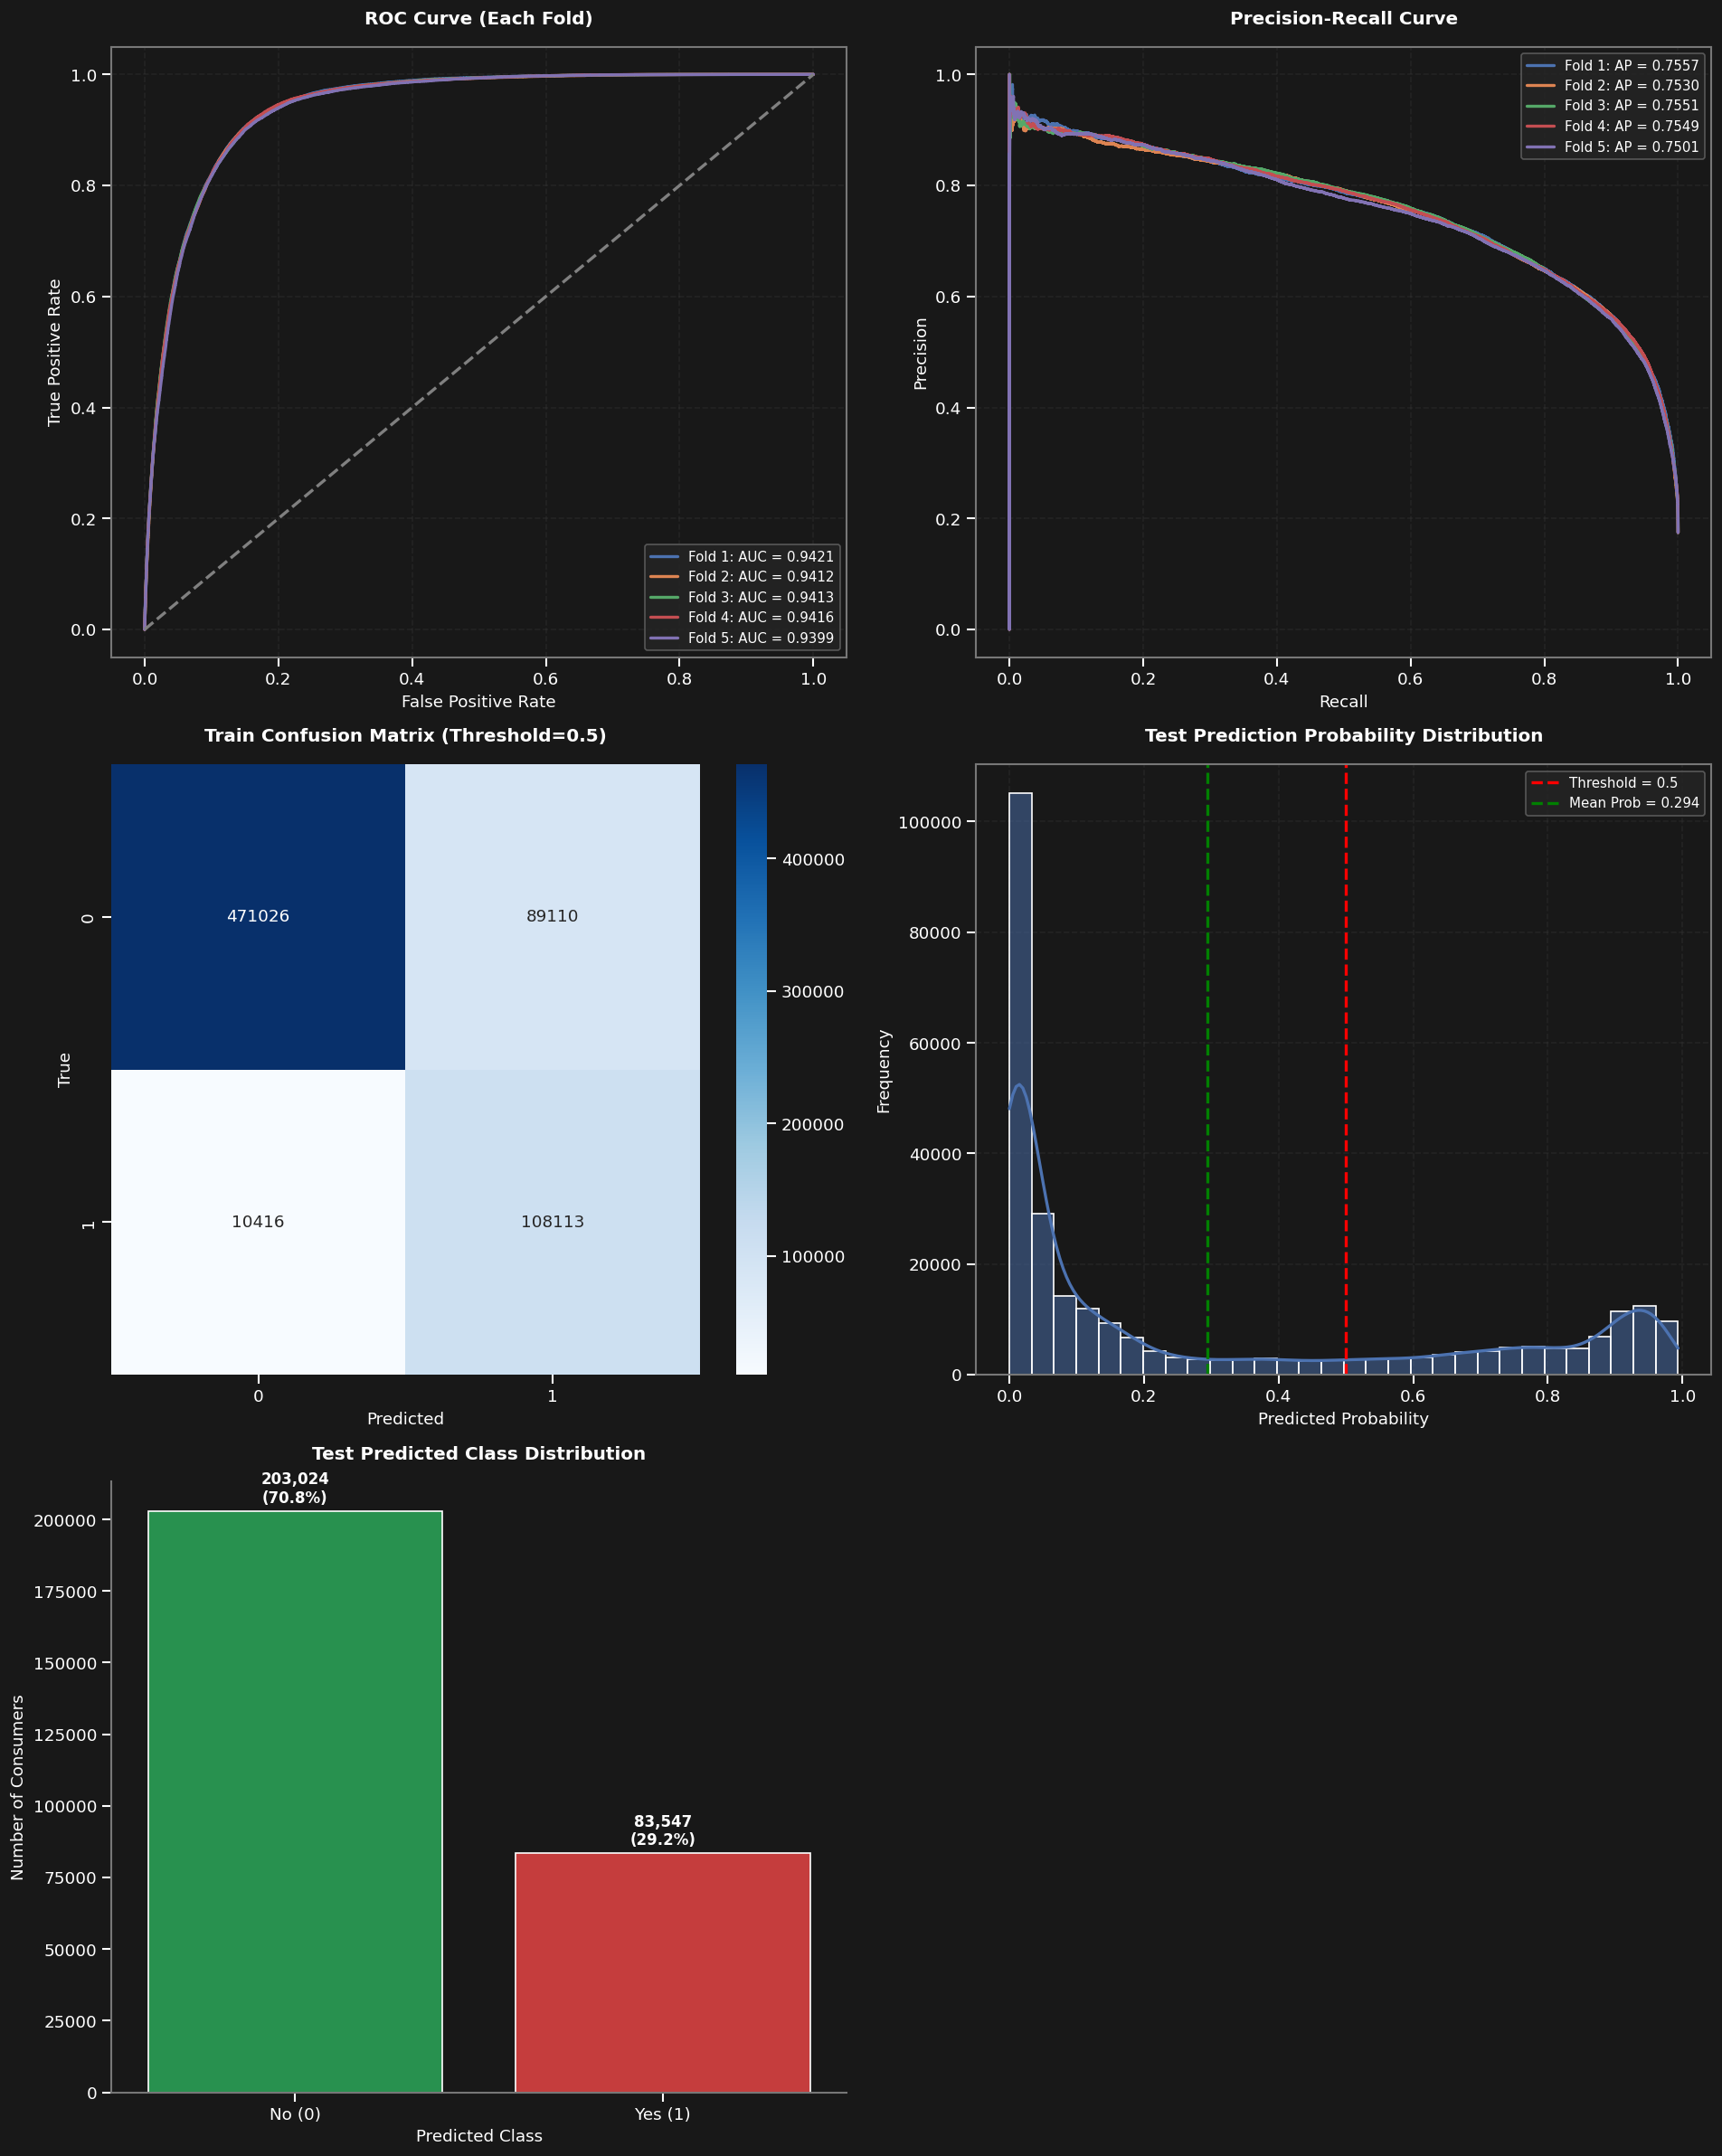

2026-09-19 08:36:03 | INFO     | CatBoost OOF evaluation completed
2026-09-19 08:36:03 | INFO     | --------------------------------------------------------------------------------


In [22]:
# Training Data
X = df_train[TOTAL_FEATURES]
y = df_train[config["target"]["feature"]]
logger.info(f"X Shape: {X.shape}")
logger.info(f"y Shape: {y.shape}")

logger.info("-" * 80)
logger.info("Starting CatBoost hyperparameter tuning")
study_cb = optuna.create_study(direction="maximize", study_name="catboost_churn_tuning")
study_cb.optimize(
    lambda trial: objective_catboost(
        trial=trial,
        X=X,
        y=y,
        cat_features=new_cat_features,
        logger=logger
    ),
    n_trials=50
)

logger.info("CatBoost hyperparameter tuning completed")
logger.info(f"Best CV AUC: {study_cb.best_value:.5f}")
logger.info(f"Best trial: {study_cb.best_trial.number}")
logger.info(f"Best parameters: {study_cb.best_params}")

logger.info("-" * 80)
logger.info("Initializing CatBoost model with best hyperparameters")

model_cb = CatBoostClassifier(**study_cb.best_params, loss_function="Logloss", auto_class_weights="Balanced", random_seed=config["random_state"],
                              verbose = 0, thread_count=-1, eval_metric="Logloss", allow_writing_files = False, task_type="GPU", devices="0")
logger.info("-" * 80)
logger.info("Starting CatBoost OOF evaluation")
logger.info(
    f"Training samples: {len(X):,} | "
    f"Features: {X.shape[1]} | "
    f"Categorical features: {len(new_cat_features)} | "
    f"CV Folds: {config["cv"]["n_splits"]}"
)

results_cb = run_oof_v2(model=model_cb, X=X, y=y, X_test=df_test[TOTAL_FEATURES],
                         cat_features=new_cat_features, logger=logger)
logger.info("CatBoost OOF evaluation completed")
logger.info("-" * 80)

## XGBClassifier

2026-09-19 08:36:03 | INFO     | --------------------------------------------------------------------------------
2026-09-19 08:36:03 | INFO     | Starting XGBoost hyperparameter tuning
2026-09-19 08:36:03 | DEBUG    | Trial 0 | scale_pos_weight: 4.7257
2026-09-19 08:36:03 | DEBUG    | Trial 0 | Starting Fold 1/5
2026-09-19 08:36:11 | DEBUG    | Trial 0 | Fold 1/5 | AUC: 0.94171 | Best iteration: 420
2026-09-19 08:36:11 | DEBUG    | Trial 0 | Starting Fold 2/5
2026-09-19 08:36:18 | DEBUG    | Trial 0 | Fold 2/5 | AUC: 0.94080 | Best iteration: 369
2026-09-19 08:36:18 | DEBUG    | Trial 0 | Starting Fold 3/5
2026-09-19 08:36:25 | DEBUG    | Trial 0 | Fold 3/5 | AUC: 0.94107 | Best iteration: 437
2026-09-19 08:36:26 | DEBUG    | Trial 0 | Starting Fold 4/5
2026-09-19 08:36:33 | DEBUG    | Trial 0 | Fold 4/5 | AUC: 0.94129 | Best iteration: 451
2026-09-19 08:36:33 | DEBUG    | Trial 0 | Starting Fold 5/5
2026-09-19 08:36:41 | DEBUG    | Trial 0 | Fold 5/5 | AUC: 0.93962 | Best iteration: 

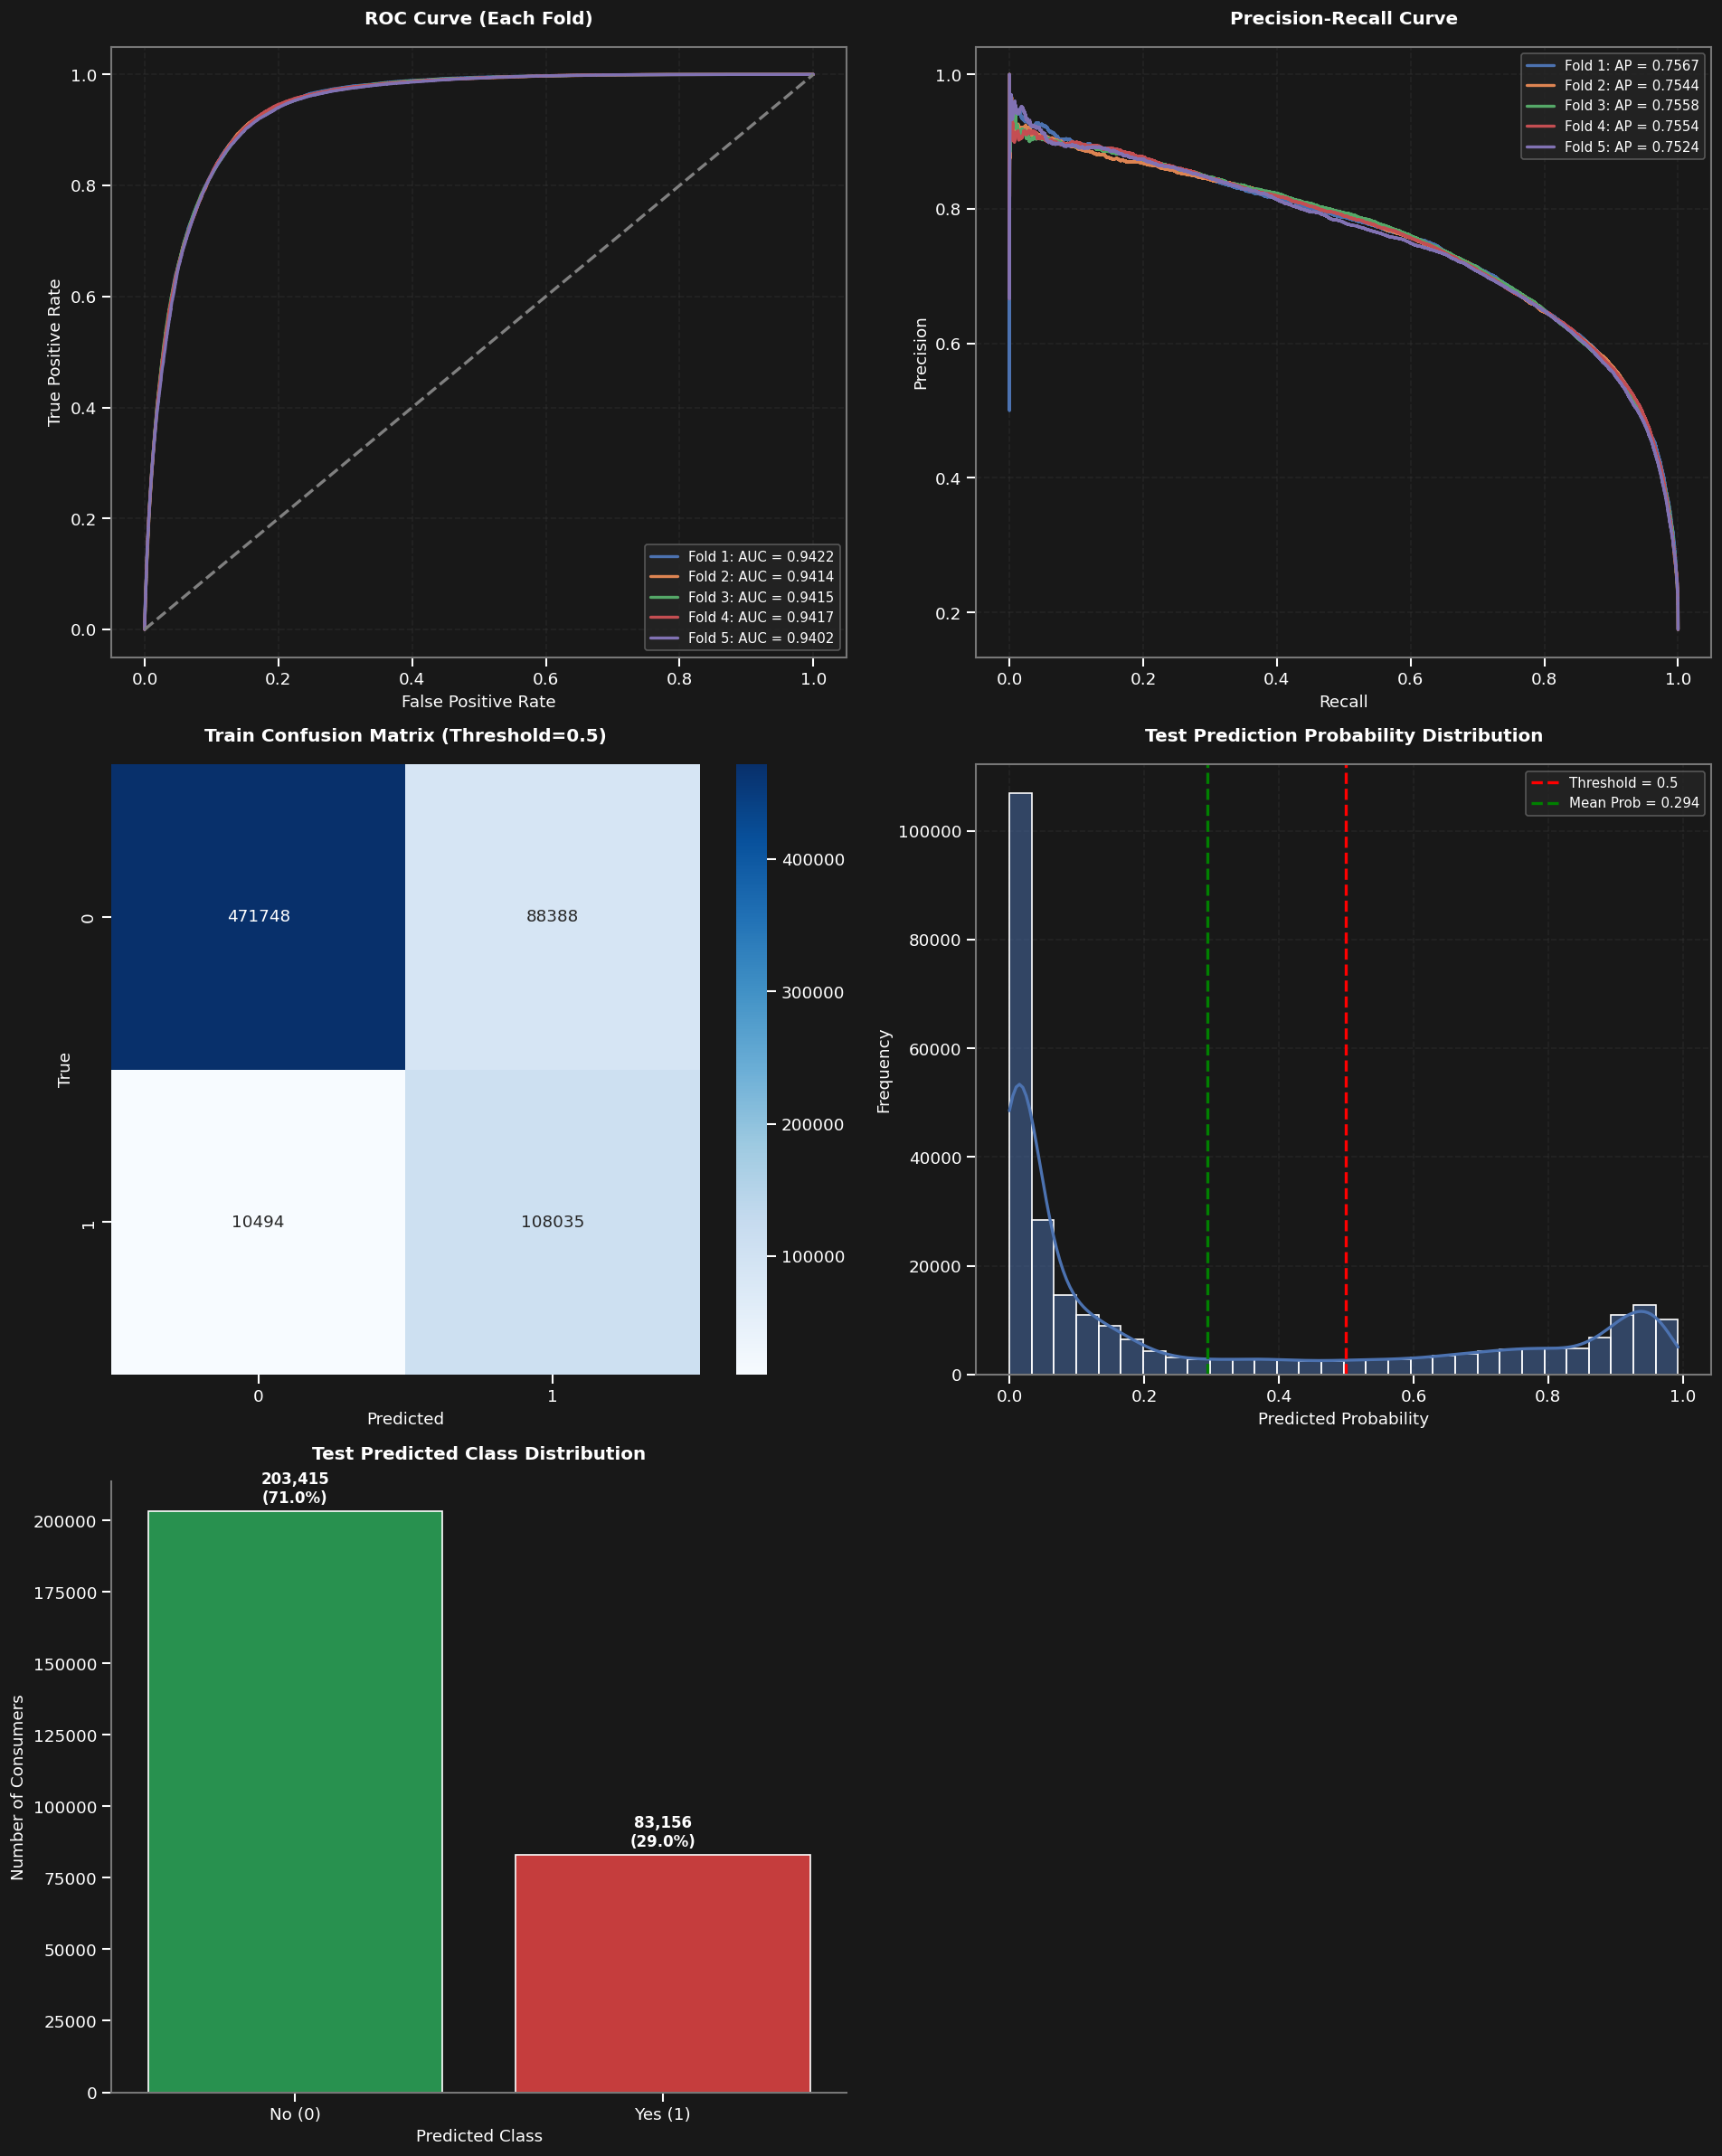

2026-09-19 09:03:42 | INFO     | XGBoost OOF evaluation completed
2026-09-19 09:03:42 | INFO     | --------------------------------------------------------------------------------


In [23]:
logger.info("-" * 80)
logger.info("Starting XGBoost hyperparameter tuning")
study_xgb = optuna.create_study(direction="maximize", study_name="xgboost_churn_tuning")
study_xgb.optimize(
    lambda trial: objective_xgb(
        trial=trial,
        X=X,
        y=y,
        cat_features=new_cat_features,
        logger=logger
    ),
    n_trials=50
)

logger.info("XGBoost hyperparameter tuning completed")
logger.info(f"Best CV AUC: {study_xgb.best_value:.5f}")
logger.info(f"Best trial: {study_xgb.best_trial.number}")
logger.info(f"Best parameters: {study_xgb.best_params}")

logger.info("-" * 80)
logger.info("Initializing XGBoost model with best hyperparameters")

# Calculate class imbalance
n_negative = (y == 0).sum()
n_positive = (y == 1).sum()

if n_positive == 0:
    raise ValueError("Target contains no positive samples.")

scale_pos_weight = n_negative / n_positive

model_xgb = XGBClassifier(**study_xgb.best_params, objective="binary:logistic", metric="auc",
                            verbosity=0, n_jobs=-1, boosting_type="gbdt",
                            class_weight="balanced", random_state=config["random_state"],
                            tree_method="hist", device= "cuda", enable_categorical= True,
                            scale_pos_weight = scale_pos_weight)
logger.info("-" * 80)
logger.info("Starting XGBoost OOF evaluation")
logger.info(
    f"Training samples: {len(X):,} | "
    f"Features: {X.shape[1]} | "
    f"Categorical features: {len(new_cat_features)} | "
    f"CV Folds: {config['cv']['n_splits']}"
)

results_xgb = run_oof_v2(model=model_xgb, X=X, y=y, X_test=df_test[TOTAL_FEATURES],
                         cat_features=new_cat_features, logger=logger)
logger.info("XGBoost OOF evaluation completed")
logger.info("-" * 80)

## LGBMClassifier

2026-09-19 09:03:42 | INFO     | --------------------------------------------------------------------------------
2026-09-19 09:03:42 | INFO     | Starting LightGBM hyperparameter tuning
2026-09-19 09:04:32 | DEBUG    | Trial 0 | Fold 1/5 | AUC: 0.94171 | Best iteration: 864
2026-09-19 09:05:33 | DEBUG    | Trial 0 | Fold 2/5 | AUC: 0.94067 | Best iteration: 1235
2026-09-19 09:06:29 | DEBUG    | Trial 0 | Fold 3/5 | AUC: 0.94098 | Best iteration: 1007
2026-09-19 09:07:31 | DEBUG    | Trial 0 | Fold 4/5 | AUC: 0.94106 | Best iteration: 1230
2026-09-19 09:08:26 | DEBUG    | Trial 0 | Fold 5/5 | AUC: 0.93959 | Best iteration: 993
2026-09-19 09:08:26 | INFO     | Trial 0 finished | Mean AUC: 0.94080 | Std: 0.00070
2026-09-19 09:09:04 | DEBUG    | Trial 1 | Fold 1/5 | AUC: 0.94125 | Best iteration: 707
2026-09-19 09:09:43 | DEBUG    | Trial 1 | Fold 2/5 | AUC: 0.94046 | Best iteration: 692
2026-09-19 09:10:20 | DEBUG    | Trial 1 | Fold 3/5 | AUC: 0.94065 | Best iteration: 705
2026-09-19 09

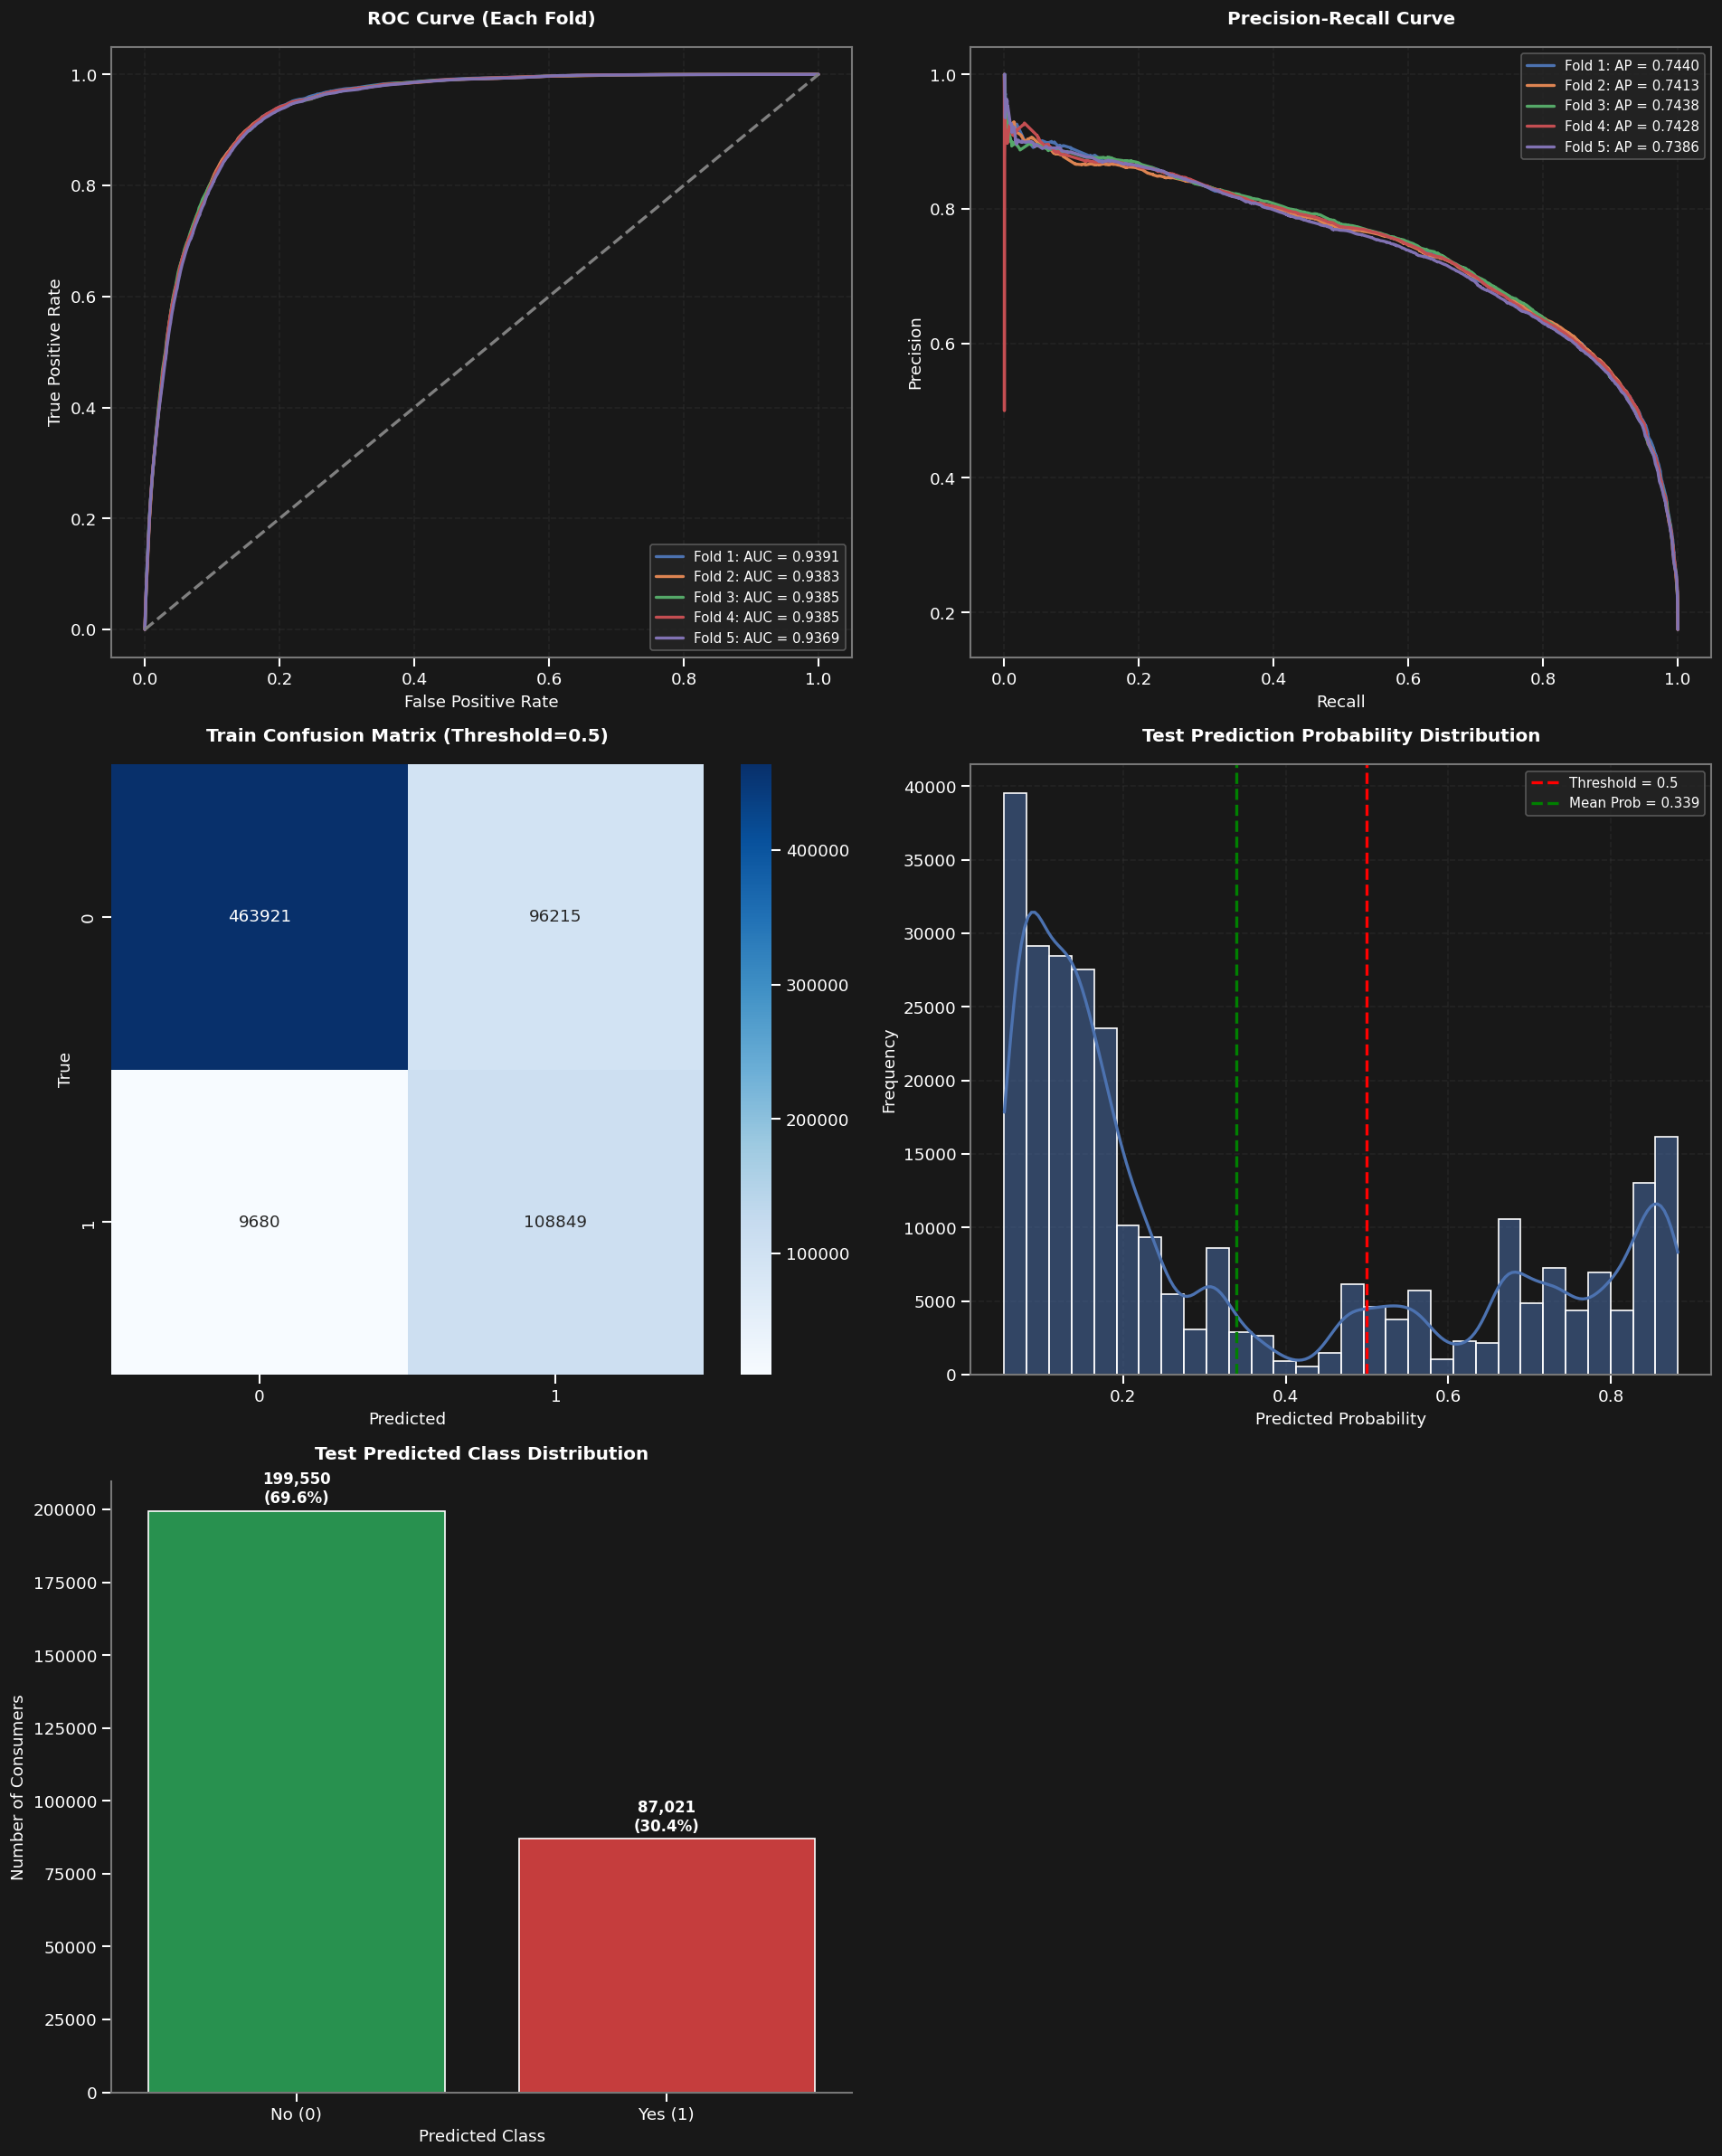

2026-09-19 12:44:47 | INFO     | LightGBM OOF evaluation completed
2026-09-19 12:44:47 | INFO     | --------------------------------------------------------------------------------


In [24]:
logger.info("-" * 80)
logger.info("Starting LightGBM hyperparameter tuning")
study_lgbm = optuna.create_study(direction="maximize", study_name="lightgbm_churn_tuning")
study_lgbm.optimize(
    lambda trial: objective_lgbm(
        trial=trial,
        X=X,
        y=y,
        cat_features=new_cat_features,
        logger=logger
    ),
    n_trials=50
)

logger.info("LightGBM hyperparameter tuning completed")
logger.info(f"Best CV AUC: {study_lgbm.best_value:.5f}")
logger.info(f"Best trial: {study_lgbm.best_trial.number}")
logger.info(f"Best parameters: {study_lgbm.best_params}")

logger.info("-" * 80)
logger.info("Initializing LightGBM model with best hyperparameters")

model_lgbm = lgb.LGBMClassifier(**study_lgbm.best_params, objective="binary", metric="auc",
                                verbosity=-1, n_jobs=-1, boosting_type="gbdt",
                                class_weight="balanced", random_state=config["random_state"])
logger.info("-" * 80)
logger.info("Starting LightGBM OOF evaluation")
logger.info(
    f"Training samples: {len(X):,} | "
    f"Features: {X.shape[1]} | "
    f"Categorical features: {len(new_cat_features)} | "
    f"CV Folds: {config['cv']['n_splits']}"
)

results_lgbm = run_oof_v2(model=model_lgbm, X=X, y=y, X_test=df_test[TOTAL_FEATURES],
                            cat_features=new_cat_features, logger=logger)
logger.info("LightGBM OOF evaluation completed")
logger.info("-" * 80)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Evaluation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
        background: linear-gradient(
    135deg, 
    #003B5C, 
    #0077B6 35%, 
    #00B4D8 65%, 
    #2A9D8F 100%
);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Evaluation
    </h1>
</div>

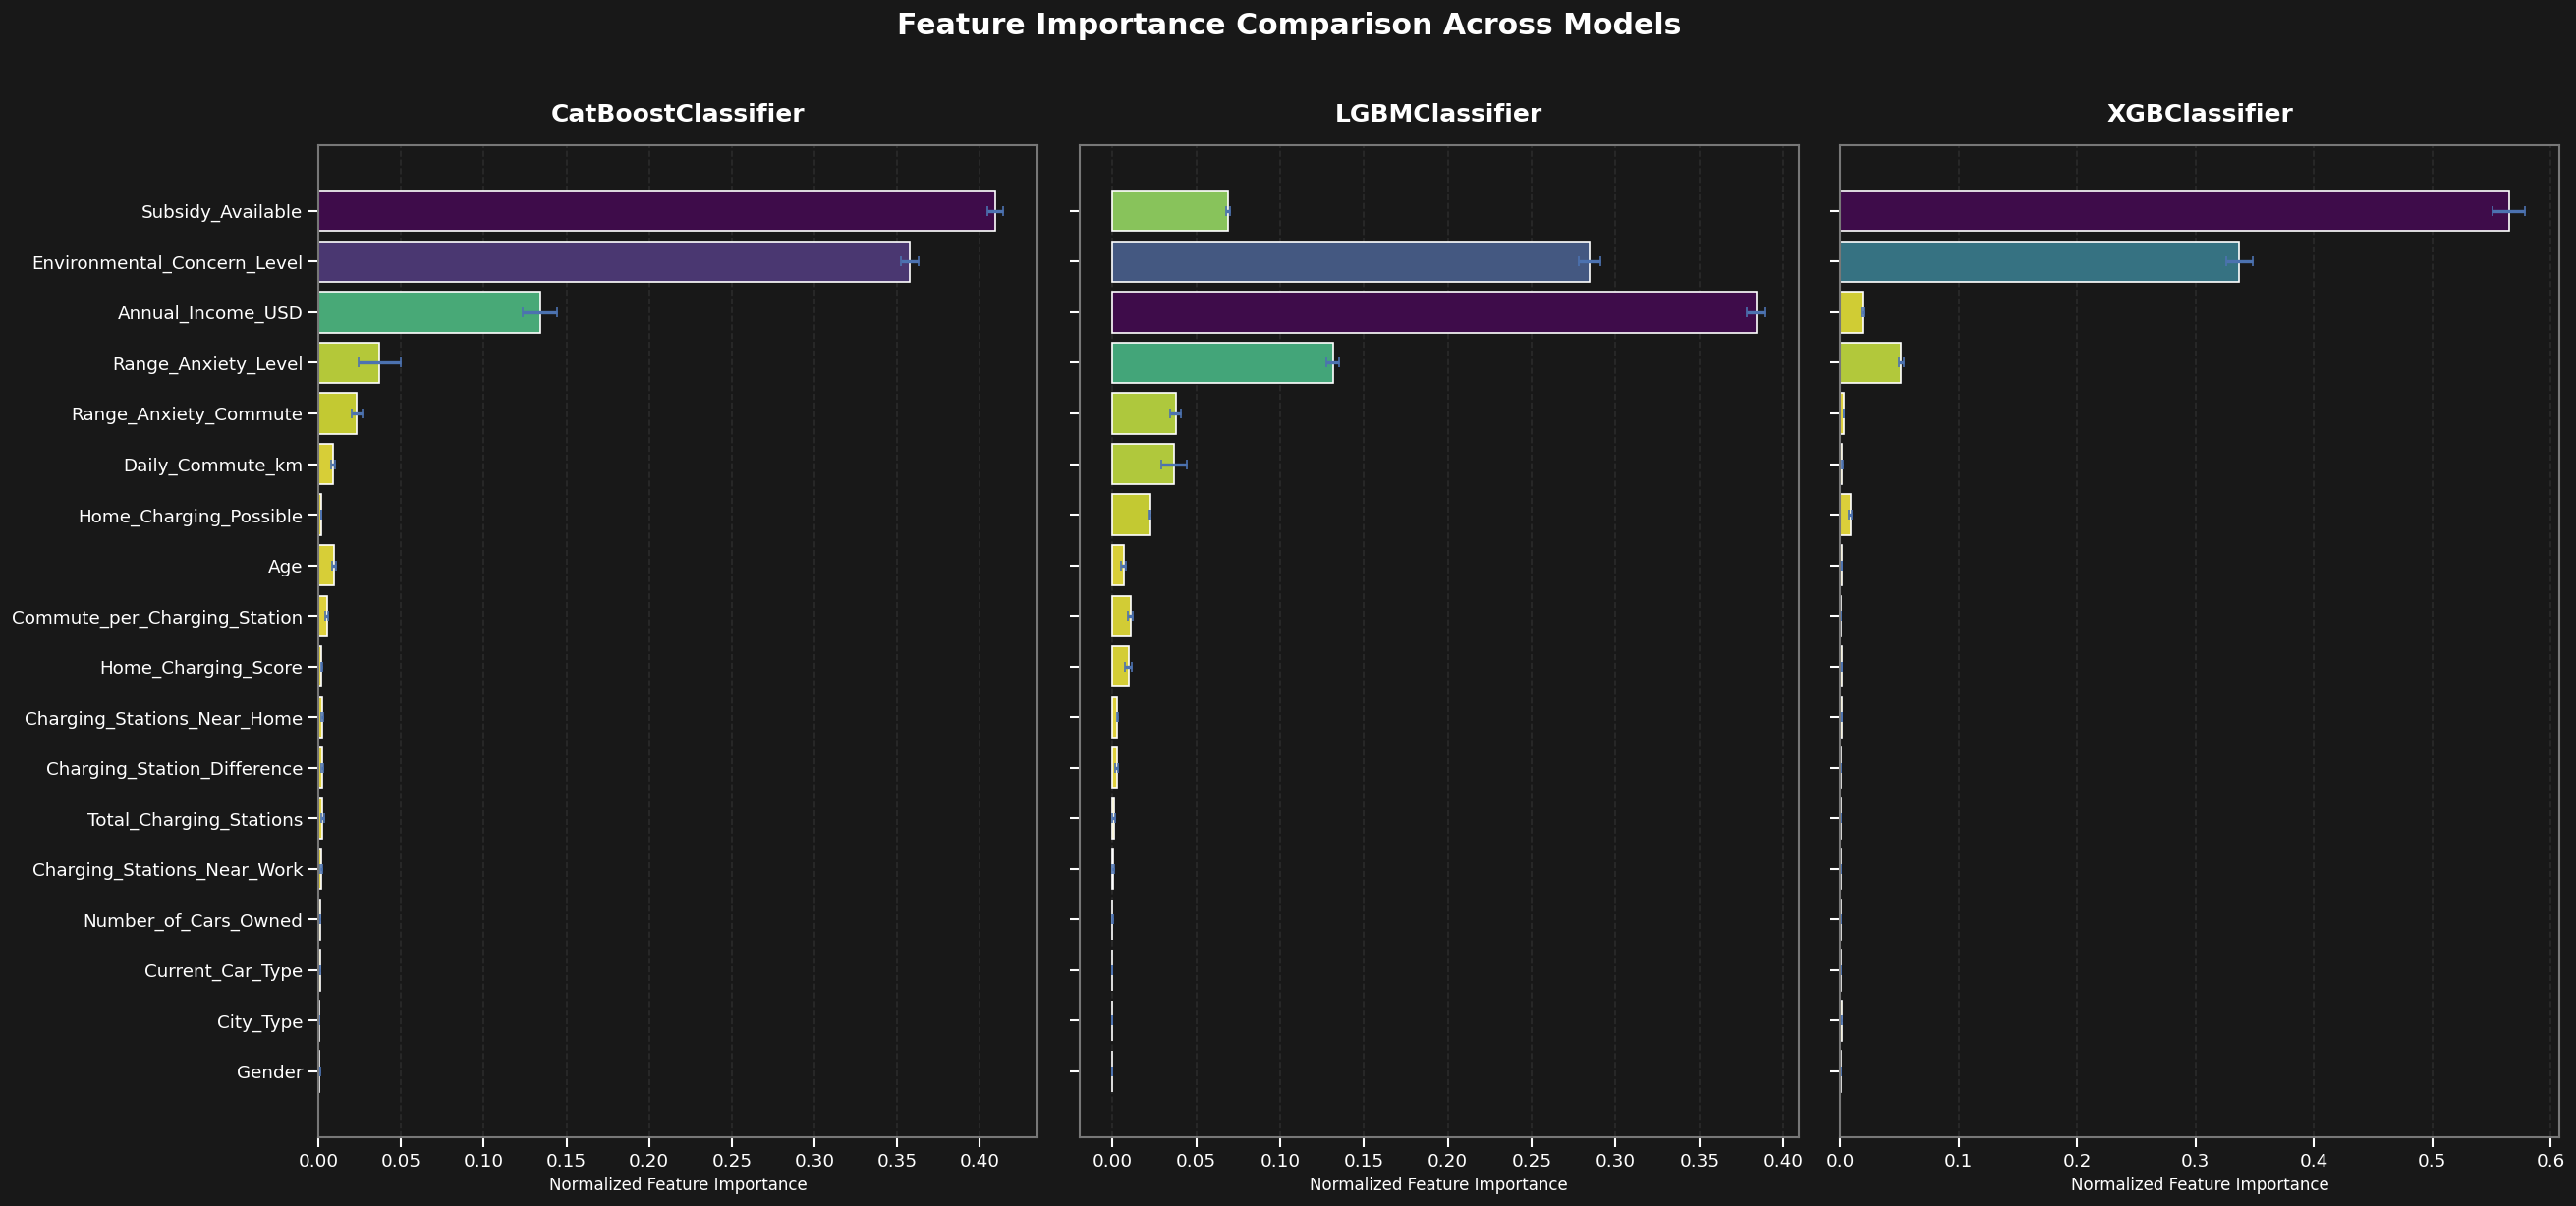

In [25]:
feature_importances = {
    "CatBoostClassifier": results_cb["feature_importance"],
    "LGBMClassifier": results_lgbm["feature_importance"],
    "XGBClassifier": results_xgb["feature_importance"]
}

fig = plot_feature_importance_comparison(
    feature_importances=feature_importances,
    top_n=20,
    figsize=(22, 10),
    show_std=True
)

In [26]:
# Extract OOF and validation predictions
oof_pred_cb = results_cb["oof_pred"]
oof_pred_lgbm = results_lgbm["oof_pred"]
oof_pred_xgb = results_xgb["oof_pred"]

xgb_auc = roc_auc_score(y, oof_pred_xgb)
lgb_auc = roc_auc_score(y, oof_pred_lgbm)
cat_auc = roc_auc_score(y, oof_pred_cb)

# AUC-weighted blend
total_auc = xgb_auc + lgb_auc + cat_auc
w_xgb = xgb_auc / total_auc
w_lgb = lgb_auc / total_auc
w_cat = cat_auc / total_auc

blended_oof = w_xgb * oof_pred_xgb + w_lgb * oof_pred_lgbm + w_cat * oof_pred_cb
blended_test = w_xgb * results_xgb["test_pred"] + w_lgb * results_lgbm["test_pred"] + \
               w_cat * results_cb["test_pred"]

blend_auc = roc_auc_score(y, blended_oof)

logger.info("="*80)
logger.info("ENSEMBLE BLENDING")
logger.info("="*80)
logger.info(f"XGB OOF AUC: {xgb_auc:.5f} (Weight: {w_xgb:.5f})")
logger.info(f"LGBM OOF AUC: {lgb_auc:.5f} (Weight: {w_lgb:.5f})")
logger.info(f"CATBOOST OOF AUC: {cat_auc:.5f} (Weight: {w_cat:.5f})")
logger.info(f"Blended OOF AUC: {blend_auc:.5f}")
logger.info("="*80)

# Prepare submission file
submission = pd.DataFrame({
    "id": list_test_id,
    "Will_Buy_EV": blended_test
})

submission.to_csv("submission.csv", index=False)
print("\nSubmission file saved!")
submission.head()

2026-09-19 12:44:49 | INFO     | ================================================================================
2026-09-19 12:44:49 | INFO     | ENSEMBLE BLENDING
2026-09-19 12:44:49 | INFO     | ================================================================================
2026-09-19 12:44:49 | INFO     | XGB OOF AUC: 0.94141 (Weight: 0.33374)
2026-09-19 12:44:49 | INFO     | LGBM OOF AUC: 0.93819 (Weight: 0.33260)
2026-09-19 12:44:49 | INFO     | CATBOOST OOF AUC: 0.94121 (Weight: 0.33367)
2026-09-19 12:44:49 | INFO     | Blended OOF AUC: 0.94105
2026-09-19 12:44:49 | INFO     | ================================================================================

Submission file saved!


,id,Will_Buy_EV
0,668665,0.086158
1,668666,0.144917
2,668667,0.070736
3,668668,0.045350
4,668669,0.129709


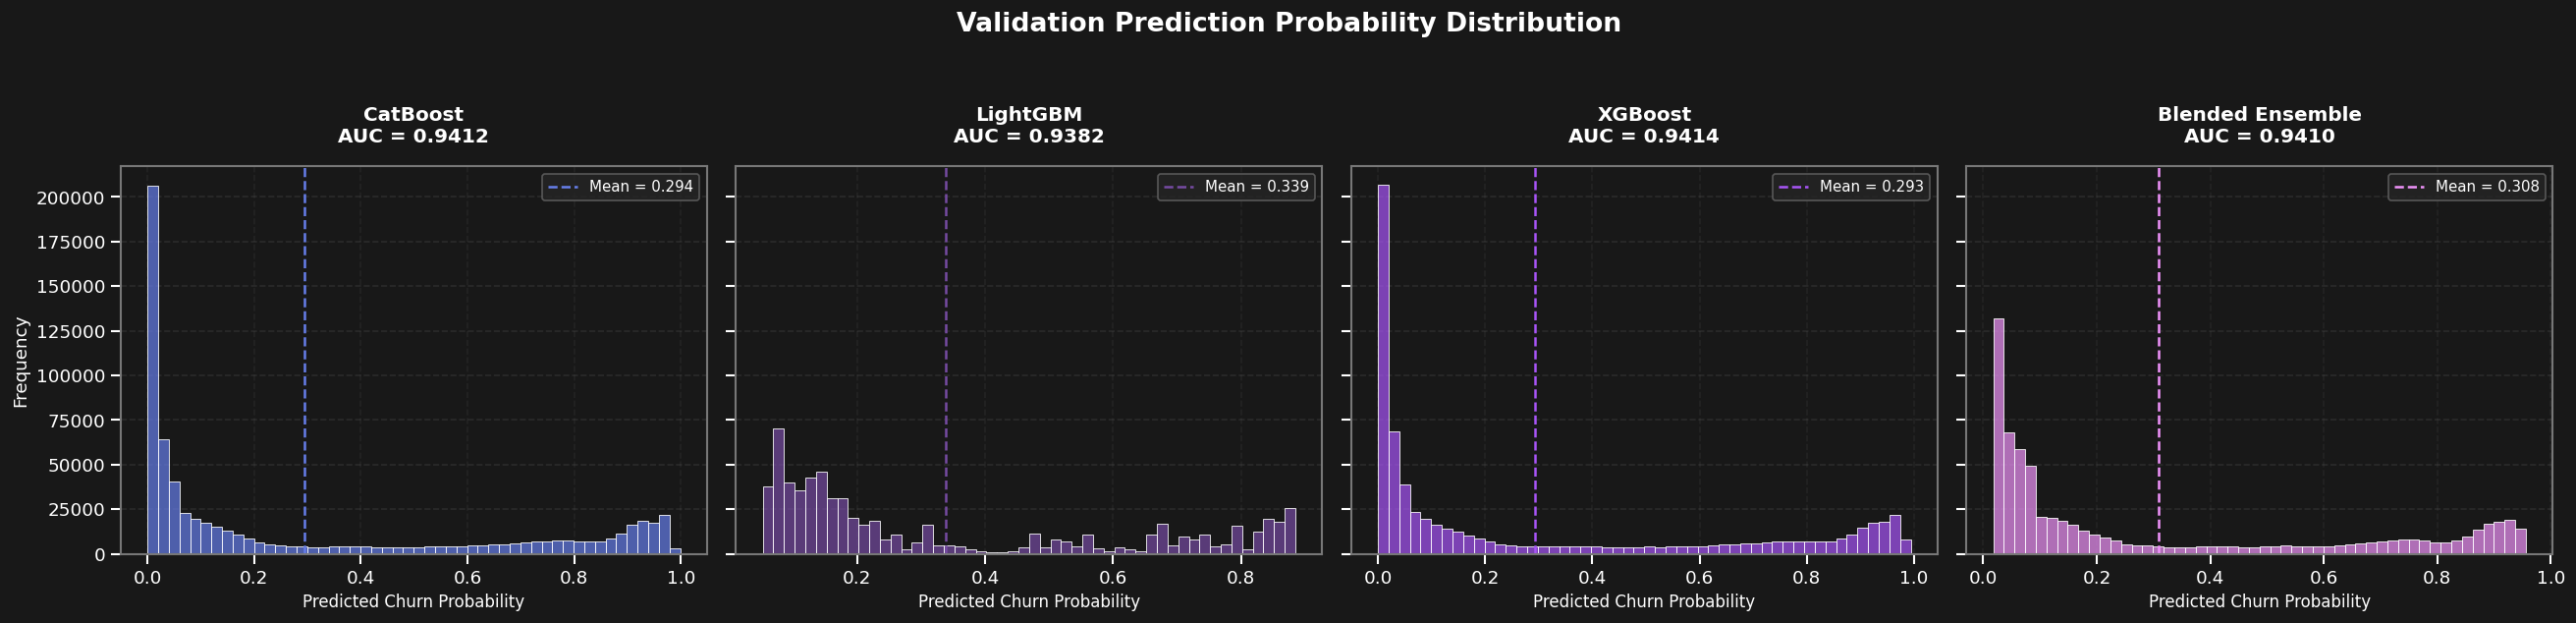

In [27]:
# Prediction Distribution Visualization
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
prediction_data = [
    ("CatBoost", oof_pred_cb, cat_auc),
    ("LightGBM", oof_pred_lgbm, lgb_auc),
    ("XGBoost",  oof_pred_xgb, xgb_auc),
    ("Blended Ensemble", blended_oof, blend_auc)
]

# Plot distributions
colors = list(config["colors"])
for i, (ax, (model_name, predictions, auc)) in enumerate(zip(axes, prediction_data)):
    sns.histplot(predictions, color=colors[i], alpha=0.7, ax=ax, bins=50)
    ax.axvline(predictions.mean(), color=colors[i], linestyle="--", linewidth=1.5, label=f"Mean = {predictions.mean():.3f}")
    ax.set_title(f"{model_name}\nAUC = {auc:.4f}", fontsize=12, fontweight="bold", pad=15)
    ax.set_xlabel("Predicted Churn Probability", fontsize=10)
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

# Final layout
fig.suptitle("Validation Prediction Probability Distribution", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Recommendation</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
        background: linear-gradient(
    135deg, 
    #003B5C, 
    #0077B6 35%, 
    #00B4D8 65%, 
    #2A9D8F 100%
);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Recommendation
    </h1>
</div>

<div style="
    background: linear-gradient(135deg, #1f2a44, #2c3e50);
    color: #ecf0f1;
    padding: 25px;
    border-radius: 12px;
    margin: 25px 0;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
">

<div style="
    color:#f9e79f;
    margin: 0 0 20px 0;
    font-size:22px;
    font-weight:600;
    letter-spacing:0.5px;
">
🚗 Recommendations
</div>

<table style="
    width:100%;
    border-collapse:collapse;
    background-color:rgba(255,255,255,0.04);
    font-size:14px;
">

<tr style="background-color:rgba(249,231,159,0.15);">
    <th style="padding:12px;border:1px solid #5d8a72;text-align:left;">
        Area
    </th>
    <th style="padding:12px;border:1px solid #5d8a72;text-align:left;">
        Recommendation
    </th>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">EV Subsidies</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Expand and target EV subsidy programs toward consumer segments where
financial incentives may have the greatest potential to support adoption.
<b>Subsidy_Available</b> is consistently one of the most important features
across all three models.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#ff6b6b;">Environmental Awareness</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Strengthen environmental awareness and EV education campaigns.
<b>Environmental_Concern_Level</b> remains highly important across
CatBoost, LightGBM, and XGBoost, while the EDA also shows a strong
relationship between environmental concern and EV purchase behavior.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">Affordability & Income</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Consider affordability-focused strategies such as competitive pricing,
financing options, and incentives. <b>Annual_Income_USD</b> is among the
most important predictors, although its relative importance varies across
models.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b style="color:#f9e79f;">Range Anxiety</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Reduce range anxiety through better communication of vehicle range,
charging availability, and practical charging solutions. <b>Range_Anxiety_Level</b>
shows meaningful importance in the models and a strong relationship with
purchase behavior in the EDA.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b>Charging Infrastructure</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Continue improving charging accessibility, particularly around consumers'
homes and workplaces. However, the relatively low model importance of the
individual charging-station features suggests that infrastructure alone
may not explain EV purchase decisions in this dataset.
</td>
</tr>

<tr>
<td style="padding:10px;border:1px solid #5d8a72;">
<b>Customer Segmentation</b>
</td>
<td style="padding:10px;border:1px solid #5d8a72;">
Use income, environmental concern, subsidy availability, and range anxiety
to develop more targeted EV marketing and customer segmentation rather
than relying heavily on demographic characteristics alone.
</td>
</tr>

</table>

<div style="
    margin-top:18px;
    padding:12px 15px;
    background-color:rgba(0,0,0,0.15);
    border-radius:8px;
    font-size:13px;
">
<b style="color:#f9e79f;">Note:</b>
Feature importance indicates how much each feature contributes to model
predictions; it does not by itself establish a causal relationship.
Recommendations should therefore be interpreted as data-driven business
directions rather than causal conclusions.
</div>

</div>